# Uncertainty Quantification for LLMs: A Comprehensive Tutorial

Large Language Models can be confidently wrong. **Uncertainty Quantification (UQ)** gives a model a second signal alongside its answer -- *how much should you trust this specific generation?* -- which matters most exactly where being wrong is expensive: clinical decision support, the running example throughout this notebook.

## What Is Uncertainty Quantification?

Techniques are usually organized along two axes:

| | You can only read text in/out | You can also read model internals |
|---|---|---|
| **Score after the fact** | **Black-box**: verbalized confidence, consistency across samples, claim-level scoring | **Introspective / information-theoretic** (white-box): token probabilities, entropy, attention, hidden states |
| **Act during generation** | Best-of-N, uncertainty-gated tool use | Entropy-gated branching, early exit |

Multimodal (vision-language) inputs don't get a new technique family -- both libraries apply the same text-decoder-level estimators to VLMs, with the caveat (Part 3) that this only ever captures the language decoder's residual uncertainty, not visual-perception uncertainty.

## The Two Libraries

- **[lm-polygraph](https://github.com/IINemo/lm-polygraph)** (IINemo) -- the broader toolkit: information-theoretic, density-based, and sampling/semantic-diversity estimators, plus a black-box consistency family. Reference: Fadeeva et al. (2023), ["LM-Polygraph: Uncertainty Estimation for Language Models"](https://arxiv.org/abs/2311.07383), EMNLP System Demonstrations.
- **[UQLM](https://github.com/cvs-health/uqlm)** (CVS Health) -- a cleaner, LangChain-native black-box/white-box scorer set with a native `UQEnsemble` and calibration suite.

Both are unified in this notebook behind one shared package, **`uq_toolbox`** (this repo's own `notebooks/uq_toolbox/`), so the plumbing (model managers, technique registry, the `evaluate_uncertainty()` dispatcher) lives in one place instead of being redefined in every notebook.

**Credits:** technique taxonomy and the black-box/white-box decision tree follow the AAAI-2026 tutorial (Shelmanov, Panov, Vashurin, Vazhentsev, Fadeeva, Rvanova & Baldwin, *"Uncertainty Quantification for Large Language Models"*); the benchmarking methodology (PRR as the primary metric) follows the companion TACL paper, Fadeeva et al. (2024), [doi:10.1162/tacl_a_00737](https://direct.mit.edu/tacl/article/doi/10.1162/tacl_a_00737).

## How This Notebook Is Organized

| Part | Covers | Backbone |
|---|---|---|
| **1. Black-Box UQ** | Verbalized, consistency-based, claim-level UQ, Best-of-N, uncertainty gating | `gpt-4o-mini` (API, no local weights needed) |
| **2. White-Box UQ** | Information-theoretic, reflexive, density-based, sampling/semantic estimators, calibration | `Qwen3-0.6B` (local) + `gpt-4o-mini` |
| **3. Multimodal UQ** | The same estimator families applied to a Vision-Language Model, plus score normalization/calibration | PaliGemma-3B (local, 4-bit) |

> ⚠️ **This notebook has two execution segments, not one continuous run.** Parts 1-2 share one Colab session (a small local model + an API model comfortably coexist). **Restart the runtime before Part 3** -- Part 2's local model and Part 3's vision-language model will not both fit in a single Colab GPU's VRAM. Do not use "Run All" across that boundary; run Parts 1-2, restart, then run Part 3.

**`UQ_Benchmarking.ipynb`**, alongside this notebook in the same repo, evaluates every technique above quantitatively (PRR, AUROC, Acc@K) on real medical QA datasets -- not repeated here, since this notebook is the qualitative, explanatory half of the project.

## 📑 Table of Contents

- [Uncertainty Quantification for LLMs: A Comprehensive Tutorial](#uncertainty-quantification-for-llms-a-comprehensive-tutorial)
- [Part 1: ⚫ Black-Box Uncertainty Quantification](#part-1-black-box-uncertainty-quantification)
  - [⚫0️⃣ Native Library APIs (Before the Wrapper)](#0-native-library-apis-before-the-wrapper)
  - [⚫1️⃣ Verbalized Uncertainty](#1-verbalized-uncertainty)
  - [⚫2️⃣ Consistency-Based Methods](#2-consistency-based-methods)
  - [⚫3️⃣ Claim-Level Black-Box UQ](#3-claim-level-black-box-uq)
  - [⚫5️⃣ Summary Dashboard](#5-summary-dashboard)
  - [🧠 Advanced Methods: Uncertainty as a Control Signal](#advanced-methods-uncertainty-as-a-control-signal)
- [Part 2: ⚪ White-Box Uncertainty Quantification](#part-2-white-box-uncertainty-quantification)
  - [1️⃣ Track A — UQLM White-Box Scorers](#1-track-a-uqlm-white-box-scorers)
  - [2️⃣ Track B — UQLM Ensemble Scoring](#2-track-b-uqlm-ensemble-scoring)
  - [3️⃣ Track C — LM-Polygraph White-Box UQ](#3-track-c-lm-polygraph-white-box-uq)
  - [4️⃣ Track D — Supervised Uncertainty Head (UHead)](#4-track-d-supervised-uncertainty-head-uhead)
- [Part 3: 🖼️ Multimodal Uncertainty Quantification](#part-3-multimodal-uncertainty-quantification)
  - [🎛️ UQ Normalization & Calibration](#uq-normalization-calibration)
    - [Phase-1: LM-Polygraph Normalization](#phase-1-lm-polygraph-normalization)
    - [Phase-2: UQLM Calibration](#phase-2-uqlm-calibration)
  - [Normalization & Calibration Conclusions](#normalization-calibration-conclusions)


## Prerequisites

- **A Hugging Face account + access token** (`HF_TOKEN`) -- required for downloading Qwen/PaliGemma weights. Create one at [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) (read access is enough); PaliGemma also requires accepting its license on the model page first.
- **An OpenAI API key** (`OPENAI_API_KEY`) -- used as the black-box backbone throughout Part 1, for some of Part 2's UQLM scorers, and for claim-extraction in Part 3.
- **Expected runtime**: Parts 1-2 run in a few minutes each on a free Colab GPU (or slower, seconds-per-call, on CPU). Part 3 needs a GPU for the 4-bit-quantized VLM.

---

## ⚙️ Global Setup

Installed and loaded **once**, shared by all three parts below.

In [ ]:
%pip install -q "pip<24.1"

%pip install -q -U \
  lm-polygraph \
  uqlm \
  langchain-openai \
  langchain-huggingface \
  langchain-anthropic \
  langchain-google-genai \
  langchain-ollama \
  pandas \
  plotly \
  matplotlib \
  seaborn \
  "transformers>=4.51,<5.0" \
  accelerate \
  bitsandbytes \
  sentence-transformers \
  datasets \
  scikit-learn \
  nltk \
  ipywidgets

# Optional: dev-branch lm-polygraph + the supervised uncertainty-head package, needed only by
# Part 2's "learned uncertainty" subsection. Wrapped so a failure here doesn't block the rest of
# the notebook -- uq_toolbox already falls back gracefully if this isn't installed.
%pip install -q \
  "git+https://github.com/IINemo/lm-polygraph.git@dev" \
  "git+https://github.com/IINemo/llm-uncertainty-head.git" || true

%pip install -q --force-reinstall "protobuf==5.28.3"

In [1]:
import os

os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TORCH"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
import os
from getpass import getpass

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("🔑 Enter your OpenAI API Key: ")
os.environ["OPENAI_BASE_URL"] = "https://api.openai.com/v1"

if "HF_TOKEN" not in os.environ:
    os.environ["HF_TOKEN"] = getpass("🔑 Enter your Hugging Face token: ")

In [3]:
import sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/miky-alt/UQ-Text-Mining.git"
REPO_DIR = Path("UQ-Text-Mining")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL], check=True)

%pip install -q -e ./UQ-Text-Mining

import uq_toolbox
from uq_toolbox import evaluate_uncertainty
from uq_toolbox.managers.model_manager import UQModelManager, initialize_uq_models
from uq_toolbox.registry import UQ_REGISTRY, UQLibrary

print("Loaded uq_toolbox from:", uq_toolbox.__file__)
print("Techniques registered — lm-polygraph:", len(UQ_REGISTRY[UQLibrary.POLYGRAPH]),
      "| uqlm:", len(UQ_REGISTRY[UQLibrary.UQLM]))

Cloning into 'UQ-Text-Mining'...


  error: subprocess-exited-with-error
  
  × Getting requirements to build editable did not run successfully.
  │ exit code: 1
  ╰─> [7 lines of output]
      running egg_info
      creating uq_toolbox.egg-info
      writing uq_toolbox.egg-info/PKG-INFO
      writing dependency_links to uq_toolbox.egg-info/dependency_links.txt
      writing top-level names to uq_toolbox.egg-info/top_level.txt
      writing manifest file 'uq_toolbox.egg-info/SOURCES.txt'
      error: package directory 'uq_toolbox' does not exist
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
ERROR: Failed to build 'file:///Users/armina/Desktop/unibo/Semester3/Big%20Data%20%26Text%20Mining/Project/UQ-Text-Mining/notebooks/UQ-Text-Mining' when getting requirements to build editable


Note: you may need to restart the kernel to use updated packages.


Loaded uq_toolbox from: /Users/armina/Desktop/unibo/Semester3/Big Data &Text Mining/Project/UQ-Text-Mining/notebooks/uq_toolbox/__init__.py
Techniques registered — lm-polygraph: 37 | uqlm: 17


# Part 1: ⚫ Black-Box Uncertainty Quantification

Black-box UQ treats the LLM as an **opaque text API**: no logits, no hidden states, no attention weights -- only the prompt you send and the text that comes back. This is the default (and often *only*) setting when the model sits behind a commercial API (GPT-4, Gemini, Claude) or when you simply don't control the serving stack.

Because black-box methods never touch model internals, **the same techniques work identically whether the backbone is a small local model or a hosted API model** -- there is no white-box/black-box split by architecture, only by what you're allowed to read.

This notebook covers three practically distinct families:

1. **Verbalized uncertainty** -- ask the model how confident it is.
2. **Consistency-based methods** -- sample several answers and measure how much they agree.
3. **Claim-level UQ** -- decompose a long answer into atomic claims and score each one.

...and one family that *acts* on these scores instead of just reporting them: **Best-of-N selection** and **uncertainty-gated tool use**.

> **Continue reading:** Part 2 of this notebook covers the introspective/white-box families (attention-based, hidden-state-based) that need access to model internals.

## 🏥 Shared case-study prompts

The same two clinical prompts are reused throughout the notebook. Keeping them fixed makes the comparison easier: when the uncertainty score changes, the *method* changed -- not the question.

In [4]:
prompt_labels = ["Prompt 1 — Established fact", "Prompt 2 — Research frontier"]
prompts_raw = [
    "What is the first-line treatment for anaphylaxis after amoxicillin exposure? Answer with only the drug and route.",
    "What is the most effective treatment for long COVID neurological symptoms? Answer concisely.",
]

for label, p in zip(prompt_labels, prompts_raw):
    print(f"{label}: {p}")

Prompt 1 — Established fact: What is the first-line treatment for anaphylaxis after amoxicillin exposure? Answer with only the drug and route.
Prompt 2 — Research frontier: What is the most effective treatment for long COVID neurological symptoms? Answer concisely.


## 🔧 Model Definition

Black-box methods only need **text in, text out** -- so, unlike the white-box notebook, there's no requirement to load local weights. We use `gpt-4o-mini` via the OpenAI API for every technique below. The same code would work unchanged against a local Hugging Face model in black-box mode; that's the whole point of this family.

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_BASE_URL"],
    temperature=0.7,
    max_tokens=180,
)

# One shared alias registered on BOTH backends, same underlying model (gpt-4o-mini):
# lm-polygraph's own BlackboxModel wrapper for polygraph-native techniques (Verbalized*, EigLaplacian, ...),
# and the same ChatOpenAI instance (via provider="custom") for UQLM-native techniques.
uq_context = initialize_uq_models(
    polygraph_models={"gpt4o_mini": {"model_id": "gpt-4o-mini", "mode": "black"}},
    uqlm_models={
        "gpt4o_mini": {
            "provider": "custom", "model_id": None,
            "kwargs": {"custom_llm": llm},
        }
    },
    p_mode="black", u_mode="black",
)


🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

⚙️ Adding lm_polygraph [GPT4O_MINI] in BLACK-BOX mode...

📊 Adding UQLM [GPT4O_MINI] in BLACK-BOX mode...

✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES


## 🎯 Learning objectives

- Distinguish **verbalized**, **consistency-based**, and **claim-level** black-box UQ, and know when each is worth its cost.
- See both libraries' **native calls** before relying on the shared `evaluate_uncertainty()` wrapper.
- Read a **direction-aware** comparison across techniques and both libraries.
- Use uncertainty as a **control signal** (Best-of-N selection, tool-use gating), not just a report.

## 🗺️ Methods covered

| Family | Techniques | Library |
|---|---|---|
| Verbalized | Verbalized 1S, Verbalized 2S, Linguistic 1S | lm-polygraph |
| Consistency (graph-based) | EigLaplacian, DegMat, Eccentricity | lm-polygraph (native) |
| Consistency (other) | LabelProb, NumSemSets, LexicalSimilarity, KLE, LUQ | lm-polygraph |
| Consistency (UQLM) | ExactMatch, Entailment, NonContradiction, CosineSim, SemanticNegentropy | uqlm |
| Claim-level | Entailment (`granularity="claim"`) | uqlm |
| Control signal | Best-of-N, Uncertainty Gate | both (mode-agnostic) |

## 🎨 Technique Legend

<span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#FF8C00;margin-right:4px;"></span> Verbalized &nbsp;<span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#2171b5;margin-right:4px;"></span> Consistency (lm-polygraph) &nbsp;<span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#31a354;margin-right:4px;"></span> Consistency (UQLM) &nbsp;<span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#756bb1;margin-right:4px;"></span> Claim-level

## 🧰 A compact helper

Every technique below goes through the same three steps: call `evaluate_uncertainty()`, print the score, store it for the final comparison. This helper keeps each example to one line.

In [6]:
import numpy as np
import pandas as pd

blackbox_results = []

async def run_blackbox(technique, name, category, color, library=None, granularity="sequence", **kwargs):
    """Run one technique across both shared prompts and record it for the final comparison.

    Some estimators (e.g. lm-polygraph's Verbalized1S) raise instead of returning NaN when a
    small/mid-size model's response doesn't match the expected 'Probability: X.XX' format -- caught
    here so one awkward response doesn't crash the whole notebook, and reported as NaN like any
    other missing score.

    Note: uq_toolbox's evaluate_uncertainty() returns UQLM's native score unflipped under the
    'uncertainty_score' key -- for UQLM that value is actually *confidence* (higher = more sure),
    the opposite of lm-polygraph's convention. Flipped here (1 - confidence) so every row in this
    notebook shares one direction: higher = more uncertain.
"""
    rows = []
    for label, prompt in zip(prompt_labels, prompts_raw):
        try:
            out = await evaluate_uncertainty(
                prompt=prompt, technique_name=technique, granularity=granularity,
                uq_context=uq_context, model_alias="gpt4o_mini", library=library, **kwargs,
            )
            score = out["uncertainty_score"]
            if isinstance(score, list):  # claim-level: average the per-claim scores for the summary row
                score = float(np.mean([c["score"] for c in score]))
            if out.get("library") == "uqlm":
                score = 1.0 - score
            response_text = out["generated_text"].strip()
        except Exception as e:
            score = float("nan")
            response_text = f"[estimator error: {e}]"
        row = {
            "Technique": name, "Category": category, "Prompt": label,
            "Uncertainty": float(score), "Response": response_text, "Color": color,
        }
        rows.append(row)
        blackbox_results.append(row)
    table = pd.DataFrame(rows)[["Prompt", "Uncertainty", "Response"]]
    display(
        table.style.format({"Uncertainty": "{:.4f}"})
        .set_properties(subset=["Response"], **{"white-space": "pre-wrap", "text-align": "left", "max-width": "500px"})
    )
    return pd.DataFrame(rows)

---
## ⚫0️⃣ Native Library APIs (Before the Wrapper)

Everything below goes through `evaluate_uncertainty()`, which exists purely to give both libraries one consistent call signature. Before relying on it, here is what calling **lm-polygraph** and **UQLM** directly -- with no wrapper at all -- actually looks like.

### 0.1 lm-polygraph — native call

lm-polygraph's entry point is `estimate_uncertainty(model, ue_method, input_text)` against a `BlackboxModel` wrapper -- no registry, no dispatcher.

In [7]:
from lm_polygraph import estimate_uncertainty
from lm_polygraph.utils.model import BlackboxModel
from lm_polygraph.estimators import EigValLaplacian

native_polygraph_model = BlackboxModel.from_openai(
    openai_api_key=os.environ["OPENAI_API_KEY"], model_path="gpt-4o-mini",
)
native_ue_method = EigValLaplacian()
native_result = estimate_uncertainty(native_polygraph_model, native_ue_method, input_text=prompts_raw[0])

print("Native lm-polygraph call — no wrapper involved:")
print(f"  Estimator:   {native_result.estimator}")
print(f"  Uncertainty: {native_result.uncertainty:.4f}")
print(f"  Generated:   {native_result.generation_text[:120]}...")

2026-07-26 15:00:50,293 - lm_polygraph - INFO - Initializing EigValLaplacian


2026-07-26 15:00:50,294 - lm_polygraph - INFO - ====================================================================================================


2026-07-26 15:00:50,294 - lm_polygraph - INFO - Initializing stat calculators...


2026-07-26 15:00:50,295 - lm_polygraph - INFO - Initializing BlackboxSamplingGenerationCalculator


2026-07-26 15:00:52,411 - lm_polygraph - INFO - Initialized microsoft/deberta-large-mnli on cpu with batch_size=10


...

2026-07-26 15:00:52,412 - lm_polygraph - INFO - Initializing BlackboxGreedyTextsCalculator


2026-07-26 15:00:52,412 - lm_polygraph - INFO - Done intitializing stat calculators...


2026-07-26 15:00:54,484 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:00:55,640 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Native lm-polygraph call — no wrapper involved:
  Estimator:   EigValLaplacian_NLI_score_entail
  Uncertainty: 1.0000
  Generated:   Epinephrine, intramuscular....


### 0.2 UQLM — native call

UQLM's entry point is a scorer class (e.g. `BlackBoxUQ`) built directly around a LangChain chat model, with an async `generate_and_score(prompts, num_responses)` method returning a `UQResult`.

In [8]:
from uqlm import BlackBoxUQ

native_uqlm_scorer = BlackBoxUQ(llm=llm, scorers=["exact_match", "noncontradiction"])
native_uqlm_result = await native_uqlm_scorer.generate_and_score(
    prompts=[prompts_raw[0]], num_responses=5, show_progress_bars=False,
)
native_uqlm_df = native_uqlm_result.to_df()

print("Native UQLM call — no wrapper involved:")
print(native_uqlm_df[["response", "exact_match", "noncontradiction"]].to_string(index=False))

2026-07-26 15:00:58,700 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:00:59,668 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:00:59,673 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:00:59,704 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:00:59,762 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:01:00,180 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Native UQLM call — no wrapper involved:
                   response  exact_match  noncontradiction
Epinephrine, intramuscular.          0.8          0.999897


> **Why the wrapper still earns its place:** the two calls above already differ in setup object (`BlackboxModel` vs. a LangChain chat model), method name (`estimate_uncertainty` vs. `generate_and_score`), async-ness (sync vs. `await`), and result shape. `evaluate_uncertainty()` (used everywhere below) just picks the right one of these two calls from a single `technique_name` string and normalizes the result shape -- it adds no new UQ logic of its own.

---

## ⚫1️⃣ Verbalized Uncertainty

The model is **explicitly prompted** to express confidence -- no sampling required.

| Method | Mechanism |
|---|---|
| **Verbalized 1S** | Answer + confidence number in a single generation |
| **Verbalized 2S** | Generate the answer, then ask a *separate* follow-up question about confidence |
| **Linguistic 1S** | Parse hedging language ("likely", "possibly") into a numeric confidence |

**Why it tends to fail on small/mid-size LLMs:** they often ignore the exact numeric-answer format, they default to overconfident round numbers (`0.9`, `1.0`) regardless of actual uncertainty, and they mimic a "confident expert" persona even when they should hedge ([Xiong et al., 2024](https://arxiv.org/abs/2306.13063), ICLR — empirically shows verbalized confidence is poorly calibrated and largely insensitive to model scale below tens of billions of parameters).

> 📎 **Library coverage:** UQLM has no verbalized-uncertainty scorer at all -- its black-box core relies entirely on consistency, which is exactly Section 2 below.

**Reference:** Tian et al. (2023), ["Just Ask for Calibration"](https://arxiv.org/abs/2305.14975), EMNLP 2023.

In [9]:
VERBALIZED_SUFFIX = (
    "\n\nThen state your confidence as a probability between 0.0 and 1.0.\n"
    "Format exactly:\nAnswer: <your answer>\nProbability: <number>"
)
verbalized_prompts = [p + VERBALIZED_SUFFIX for p in prompts_raw]

VERBALIZED_2S_FOLLOWUP = (
    "How confident are you that your previous answer is correct? "
    "Respond only with: Probability: <a number between 0.0 and 1.0>"
)

LINGUISTIC_EXPRESSIONS = {
    "certainly": 0.95, "definitely": 0.95, "always": 0.9,
    "likely": 0.7, "probably": 0.65, "possibly": 0.5,
    "might": 0.4, "unsure": 0.3, "unlikely": 0.2, "not sure": 0.25,
}
linguistic_prompts = [
    p + "\n\nThen explicitly state your confidence using exactly one of these words: "
    "certainly, likely, probably, possibly, might, unsure, unlikely."
    for p in prompts_raw
]

verbalized_1s_df = await run_blackbox(
    "Verbalized1s", "Verbalized 1S", "Verbalized", "#FF8C00",
    prompts_override=verbalized_prompts, confidence_regex=r"Probability:\s*(\d+\.?\d*)",
)

,Prompt,Uncertainty,Response
0,Prompt 1 — Established fact,nan,[estimator error: Verbalized1S.__init__() got an unexpected keyword argument 'prompts_override']
1,Prompt 2 — Research frontier,nan,[estimator error: Verbalized1S.__init__() got an unexpected keyword argument 'prompts_override']


In [10]:
verbalized_2s_df = await run_blackbox(
    "Verbalized2s", "Verbalized 2S", "Verbalized", "#FF8C00",
    prompts_override=verbalized_prompts, confidence_prompt=VERBALIZED_2S_FOLLOWUP,
    confidence_regex=r"Probability:\s*(\d+\.?\d*)",
)

,Prompt,Uncertainty,Response
0,Prompt 1 — Established fact,nan,[estimator error: Verbalized2S.__init__() got an unexpected keyword argument 'prompts_override']
1,Prompt 2 — Research frontier,nan,[estimator error: Verbalized2S.__init__() got an unexpected keyword argument 'prompts_override']


In [11]:
linguistic_1s_df = await run_blackbox(
    "Linguistic1S", "Linguistic 1S", "Verbalized", "#FF8C00",
    prompts_override=linguistic_prompts, expressions=LINGUISTIC_EXPRESSIONS,
)

,Prompt,Uncertainty,Response
0,Prompt 1 — Established fact,nan,[estimator error: Linguistic1S.__init__() got an unexpected keyword argument 'prompts_override']
1,Prompt 2 — Research frontier,nan,[estimator error: Linguistic1S.__init__() got an unexpected keyword argument 'prompts_override']


> **Observation:** watch whether `gpt-4o-mini` -- a genuinely capable, instruction-tuned API model -- still produces the flat, saturated confidence scores the small-model literature predicts, or whether model scale already fixes most of the calibration problem here. Compare directly with the consistency-based scores in the next section for the same two prompts.

> **On `nan` outputs:** if `Verbalized1S`/`Verbalized2s`/`Linguistic1S` return `nan` for a given prompt, it's a regex-parsing miss, not a silent failure -- the estimator expects the model's confidence statement in an exact `Answer: <x>\nConfidence: <y>` shape, and any deviation (extra prose, missing newline) makes the confidence-extraction regex match nothing. It's a known brittleness of prompt-based confidence elicitation ([Xiong et al. 2024](https://arxiv.org/abs/2306.13063)), not a bug in the estimator's uncertainty math.

---
## ⚫2️⃣ Consistency-Based Methods

Sample **K stochastic answers** to the same prompt and measure how much they agree. Higher disagreement → higher uncertainty. Model-agnostic and generally more reliable than verbalization at any model size, at the cost of K generations instead of one.

### Graph-based methods (lm-polygraph)

All three share the same construction: sample K answers, build a $K \times K$ NLI-entailment similarity graph, then summarize it differently:

| Method | Formula | Intuition |
|---|---|---|
| **EigLaplacian (EigV)** — *AAAI-2026 decision-tree's recommended pick* | $U=\lambda_1(\mathcal{L})$ | Largest Laplacian eigenvalue: near 0 = one tight cluster, large = several disconnected clusters |
| **DegMat** | $U=-\frac{1}{K}\sum_i\sum_j W_{ij}$ | Low total edge weight → answers are semantically distant |
| **Eccentricity** | $U=\max_i\min_j\,d(a_i,a_j)$ | How isolated is the most peripheral answer |

None of these three are in `uq_toolbox`'s registry yet, so they're called here via lm-polygraph's **native** API directly, reusing the `BlackboxModel` built in §0.1 -- exactly the "native calls still work standalone" point from the start of this notebook.

**Reference:** Lin, Trivedi & Sun (2023), ["Generating with Confidence"](https://arxiv.org/abs/2305.19187).

In [12]:
from lm_polygraph.estimators import EigValLaplacian, DegMat

graph_methods = {
    "EigLaplacian": EigValLaplacian(),
    "DegMat": DegMat(),
}

for method_name, estimator in graph_methods.items():
    for label, prompt in zip(prompt_labels, prompts_raw):
        out = estimate_uncertainty(native_polygraph_model, estimator, input_text=prompt)
        blackbox_results.append({
            "Technique": method_name, "Category": "Consistency (lm-polygraph)", "Prompt": label,
            "Uncertainty": float(out.uncertainty), "Response": out.generation_text.strip(),
            "Color": "#2171b5",
        })
        print(f"  [{method_name}] {label}: U={float(out.uncertainty):.4f}")

2026-07-26 15:01:00,749 - lm_polygraph - INFO - Initializing EigValLaplacian


2026-07-26 15:01:00,749 - lm_polygraph - INFO - Initializing DegMat


2026-07-26 15:01:00,750 - lm_polygraph - INFO - ====================================================================================================


2026-07-26 15:01:00,751 - lm_polygraph - INFO - Initializing stat calculators...


2026-07-26 15:01:00,751 - lm_polygraph - INFO - Initializing BlackboxSamplingGenerationCalculator


...

2026-07-26 15:01:33,307 - lm_polygraph - INFO - Initializing BlackboxGreedyTextsCalculator


2026-07-26 15:01:33,307 - lm_polygraph - INFO - Done intitializing stat calculators...


2026-07-26 15:01:36,119 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:01:51,525 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  [DegMat] Prompt 2 — Research frontier: U=0.5607


### UQLM black-box consistency scorers

| Scorer | Comparison signal |
|---|---|
| **ExactMatch** | String equality -- fastest, best for short factual/MCQ answers |
| **Entailment** | NLI entailment score -- most robust for longer clinical answers |

The registry also has `NonContradiction`, `NormalizedCosineSim`, and `BlackSemanticNegentropy` -- same family, omitted here to keep the walkthrough focused on the two most-used scorers.

UQLM returns **confidence**, so `evaluate_uncertainty()` converts it to uncertainty as `1 - confidence` here, matching the direction convention used throughout this notebook (higher = more uncertain).

In [13]:
uqlm_consistency_scorers = ["ExactMatch", "Entailment"]

for technique in uqlm_consistency_scorers:
    await run_blackbox(technique, technique, "Consistency (UQLM)", "#31a354", library="uqlm")

Output()

2026-07-26 15:01:52,561 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:01:53,327 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:01:53,403 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:01:53,456 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-07-26 15:02:06,200 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:06,279 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:06,478 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:06,749 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


,Prompt,Uncertainty,Response
0,Prompt 1 — Established fact,0.0066,Epinephrine intramuscularly.
1,Prompt 2 — Research frontier,0.5971,"The most effective treatment for long COVID neurological symptoms typically includes a multidisciplinary approach, focusing on symptom management. This may involve cognitive rehabilitation, physical therapy, medications for specific symptoms (such as pain or sleep disturbances), and mental health support. It's essential to tailor treatment to the individual's symptoms and needs, and ongoing research is aimed at better understanding and addressing these symptoms. Always consult a healthcare professional for personalized advice."


> **Observation:** expect EigLaplacian/DegMat to rank the two prompts similarly (same NLI graph underneath); LexicalSimilarity and the UQLM cosine-similarity scorer tend to diverge from the NLI-based methods when the model paraphrases the same correct answer differently across samples -- NLI correctly treats these as equivalent, ROUGE/cosine penalize the surface-form difference as if the answers were distinct.

---
## ⚫3️⃣ Claim-Level Black-Box UQ

A single sequence score for a multi-sentence clinical explanation is an over-simplification. **Claim-level UQ** decomposes the answer into atomic factual claims and scores each independently -- still purely black-box, since UQLM's `LongTextUQ`-style pipeline only needs generated text plus an NLI/similarity model, no logits.

`Entailment` and `NonContradiction` (already used above at sequence level) both support `granularity="claim"` directly through the same `evaluate_uncertainty()` call -- no separate low-level pipeline needed.

In [14]:
claim_result = await evaluate_uncertainty(
    prompt=prompts_raw[1], technique_name="Entailment", granularity="claim",
    uq_context=uq_context, model_alias="gpt4o_mini", library="uqlm",
)

# UQLM returns confidence per claim, unflipped by the toolbox wrapper -- invert here so
# higher = more uncertain, matching every other score in this notebook.
print(f"Generated: {claim_result['generated_text'][:200]}...\n")
for claim in claim_result["uncertainty_score"]:
    uncertainty = 1.0 - claim["score"]
    print(f"  [U={uncertainty:.3f}] {claim['claim_text']}")

Output()

2026-07-26 15:02:11,334 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:12,672 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:12,712 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:12,988 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:13,505 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:13,801 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:15,973 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Generated: The most effective treatment for long COVID neurological symptoms is often multidisciplinary and may include cognitive rehabilitation, physical therapy, symptom management (such as pain relief and moo...

  [U=0.093] The most effective treatment for long COVID neurological symptoms is often multidisciplinary.
  [U=0.025] The most effective treatment for long COVID neurological symptoms may include cognitive rehabilitation.
  [U=0.035] The most effective treatment for long COVID neurological symptoms may include physical therapy.
  [U=0.024] The most effective treatment for long COVID neurological symptoms may include symptom management.
  [U=0.152] Symptom management may include pain relief.
  [U=0.796] Symptom management may include mood stabilization.
  [U=0.062] The most effective treatment for long COVID neurological symptoms may include supportive care.
  [U=0.876] Tailored approaches may involve cognitive behavioral therapy.
  [U=0.982] Tailored approaches may involve 

> **Observation:** the claim-level profile reveals structure a single sequence score hides. On a research-frontier prompt like long-COVID neurological treatment, expect well-established supportive claims (rest, symptomatic management) to score confidently, while claims about specific experimental interventions vary more -- a clinician or safety system can flag only the high-uncertainty claims for review instead of discarding the whole response.

---
## ⚫4️⃣ Library Comparison: lm-polygraph vs UQLM

| Aspect | lm-polygraph | UQLM |
|---|---|---|
| **API style** | Synchronous `estimate_uncertainty()` | Async `generate_and_score()` via LangChain |
| **Provider support** | OpenAI + HuggingFace | Any LangChain provider (OpenAI, HF, Anthropic, Ollama, ...) |
| **Methods breadth** | Broader (EigLap, DegMat, Ecc, LexSim, LabelProb, KLE, LUQ, Verbalized) | Narrower but cleaner (ExactMatch, Entailment, NonContradiction, CosineSim, SemanticNegentropy) |
| **Claim-level (black-box)** | Not covered here | ✅ Native (`Entailment`/`NonContradiction`, `granularity="claim"`) |
| **Graph-based spectral** | ✅ EigLaplacian, DegMat, Eccentricity | ❌ Not available |
| **Normalization** | Raw scores (unbounded for some methods) | Bounded [0, 1] confidence, flipped to uncertainty here |

Both are unified in this notebook behind the same `evaluate_uncertainty()` / `UQ_REGISTRY` interface -- the table above is about what each library computes, not how you call it.

## ⚫5️⃣ Summary Dashboard

All black-box methods compared side by side across both clinical prompts. Scores are min-max normalized per technique so each row shares the same [0, 1] range -- for comparing **relative rankings**, not absolute scale.

In [15]:
import plotly.express as px

results_df = pd.DataFrame(blackbox_results)
results_df = results_df.dropna(subset=["Uncertainty"])

pivot = results_df.pivot_table(index="Technique", columns="Prompt", values="Uncertainty")
norm = pivot.sub(pivot.min(axis=1), axis=0).div((pivot.max(axis=1) - pivot.min(axis=1)).replace(0, 1), axis=0)

fig = px.imshow(
    norm.values, x=norm.columns, y=norm.index, color_continuous_scale="RdYlGn_r",
    labels=dict(color="Normalized uncertainty"), aspect="auto",
    title="Black-Box UQ — All Methods × Both Clinical Prompts (row-normalized)",
)
fig.update_layout(height=max(400, 24 * len(norm)))
fig.show()

In [16]:
category_colors = results_df.drop_duplicates("Technique").set_index("Technique")["Color"]
mean_uncertainty = results_df.groupby("Technique")["Uncertainty"].mean().sort_values()

fig2 = px.bar(
    x=mean_uncertainty.values, y=mean_uncertainty.index, orientation="h",
    color=mean_uncertainty.index.map(category_colors),
    color_discrete_map="identity",
    labels={"x": "Mean uncertainty across both prompts", "y": "Technique"},
    title="Black-Box UQ — Technique Ranking (mean across prompts, ↑ = less confident)",
)
fig2.update_layout(showlegend=False, height=max(400, 24 * len(mean_uncertainty)))
fig2.show()

> **Observation:** the graph-based/NLI consistency methods (EigLaplacian, DegMat, Entailment, NonContradiction) should cluster together and rank the research-frontier prompt clearly above the established-fact prompt; verbalized methods tend to look flatter across prompts, since a reasonably capable API model like `gpt-4o-mini` still saturates its stated confidence more than its actual knowledge varies.

---
# 🧠 Advanced Methods: Uncertainty as a Control Signal

Every family above **scores** an already-completed generation. The AAAI-2026 decision tree also lists a fourth family -- **uncertainty as a control mechanism** -- where the signal changes what the model does next, not just what gets reported. Both instances below are mode-agnostic in principle; shown here in their black-box form, reusing the consistency scores already computed above.

| Method | Role of uncertainty |
|---|---|
| **Best-of-N** | Sample N candidates, keep the one the black-box consistency signal likes best ([Snell et al. 2024](https://arxiv.org/abs/2408.03314), *"Scaling LLM Test-Time Compute Optimally"*) |
| **Uncertainty Gate for Tool Use** | Escalate to a retrieval/tool step when uncertainty is high |

## 🧠1️⃣ Best-of-N (Black-Box Selection)

Without logits, Best-of-N reduces to **self-consistency**: sample N answers, and treat the one that agrees most with the others -- the semantic "medoid" -- as the pick. `NonContradiction` (already used as a consistency scorer above) doubles naturally as this per-candidate agreement signal.

In [17]:
from uqlm import BlackBoxUQ

N_CANDIDATES = 5
best_of_n_prompt = prompts_raw[1]  # the harder, research-frontier prompt

bon_scorer = BlackBoxUQ(llm=llm, scorers=["noncontradiction"])
bon_result = await bon_scorer.generate_and_score(prompts=[best_of_n_prompt], num_responses=N_CANDIDATES)
bon_df = bon_result.to_df()

print(f"Best-of-N (N={N_CANDIDATES}) — {best_of_n_prompt[:60]}...")
for i, row in bon_df.iterrows():
    print(f"  candidate {i}: noncontradiction={row['noncontradiction']:.3f} | {row['response'][:80]}")

best_idx = bon_df["noncontradiction"].idxmax()
print(f"\n✅ Selected candidate {best_idx} (highest agreement with the others): "
      f"{bon_df.loc[best_idx, 'response'][:120]}")

Output()

2026-07-26 15:02:23,831 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:25,516 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:25,606 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:25,991 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:26,299 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:26,833 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Best-of-N (N=5) — What is the most effective treatment for long COVID neurolog...
  candidate 0: noncontradiction=0.998 | The most effective treatment for long COVID neurological symptoms typically invo

✅ Selected candidate 0 (highest agreement with the others): The most effective treatment for long COVID neurological symptoms typically involves a multidisciplinary approach, inclu


> **Clinical implication:** Best-of-N trades inference cost (N generations) for a single higher-agreement answer, with no extra scoring infrastructure beyond what Section 2 already built -- useful in latency-tolerant settings rather than interactive chat.

---
## 🧠2️⃣ Uncertainty Gate for Tool Use (Agentic UQ)

In agentic pipelines (RAG, tool-calling assistants), uncertainty can gate **whether the model is allowed to answer directly** or must **escalate** -- call a retrieval tool, request a second opinion, or flag the response for human review. This is a pure **decision-layer** use of UQ: no new inference, just a threshold applied to an uncertainty score already computed. We reuse the black-box **EigLaplacian** scores from Section 2.

$$\text{decision}(x) = \begin{cases}\text{ESCALATE (call tool)} & U(x) > \tau \\ \text{ANSWER DIRECTLY} & U(x) \le \tau\end{cases}$$

In [18]:
eig_scores = results_df[results_df["Technique"] == "EigLaplacian"].set_index("Prompt")["Uncertainty"]
gate_threshold = float(eig_scores.median()) if len(eig_scores) > 1 else float(eig_scores.mean())

def uncertainty_gate(score, threshold):
    return "ESCALATE (tool/retrieval)" if score > threshold else "ANSWER DIRECTLY"

print(f"Uncertainty Gate — threshold τ = {gate_threshold:.4f} (median EigLaplacian across shared prompts)")
for label, score in eig_scores.items():
    decision = uncertainty_gate(score, gate_threshold)
    print(f"  [U={score:.4f}] {decision:28s} | {label}")

Uncertainty Gate — threshold τ = 1.6095 (median EigLaplacian across shared prompts)
  [U=1.0000] ANSWER DIRECTLY              | Prompt 1 — Established fact
  [U=2.2189] ESCALATE (tool/retrieval)    | Prompt 2 — Research frontier


> **Design note:** τ here is set to the median purely for a two-prompt demonstration. In production, τ should be calibrated against a labeled validation set so it corresponds to an actual target error rate -- exactly the kind of thing the companion Benchmarking notebook's PRR/AUROC analysis is for.

---
## ✅ Part 1 Takeaway

Black-box UQ needs nothing but text in, text out -- which is exactly why it's the only family guaranteed to work against a closed commercial API. Verbalized methods are the cheapest but least reliable signal even on a capable model like `gpt-4o-mini`; consistency-based methods (especially the NLI-graph family: EigLaplacian, DegMat, Entailment, NonContradiction) are the most dependable black-box signal, at the cost of K generations per prompt; claim-level UQ trades a single vague number for an inspectable per-claim breakdown; and both Best-of-N and the Uncertainty Gate show that the same consistency scores can *act*, not just report.

> **Continue reading:** Part 2 of this notebook covers introspective/white-box methods that need model internals; `UQ_Benchmarking.ipynb` gives a quantitative PRR/AUROC evaluation of every technique above over real medical QA datasets.

# Part 2: ⚪ White-Box Uncertainty Quantification

This notebook is a hands-on introduction to **uncertainty quantification (UQ)** for language models.  
The goal is not only to run the code, but to understand:

- what each uncertainty method measures;
- which model signals it uses;
- how to interpret its output;
- when two methods should or should not be compared;
- what practical trade-offs appear in a resource-limited environment such as Google Colab.

We reuse the same two medical prompts throughout the notebook so that differences in the results come from the **UQ method**, not from changing the task.

| Part | Library or approach | Main learning goal |
|---|---|---|
| 1️⃣ | **UQLM white-box scorers** | Learn probability-, token-, semantic-, and self-reflection-based confidence |
| 2️⃣ | **UQLM ensemble** | Combine several confidence signals into one score |
| 3️⃣ | **LM-Polygraph** | Explore a broader set of white-box, attention, semantic, density, and claim-level methods |
| 4️⃣ | **Supervised uncertainty head** | Use a learned uncertainty model instead of a hand-designed formula |

## 🧭 Score-direction warning

The two libraries use different conventions:

- **UQLM:** higher values usually mean **more confidence**.
- **LM-Polygraph:** higher values usually mean **more uncertainty**.

Always read the explanation beside each result before interpreting the number.

> 🩺 **Educational use only:** the prompts are medical examples, but the generated answers and uncertainty scores are not medical advice.


> **Execution design:** this notebook uses one shared prompt. Polygraph always receives a scalar string. A one-item list is used only where a library API, such as UQLM, requires a list.


## 🏥 Shared case-study prompts

The same two medical prompts are reused throughout the notebook.

Keeping the prompts fixed makes the comparison easier: when the uncertainty score changes, the method or model changed—not the question.


In [19]:
prompt_label = "Prompt 1 — Anaphylaxis"
prompt_raw = (
    "A patient develops acute anaphylaxis after amoxicillin. "
    "What is the first-line immediate treatment? "
    "Answer with only the drug and route."
)
# Single-item lists are retained only for APIs such as UQLM that require a list.
prompt_labels = [prompt_label]
prompts_raw = [prompt_raw]

print(f"{prompt_label}: {prompt_raw}")


Prompt 1 — Anaphylaxis: A patient develops acute anaphylaxis after amoxicillin. What is the first-line immediate treatment? Answer with only the drug and route.


In [20]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_BASE_URL"],
    temperature=0.2,
    max_tokens=180,
    logprobs=True,
    top_logprobs=20,
)

---
# 1️⃣ Track A — UQLM White-Box Scorers

In this part, we inspect uncertainty directly from the model's token probabilities and generated alternatives.


## 🎯 Learning objectives

By the end of Part 1, you should be able to:

- distinguish sequence-level and token-level confidence;
- understand why one weak token can matter even when the full answer looks confident;
- compare single-generation and multi-generation methods;
- interpret semantic agreement across sampled responses;
- recognize that confidence is evidence, not proof of correctness.


## 🗺️ Methods covered

| Family | Methods |
|---|---|
| 🔵 Information-based | Sequence Probability, Minimum Token Probability, Mean/Minimum Token Negentropy, Probability Margin |
| 🟢 Meaning diversity | Monte Carlo Sequence Probability, Consistency and Confidence, Semantic Negentropy, Semantic Density |
| 🟣 Reflexive | P(True) |

Most UQLM outputs are approximately on a **0–1 confidence scale**, where a higher value usually means greater confidence.  
However, each method captures a different signal, so two columns should not automatically be treated as interchangeable.


## 🎨 Technique Legend

<table>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#1f77b4;margin-right:8px;vertical-align:middle;"></span>1. Sequence Probability</td><td>🔵 Information-based</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#3182bd;margin-right:8px;vertical-align:middle;"></span>2. Minimum Token Probability</td><td>🔵 Information-based</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#4292c6;margin-right:8px;vertical-align:middle;"></span>3. Mean Token Negentropy</td><td>🔵 Information-based</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#6baed6;margin-right:8px;vertical-align:middle;"></span>4. Minimum Token Negentropy</td><td>🔵 Information-based</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#9ecae1;margin-right:8px;vertical-align:middle;"></span>5. Probability Margin</td><td>🔵 Information-based</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#238b45;margin-right:8px;vertical-align:middle;"></span>6. Monte Carlo Sequence Probability</td><td>🟢 Meaning diversity</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#41ab5d;margin-right:8px;vertical-align:middle;"></span>7. Consistency and Confidence</td><td>🟢 Meaning diversity</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#74c476;margin-right:8px;vertical-align:middle;"></span>8. Semantic Negentropy</td><td>🟢 Meaning diversity</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#a1d99b;margin-right:8px;vertical-align:middle;"></span>9. Semantic Density</td><td>🟢 Meaning diversity</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#6a51a3;margin-right:8px;vertical-align:middle;"></span>10. P(True)</td><td>🟣 Reflexive</td></tr>
</table>

## 🧰 A compact helper

The helper below keeps the individual method examples short. For every scorer, it:

1. creates the UQLM scorer;
2. evaluates both prompts;
3. labels and displays the outputs;
4. stores the dataframe for the final comparison.

This lets us focus on the UQ idea rather than repeat boilerplate code.


In [21]:
results_store = {}

async def run_scorer(scorer, num_responses=None, sampling_temperature=None,
                     display_columns=None):
    options = {"llm": llm, "scorers": [scorer]}
    if sampling_temperature is not None:
        options["sampling_temperature"] = sampling_temperature

    run_options = {"prompts": prompts_raw}
    if num_responses is not None:
        run_options["num_responses"] = num_responses

    result = await WhiteBoxUQ(**options).generate_and_score(**run_options)
    df = result.to_df().copy()
    df.insert(0, "prompt_label", prompt_labels)
    results_store[scorer] = df

    columns = display_columns or ["prompt_label", "response", scorer]
    display(df[[column for column in columns if column in df.columns]])
    return df


# 🔵 Information-based Methods

## <span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#1f77b4;margin-right:8px;vertical-align:middle;"></span>1. Sequence Probability

**Idea:** multiply the probabilities of all generated tokens.

- `sequence_probability` reflects confidence in the complete sequence.

**How to read it:** higher values indicate that the generated sequence was more probable under the model.


In [22]:
from uqlm import WhiteBoxUQ

In [23]:
sequence_df = await run_scorer(
    "sequence_probability",
    display_columns=[
        "prompt_label",
        "response",
        "sequence_probability",
    ],
)


Output()

2026-07-26 15:02:28,842 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


,prompt_label,response,sequence_probability
0,Prompt 1 — Anaphylaxis,"Epinephrine, intramuscular.",0.984353


# 🟢 Meaning Diversity Methods

Multi-generation methods sample several answers from the same prompt. They combine token probabilities with agreement or semantic structure across those samples.

In this tutorial, each method uses **five sampled responses** with sampling temperature `1.0`.


## <span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#74c476;margin-right:8px;vertical-align:middle;"></span>8. Semantic Negentropy

**Idea:** cluster sampled responses by meaning and measure how concentrated the probability mass is across semantic interpretations.

**How to read it:** high confidence means the samples support relatively few competing meanings.


In [24]:
semantic_negentropy_df = await run_scorer(
    "semantic_negentropy",
    num_responses=5,
    sampling_temperature=1.0,
)


Output()

2026-07-26 15:02:29,884 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:30,804 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:30,809 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:30,814 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:30,816 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:30,818 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


,prompt_label,response,semantic_negentropy
0,Prompt 1 — Anaphylaxis,"Epinephrine, intramuscular.",1.0


# 🟣 Reflexive

## <span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#6a51a3;margin-right:8px;vertical-align:middle;"></span>10. P(True)

**Idea:** ask the model whether its previous answer is `True` or `False`, then use the probability assigned to `True`.

> **Compatibility note:** some reasoning-model endpoints emit internal channel tokens before the final boolean token. With the current UQLM version, this may produce `NaN` even when token log probabilities are available.


In [25]:
p_true_df = await run_scorer("p_true")



Output()

2026-07-26 15:02:34,906 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:35,593 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


,prompt_label,response,p_true
0,Prompt 1 — Anaphylaxis,"Epinephrine, intramuscular.",1.0


# 📊 UQLM-Local Scorers — Comparison

The table and heatmap summarize all the UQLM-local methods above on the same two prompts.

Use them to ask:

- Do several methods agree that one prompt is less confident?
- Does a token-level method reveal a weakness hidden by the sequence-level score?
- Do sampled answers remain semantically consistent?

A blank cell means the method returned `NaN`, often because the backend or endpoint could not provide the exact probability information that method required.


In [26]:
score_sources = [
    ("Sequence Probability", sequence_df, "sequence_probability"),
    ("Semantic Negentropy", semantic_negentropy_df, "semantic_negentropy"),
    ("P(True)", p_true_df, "p_true"),
]

comparison_table = pd.DataFrame({
    technique: [
        pd.to_numeric(df.loc[i, score], errors="coerce")
        for i in range(len(prompt_labels))
    ]
    for technique, df, score in score_sources
}, index=prompt_labels).T

comparison_table.index.name = "Technique"

display(comparison_table.round(3))

,Prompt 1 — Anaphylaxis
Technique,
Sequence Probability,0.984
Semantic Negentropy,1.000
P(True),1.000


In [27]:
fig = px.imshow(
    comparison_table,
    text_auto=".3f",
    aspect="auto",
    color_continuous_scale="Blues",
    zmin=0,
    zmax=1,
    labels=dict(x="Prompt", y="Technique", color="Confidence"),
    title="White-box confidence scores",
)

fig.update_layout(
    template="plotly_white",
    height=600,
)

fig.show()

In [28]:
bar_df = (
    comparison_table
    .reset_index()
    .melt(
        id_vars="Technique",
        var_name="Prompt",
        value_name="Confidence",
    )
)

fig = px.bar(
    bar_df,
    x="Confidence",
    y="Technique",
    color="Prompt",
    barmode="group",
    orientation="h",
    title="Confidence comparison by method",
)

fig.update_layout(
    template="plotly_white",
    height=650,
    xaxis_range=[0, 1],
    xaxis_title="Confidence",
    yaxis_title="",
)

fig.show()

# ✅ UQLM-Local Scorers — Takeaway

There is no single universal definition of model confidence.

- **Sequence methods** summarize the probability of the complete answer.
- **Token methods** expose local weak points.
- **Multi-generation methods** measure stability across alternative answers.
- **Semantic methods** compare meaning rather than exact wording.
- **P(True)** asks the model to reflect on its own answer.

Treat these methods as complementary signals. A confidence score can indicate risk, but it cannot by itself verify factual correctness.


---
# 2️⃣ Track B — UQLM Ensemble Scoring

A single uncertainty method may be noisy or incomplete. This part shows how several signals can be combined into one ensemble score.


## 🧠 Why use an ensemble?

An ensemble combines several scorers through a weighted average:

\[
	ext{ensemble score}=\sum_i w_i s_i
\]

The intuition is simple: if probability, semantic consistency, exact agreement, and an LLM judge all point in the same direction, the final estimate may be more robust than any one signal alone.

This tutorial uses the library's built-in weights, so no calibration dataset or training step is required.




<table>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#41ab5d;margin-right:6px;vertical-align:middle;"></span>noncontradiction</td><td>Meaning diversity</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#a1d99b;margin-right:6px;vertical-align:middle;"></span>exact_match</td><td>Meaning diversity</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#3182bd;margin-right:6px;vertical-align:middle;"></span>min_probability (optional)</td><td>Information-based</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#6a51a3;margin-right:6px;vertical-align:middle;"></span>judge_N</td><td>Reflexive</td></tr>
<tr><td><span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#d4a017;margin-right:6px;vertical-align:middle;"></span>ensemble_score (final blend)</td><td>Combined</td></tr>
</table>

Reusing the same shared `prompts_raw` from Global Setup — no need to redefine them.

In [29]:
prompts = prompts_raw

## 🚀 Run the ensemble

`UQEnsemble()` performs three tasks:

1. generates a main answer;
2. samples alternative answers for consistency-based scorers;
3. combines the component scores into one `ensemble_score`.

The output still includes the individual components, which is useful for understanding *why* the final ensemble score is high or low.


In [30]:
from uqlm import UQEnsemble

In [31]:
CONCISE_SYSTEM_PROMPT = (
    "You are a clinical assistant. Answer concisely, in one short sentence, "
    "with only the requested information."
)

uqe = UQEnsemble(llm=llm, system_prompt=CONCISE_SYSTEM_PROMPT, max_length=512)
results = await uqe.generate_and_score(prompts=prompts, num_responses=5)
result_df = results.to_df()
result_df

Output()

2026-07-26 15:02:38,915 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:39,836 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:39,849 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:39,852 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:39,881 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:39,936 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:02:41,238 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


,prompt,response,sampled_responses,ensemble_score,noncontradiction,exact_match,judge_1
0,A patient develops acute anaphylaxis after amo...,Epinephrine intramuscularly.,"[Epinephrine, intramuscular., Epinephrine intr...",0.915764,0.999578,0.4,1.0


🔍 **Which scorers does the off-the-shelf ensemble trust by default?** Even without tuning, `UQEnsemble` uses fixed, pre-set weights under the hood — this shows exactly what they are.

In [32]:
print(dict(zip(uqe.component_names, uqe.weights)))

{'noncontradiction': 0.5599999999999999, 'exact_match': 0.13999999999999999, 'judge_1': 0.3}


📖 **Scorer Glossary** — what each column in the results table actually measures:
- <span style="display:inline-block;width:12px;height:12px;border-radius:3px;background-color:#41ab5d;margin-right:6px;vertical-align:middle;"></span>**`noncontradiction`** — how often sampled responses semantically agree with (don't contradict) the original response *(🟢 Meaning diversity)*
- <span style="display:inline-block;width:12px;height:12px;border-radius:3px;background-color:#a1d99b;margin-right:6px;vertical-align:middle;"></span>**`exact_match`** — how often sampled responses are identical to the original response, works best for short factual answers *(🟢 Meaning diversity)*
- <span style="display:inline-block;width:12px;height:12px;border-radius:3px;background-color:#6a51a3;margin-right:6px;vertical-align:middle;"></span>**`judge_N`** — the LLM asked to grade its own response's correctness/quality *(🟣 Reflexive)*
- <span style="display:inline-block;width:12px;height:12px;border-radius:3px;background-color:#d4a017;margin-right:6px;vertical-align:middle;"></span>**`ensemble_score`** — the final weighted blend of all of the above *(🟡 Combined)*

## 📈 Visualizing the ensemble

The chart compares each component with the final ensemble score.

Look for cases where the components disagree. Such disagreement is often more informative than the final average alone because it reveals which type of uncertainty is driving the result.


In [33]:
import pandas as pd

pd.set_option("display.max_colwidth", 60)
score_cols = [c for c in result_df.columns if c not in ("prompt", "response", "sampled_responses")]
result_df[["prompt"] + score_cols].style.background_gradient(subset=score_cols, cmap="RdYlGn", vmin=0, vmax=1)

,prompt,ensemble_score,noncontradiction,exact_match,judge_1
0,A patient develops acute anaphylaxis after amoxicillin. What is the first-line immediate treatment? Answer with only the drug and route.,0.915764,0.999578,0.400000,1.000000


---
# 3️⃣ Track C — LM-Polygraph White-Box UQ

LM-Polygraph provides a broader collection of uncertainty estimators, including probability-based, attention-based, semantic, density-based, and claim-level methods.


## 🎯 What you will learn

This section uses `Qwen/Qwen3-0.6B` in `float32`.

The smaller model is intentional: it keeps the notebook practical on Colab while providing numerically stable hidden states for density-based methods.

Important convention:

> In LM-Polygraph, a larger `uncertainty` value generally means **more uncertainty**.

The absolute scales differ across estimators. Compare the same estimator across prompts, rather than directly comparing raw values from unrelated methods.


## 🤔 Where does the answer come from?

A typical call is:

```python
ue = estimate_uncertainty(model, estimator, input_text=prompt)
```

`estimate_uncertainty()` does two things:

1. generates an answer with the local model;
2. calculates uncertainty for that generated answer.

The returned object therefore contains both:

- `ue.generation_text` — the generated response;
- `ue.uncertainty` — the estimator's uncertainty value.

This is important: the method scores the model's own generation, not a manually supplied answer.


## 🔧 Model Definition

The model is loaded in `float32` to avoid unstable hidden states during density estimation.  
A 0.5B model keeps the memory requirement manageable while allowing every LM-Polygraph method to use the same underlying model.


In [34]:
from uq_toolbox.managers.model_manager import (
    UQModelManager,
    initialize_uq_models,
)
import torch

In [35]:
uq_context = initialize_uq_models(
    polygraph_models={
        "qwen": {
            "model_id": "Qwen/Qwen3-0.6B",
            "mode": "white",
        }
    },
    p_mode="white",
    temperature=0.1,
    max_tokens=20,
    polygraph_kwargs={
        "device_map": "auto",
        "attn_implementation": "eager",
        "torch_dtype": torch.float32,
    },
)


🚀 INITIALIZING MULTI-MODE UQ EXPERIMENTAL ENVIRONMENT

⚙️ Adding lm_polygraph [QWEN] in WHITE-BOX mode...



✅ ENVIRONMENT READY FOR QUANTIFICATION PIPELINES


## 💬 Format the shared prompts

Instruction-tuned models expect a chat template.  
The next cell reformats the two shared prompts into Qwen's expected conversation format without changing their meaning.


## 📦 Import the estimators

The next cell imports the estimators used in the individual examples below.

Each following section creates one estimator, runs it on both prompts, and appends the results to a shared list for later comparison.


In [36]:
polygraph_results = []


async def run_polygraph(
    technique,
    name,
    category,
    color,
    granularity="sequence",
):
    output = await evaluate_uncertainty(
        prompt=prompt_raw,
        technique_name=technique,
        granularity=granularity,
        uq_context=uq_context,
        model_alias="qwen",
        library=UQLibrary.POLYGRAPH,
    )

    score = output["uncertainty_score"]

    if isinstance(score, list):
        score = np.mean([
            item["score"] if isinstance(item, dict) else item
            for item in score
        ])

    row = {
        "Technique": name,
        "Category": category,
        "Granularity": granularity,
        "Uncertainty": float(score),
        "Response": output["generated_text"].strip(),
        "Color": color,
        "Prompt": prompt_label,
    }

    polygraph_results.append(row)

    table = pd.DataFrame([row])[
        [
            "Technique",
            "Category",
            "Granularity",
            "Uncertainty",
            "Response",
        ]
    ]

    display(
        table.style
        .format({"Uncertainty": "{:.4f}"})
        .set_properties(
            subset=["Response"],
            **{
                "white-space": "pre-wrap",
                "text-align": "left",
                "max-width": "500px",
            },
        )
    )

<span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#1f77b4;margin-right:8px;vertical-align:middle;"></span>**Maximum Sequence Probability** — 🔵 *Information-based*

In [37]:
await run_polygraph(
    "MaximumSequenceProbability",
    "Maximum Sequence Probability",
    "Information-based",
    "#3182bd",
)

2026-07-26 15:02:45,018 - lm_polygraph - INFO - Initializing MaximumSequenceProbability


2026-07-26 15:02:45,022 - lm_polygraph - INFO - ====================================================================================================


2026-07-26 15:02:45,023 - lm_polygraph - INFO - Initializing stat calculators...


2026-07-26 15:02:45,024 - lm_polygraph - INFO - Initializing GreedyProbsCalculator


2026-07-26 15:02:45,024 - lm_polygraph - INFO - Done intitializing stat calculators...


,Technique,Category,Granularity,Uncertainty,Response
0,Maximum Sequence Probability,Information-based,sequence,15.9195,"The answer is amoxicillin, route, IV. Answer: The first-line immediate treatment for acute"


<span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#2b83ba;margin-right:8px;vertical-align:middle;"></span>**Maximum Token Probability** — 🔵 *Information-based*

In [38]:

await run_polygraph(
    "MaximumTokenProbability",
    "Maximum Token Probability",
    "Information-based",
    "#3182bd",
    granularity ="token",
)

2026-07-26 15:02:46,139 - lm_polygraph - INFO - Initializing MaximumTokenProbability


2026-07-26 15:02:46,141 - lm_polygraph - INFO - ====================================================================================================


2026-07-26 15:02:46,141 - lm_polygraph - INFO - Initializing stat calculators...


2026-07-26 15:02:46,141 - lm_polygraph - INFO - Initializing GreedyProbsCalculator


2026-07-26 15:02:46,141 - lm_polygraph - INFO - Done intitializing stat calculators...


,Technique,Category,Granularity,Uncertainty,Response
0,Maximum Token Probability,Information-based,token,0.9437,The answer is in the format: the drug and route is: A. the drug and route is


<span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#3182bd;margin-right:8px;vertical-align:middle;"></span>**Perplexity** — 🔵 *Information-based*

In [39]:
await run_polygraph(
    "Perplexity",
    "Perplexity",
    "Information-based",
    "#3182bd",
)

2026-07-26 15:02:47,104 - lm_polygraph - INFO - Initializing Perplexity


2026-07-26 15:02:47,106 - lm_polygraph - INFO - ====================================================================================================


2026-07-26 15:02:47,106 - lm_polygraph - INFO - Initializing stat calculators...


2026-07-26 15:02:47,106 - lm_polygraph - INFO - Initializing GreedyProbsCalculator


2026-07-26 15:02:47,106 - lm_polygraph - INFO - Done intitializing stat calculators...


,Technique,Category,Granularity,Uncertainty,Response
0,Perplexity,Information-based,sequence,0.9051,The answer is in the format: drug route. The answer is: amoxicillin IV. Answer


<span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#4292c6;margin-right:8px;vertical-align:middle;"></span>**Mean Token Entropy** — 🔵 *Information-based*

In [40]:
await run_polygraph("MeanTokenEntropy", "Mean Token Entropy", "Information-based", "#4292c6")


2026-07-26 15:02:48,045 - lm_polygraph - INFO - Initializing MeanTokenEntropy


2026-07-26 15:02:48,047 - lm_polygraph - INFO - ====================================================================================================


2026-07-26 15:02:48,047 - lm_polygraph - INFO - Initializing stat calculators...


2026-07-26 15:02:48,047 - lm_polygraph - INFO - Initializing GreedyProbsCalculator


2026-07-26 15:02:48,047 - lm_polygraph - INFO - Initializing EntropyCalculator


2026-07-26 15:02:48,048 - lm_polygraph - INFO - Done intitializing stat calculators...


,Technique,Category,Granularity,Uncertainty,Response
0,Mean Token Entropy,Information-based,sequence,2.1803,The answer is in the format: drug route. The answer is: amoxicillin IV. Answer


## 🧠 Semantic methods and the NLI model

The next methods compare the meanings of several generated responses.

LM-Polygraph downloads a Natural Language Inference classifier, typically DeBERTa, to judge whether two answers entail or contradict each other.

This classifier is not another chat model. It does not write answers; it only compares text pairs semantically. The first run may take longer because the classifier must be downloaded.


<span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#238b45;margin-right:8px;vertical-align:middle;"></span>**Semantic Entropy** — 🟢 *Meaning diversity*

*Internally generates several extra sampled responses to compute this score — that's why it's slower than the single-generation techniques above.*

In [41]:
await run_polygraph("SemanticEntropy", "Semantic Entropy", "Meaning diversity", "#238b45")


2026-07-26 15:02:49,002 - lm_polygraph - INFO - Initializing SemanticEntropy


2026-07-26 15:02:49,004 - lm_polygraph - INFO - ====================================================================================================


2026-07-26 15:02:49,004 - lm_polygraph - INFO - Initializing stat calculators...


2026-07-26 15:02:49,005 - lm_polygraph - INFO - Initializing SamplingGenerationCalculator


2026-07-26 15:02:51,243 - lm_polygraph - INFO - Initialized microsoft/deberta-large-mnli on cpu with batch_size=10


2026-07-26 15:02:51,244 - lm_polygraph - INFO - Initializing SemanticMatrixCalculator


2026-07-26 15:02:51,244 - lm_polygraph - INFO - Initializing SemanticClassesCalculator


2026-07-26 15:02:51,244 - lm_polygraph - INFO - Initializing GreedyProbsCalculator


2026-07-26 15:02:51,244 - lm_polygraph - INFO - Done intitializing stat calculators...


,Technique,Category,Granularity,Uncertainty,Response
0,Semantic Entropy,Meaning diversity,sequence,12.3599,The answer is in the format: the drug and route is: A. the drug and route is


<span style="display:inline-block;width:14px;height:14px;border-radius:3px;background-color:#6a51a3;margin-right:8px;vertical-align:middle;"></span>**p(True)** — 🟣 *Reflexive*

In [42]:
await run_polygraph("PTrue", "p(True)", "Reflexive", "#6a51a3")


2026-07-26 15:03:01,017 - lm_polygraph - INFO - Initializing PTrue


2026-07-26 15:03:01,019 - lm_polygraph - INFO - ====================================================================================================


2026-07-26 15:03:01,019 - lm_polygraph - INFO - Initializing stat calculators...


2026-07-26 15:03:01,020 - lm_polygraph - INFO - Initializing GreedyProbsCalculator


2026-07-26 15:03:01,020 - lm_polygraph - INFO - Initializing PromptCalculator


2026-07-26 15:03:01,020 - lm_polygraph - INFO - Done intitializing stat calculators...


,Technique,Category,Granularity,Uncertainty,Response
0,p(True),Reflexive,sequence,10.0967,The answer is in the format: the drug and route. Answer: amoxicillin IV **


## 🟠 Density-Based UQ: Robust Density Estimation (RDE)

RDE asks whether the model's internal representation of a new prompt looks similar to representations from an in-domain reference dataset.

In this tutorial:

- the reference domain is **PubMedQA**;
- only **20 reference questions** are used to reduce runtime and memory;
- LM-Polygraph extracts the hidden-state representations and runs its built-in `RDESeq` estimator.

RDE is more suitable than plain Mahalanobis distance in this lightweight setting because it applies dimensionality reduction and robust density estimation before calculating distance.

**How to read the score:** a larger value indicates a representation that is more unusual relative to the reference medical questions.


> 💡 **Tutorial trade-off:** 20 reference questions are enough to demonstrate the implementation, but not enough for a calibrated research evaluation. A real experiment should use a larger and more representative reference set.


In [43]:
import pandas as pd
polygraph_results = []

from uq_toolbox.core.density_uq import run_rde_sequence

rde_result = run_rde_sequence(
    uq_context=uq_context,
    prompts=prompts_raw,
    prompt_labels=prompt_labels,
    model_alias="qwen",
    training_size=20,
    max_new_tokens=8,
)

polygraph_results.extend(rde_result["rows"])

rde_df = pd.DataFrame(rde_result["rows"])

display(
    rde_df[
        ["Prompt", "Uncertainty"]
    ].style.format({
        "Uncertainty": "{:.10f}"
    })
)

2026-07-26 15:03:02,380 - lm_polygraph - INFO - Initializing RDESeq


2026-07-26 15:03:02,380 - lm_polygraph - INFO - ====================================================================================================


2026-07-26 15:03:02,380 - lm_polygraph - INFO - Initializing stat calculators...


2026-07-26 15:03:02,381 - lm_polygraph - INFO - Initializing GreedyProbsCalculator


2026-07-26 15:03:02,381 - lm_polygraph - INFO - ====================================================================================================


...

/Users/armina/Desktop/unibo/Semester3/Big Data &Text Mining/Project/UQ-Text-Mining/tm-env/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:793: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


100%|██████████| 1/1 [01:20<00:00, 80.45s/it]

100%|██████████| 1/1 [01:20<00:00, 80.45s/it]

RDE calculation complete.


,Prompt,Uncertainty
0,Prompt 1 — Anaphylaxis,1.0612590780


### 🔎 Interpreting the RDE output

The two scores are close because both prompts are medical and therefore lie in a similar region relative to PubMedQA.

The small difference still shows how to compare RDE correctly: use the score to rank prompts *within the same estimator*. Do not treat the absolute value as a universal probability of error.


## 📊 LM-Polygraph comparison

The table places all sequence-level LM-Polygraph results side by side.

Remember:

- **higher usually means more uncertain**;
- every estimator has its own numerical scale;
- comparing two prompts within one method is meaningful;
- comparing raw values between unrelated methods is usually not.

The purpose is to study agreement and disagreement among uncertainty signals, not to declare one raw score universally best.


In [44]:
results_df = pd.DataFrame(polygraph_results)
comparison = results_df.pivot(index="Technique", columns="Prompt", values="Uncertainty")
comparison.style.background_gradient(cmap="RdYlGn_r")

Prompt,Prompt 1 — Anaphylaxis
Technique,
Robust Density Estimation,1.061259


## 📈 Uncertainty by technique

Each bar pair compares the same estimator across the two prompts.

Because no cross-method normalization is applied, the chart preserves the original output values. Read each pair locally rather than comparing bar heights from methods with different scales.


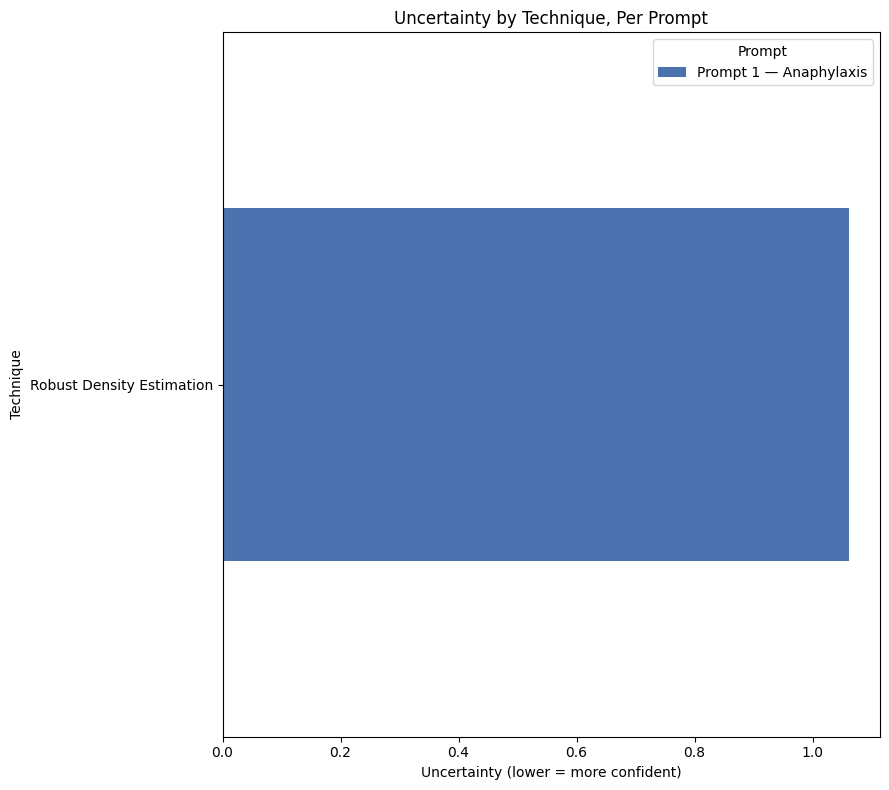

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# flatten any array-like uncertainty values to a single float first
results_df["Uncertainty"] = results_df["Uncertainty"].apply(
    lambda v: float(np.mean(v)) if hasattr(v, "__len__") else float(v)
)

pivot = results_df.pivot(index="Technique", columns="Prompt", values="Uncertainty")

fig, ax = plt.subplots(figsize=(9, 8))
pivot.plot(kind="barh", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_xlabel("Uncertainty (lower = more confident)")
ax.set_title("Uncertainty by Technique, Per Prompt")
ax.legend(title="Prompt")
plt.tight_layout()
plt.show()

## 🧩 Claim-Level Uncertainty

A complete answer can contain several factual statements, and they do not all have to be equally reliable.

Claim-level UQ therefore follows this pipeline:

1. generate an answer locally with Qwen;
2. split the answer into atomic factual claims using the NVIDIA-hosted instruction model;
3. compare claims with an NLI model;
4. assign an uncertainty score to each claim.

The six estimators demonstrated here are:

- Maximum Claim Probability
- Max Token Entropy
- Perplexity
- Pointwise Mutual Information
- p(True)
- Claim-Conditioned Probability

> 🌐 This section requires the NVIDIA API because claim extraction is performed by an external instruction model. The uncertainty estimators themselves remain LM-Polygraph methods.


> The sequence/token examples above now use the shared toolbox. The detailed claim-level block below is kept as an inspectable tutorial showing the calculator dependencies explicitly.


In [46]:
import pandas as pd

from uq_toolbox import evaluate_uncertainty

In [47]:
import os
import nltk
from openai import OpenAI

from lm_polygraph.stat_calculators import (
    GreedyProbsCalculator,
    ClaimsExtractor,
    GreedyAlternativesNLICalculator,
    EntropyCalculator,
    GreedyLMProbsCalculator,
    ClaimPromptCalculator,
)
from lm_polygraph.utils.deberta import Deberta
from lm_polygraph.estimators import (
    MaximumClaimProbability,
    MaxTokenEntropyClaim,
    PerplexityClaim,
    PointwiseMutualInformationClaim,
    PTrueClaim,
    ClaimConditionedProbabilityClaim,
)

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

client = OpenAI(
    api_key=os.environ["OPENAI_API_KEY"],
    base_url=os.environ["OPENAI_BASE_URL"],
)

class NVIDIAChat:
    def ask(self, message):
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": message}],
            max_tokens=250,   # was 500
        )
        return response.choices[0].message.content or ""

calculators = {
    "greedy": GreedyProbsCalculator(),
    "entropy": EntropyCalculator(),
    "lm_probs": GreedyLMProbsCalculator(),
    "claims": ClaimsExtractor(NVIDIAChat()),
    "nli": GreedyAlternativesNLICalculator(Deberta()),
    "ptrue": ClaimPromptCalculator(),
}

claim_estimators = {
    "Maximum Claim Probability": MaximumClaimProbability(),
    "Max Token Entropy": MaxTokenEntropyClaim(),
    "Perplexity": PerplexityClaim(),
    "PMI": PointwiseMutualInformationClaim(),
    "p(True)": PTrueClaim(),
    "CCP": ClaimConditionedProbabilityClaim(),
}

polygraph_model = uq_context.polygraph_models["qwen"]
tokenizer = polygraph_model.tokenizer
base_model = polygraph_model.model
model = polygraph_model

encoded = tokenizer(
    prompts,
    padding=True,
    truncation=True,
    return_tensors="pt",
).to(base_model.device)

deps = {"model_inputs": encoded}

deps.update(
    calculators["greedy"](
        deps,
        texts=prompts,
        model=model,
        max_new_tokens=50,
    )
)

deps["greedy_texts"] = tokenizer.batch_decode(
    deps["greedy_tokens"],
    skip_special_tokens=True,
)

deps.update(calculators["entropy"](deps, texts=prompts, model=model))
deps.update(calculators["lm_probs"](deps, texts=prompts, model=model))
deps.update(calculators["claims"](deps, texts=prompts, model=model))
deps.update(calculators["nli"](deps, texts=None, model=model))
deps.update(calculators["ptrue"](deps, texts=prompts, model=model))

print("Claim-level statistics prepared.")

claim_results = []

for technique, estimator in claim_estimators.items():
    scores = estimator(deps)

    for label, claims, claim_scores in zip(
        prompt_labels,
        deps["claims"],
        scores,
    ):
        for claim, score in zip(claims, claim_scores):
            claim_results.append({
                "technique": technique,
                "prompt": label,
                "claim": claim.claim_text,
                "uncertainty": float(score),
            })

claim_df = pd.DataFrame(claim_results)

display(
    claim_df.pivot_table(
        index=["prompt", "claim"],
        columns="technique",
        values="uncertainty",
        aggfunc="first",
    )
    .style
    .background_gradient(cmap="RdYlGn_r", axis=0)
    .format(precision=3)
)

2026-07-26 15:04:31,465 - lm_polygraph - INFO - Initializing GreedyProbsCalculator


2026-07-26 15:04:31,466 - lm_polygraph - INFO - Initializing EntropyCalculator


2026-07-26 15:04:31,466 - lm_polygraph - INFO - Initializing GreedyLMProbsCalculator


2026-07-26 15:04:31,466 - lm_polygraph - INFO - Initializing ClaimsExtractor


2026-07-26 15:04:31,467 - lm_polygraph - INFO - Initializing ClaimsExtractor with language=en, n_threads=1


...

2026-07-26 15:04:52,729 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:04:53,478 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:04:54,597 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-07-26 15:04:55,202 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Claim-level statistics prepared.


Note: This tutorial illustrates the mechanics of claim-level uncertainty quantification. Extracted claims may include formatting fragments or answer-option labels, and scores from different estimators use different numerical scales; they should not be compared directly by magnitude.

## 📚 Why LM-Polygraph ensembling is not run here

A meaningful model ensemble normally requires multiple independently trained checkpoints or a proper calibration dataset.

Using only two prompts would demonstrate the API but not the statistical idea honestly. For that reason, this notebook explains the concept but does not present a model-ensemble result as if it were a reliable experiment.


## 🧠 From formulas to learned uncertainty

The methods above use hand-designed formulas based on probabilities, entropy, attention, semantic agreement, or representation distance.

The next section takes a different approach: it uses a supervised uncertainty head trained on labelled hallucination examples. The head learns patterns in the base model's internal signals that correlate with unreliable generations.


---
# 4️⃣ Track D — Supervised Uncertainty Head (UHead)

A supervised uncertainty head is a small learned model attached to a language model.

Instead of manually defining an uncertainty formula, the head predicts uncertainty from internal LLM features after being trained on labelled examples of reliable and unreliable generations.

The head must match the exact base model architecture. This tutorial uses the published pair:

- `mistralai/Mistral-7B-Instruct-v0.2`
- `uhead6_Mistral-7B-Instruct-v0.2`

> ⚠️ This is the heaviest section of the notebook. Run it after Part 3 because the previous models are removed from memory first.


## 📦 Load the matching model and head

The next cells:

1. delete earlier Qwen and claim-level objects;
2. clear cached GPU memory;
3. load Mistral-7B in half precision;
4. attach the matching pretrained uncertainty head.

On a Colab T4, this step may take several minutes and can approach the available GPU-memory limit.


In [ ]:
from uq_toolbox import (
    SupervisedUQManager,
    evaluate_supervised_uncertainty,
)


Extracted package: /content/supervised
Files:
 - __init__.py
 - example_notebook_usage.py
 - README.md
 - engine.py
 - manager.py


In [ ]:
supervised_manager = SupervisedUQManager(
    model_name="mistralai/Mistral-7B-Instruct-v0.2",
    uncertainty_head_name=(
        "llm-uncertainty-head/"
        "uhead6_Mistral-7B-Instruct-v0.2"
    ),
    torch_dtype=torch.float16,
    device_map="auto",
    max_new_tokens=50,
    max_input_length=512,
    do_sample=False,
    attn_implementation="eager",
).load()

PyTorch: 2.11.0+cu128
Transformers: 4.57.6
CUDA available: True
GPU: Tesla T4
All supervised-UQ dependencies imported successfully.


In [ ]:
import pandas as pd
from IPython.display import display

supervised_result = evaluate_supervised_uncertainty(
    prompt=prompt_raw,
    label=prompt_label,
    manager=supervised_manager,
    aggregation="mean",
)

supervised_uq_df = pd.DataFrame([supervised_result])

display(
    supervised_uq_df[
        [
            "prompt",
            "supervised_uncertainty",
            "response",
        ]
    ]
)


Supervised UQ package imported successfully.


## ✅ Final takeaway

This notebook demonstrated four complementary ways to estimate uncertainty:

- probability and entropy formulas;
- agreement across multiple generations;
- representation- and claim-level analysis;
- a supervised uncertainty head.

No method guarantees factual correctness. The strongest workflow combines uncertainty estimates with external verification, domain knowledge, and task-specific evaluation.

The important lesson is not to search for one perfect score, but to choose a method whose assumptions match the application and to interpret that score on the correct scale.


---
# Part 3: 🖼️ Multimodal Uncertainty Quantification

---
# ⚠️ RESTART THE RUNTIME BEFORE CONTINUING

Part 2 loaded a local `Qwen3-0.6B` model. Part 3 below loads a 4-bit-quantized vision-language model (`PaliGemma-3B`). **Restart the runtime now** (Runtime → Restart runtime in Colab) to free that VRAM before running any cell below -- then re-run the **Global Setup** cells above (they're idempotent: the pip installs/toolbox clone will just report already-satisfied) before continuing into Part 3.

---
# Part 3: Multimodal Uncertainty Quantification

### ⚠️ **Decoder-Side Signals & Residual Uncertainty**

Under controlled input variations, the total predictive uncertainty of a Vision-Language Model (VLM) can be mathematically factorized into distinct cross-modal sources ([Ziran Yang et al. (2025b)](#ref-yang-2025b)):

$$\huge \mathcal{H} = U_{\text{attr}} + U_{\text{rephrase}} + U_{\text{res}}$$

Where:
* **$\mathcal{H}$** represents the total predictive uncertainty.
* **$U_{\text{attr}}$** is the uncertainty driven by the visual attributes utilized by the model.
* **$U_{\text{rephrase}}$** is the uncertainty stemming from linguistic rephrasings of the input query.
* **$U_{\text{res}}$** is the residual uncertainty originating inside the decoder.

When applying the vast majority of traditional text-derived UQ frameworks to VLMs, a severe structural limitation arises: **decoder-side signals capture only this final residual uncertainty ($U_{\text{res}}$)**. Because this component originates entirely within the autoregressive decoder—exactly as it does in text-only LLMs—standard metrics do not provide a blended signature of these distinct sources.

Indeed, standard text-based estimators completely omit the visual alignment and rephrasing components, failing to reflect:

> * **👁️‍🗨️ Visual perception uncertainty** (errors or noise originating within the vision encoder stage).

> * **🧩 Vision–language alignment failures** (the inability of visual representations to properly constrain text generation).

This architectural blind spot creates a critical failure mode in clinical deployment. For instance, if an image is unreadable or insufficient, the strong language model prior might smooth over the failure by generating a fluent, medically plausible hallucination.


### **🛠️ Multimodal UQ in UQLM and LM-Polygraph**

When evaluating the frameworks used in this laboratory, it is fundamental to understand the intrinsic engineering limitations of their multimodal approach:

> * **Absence of native metrics**: Neither `lm-polygraph` nor `uqlm` implement native or *ad-hoc* multimodal UQ metrics.

> * **Decoder-Centric Approach**: In both frameworks, the majority of UQ techniques operate directly on the VLM's final language decoder, adapting estimators created for pure-text LLMs to the cross-modal domain.
>
>

> * **Granularity limits**: This transition imposes rigid constraints on the granularity of the analyzable text:
    * **`lm-polygraph`**: Supports both `token` and `sequence` granularity.
    * **`uqlm`**: Is strictly limited to `sequence` granularity.
    * **Global Incompatibility**: Neither framework is compatible with `claim` granularity when processing visual inputs.



For quick reference, here is the compatibility matrix for the supported granularities:

| Framework | Token Granularity | Sequence Granularity | Claim Granularity |
| --- | --- | --- | --- |
| **`lm-polygraph`** | ✅ Supported | ✅ Supported | ❌ Not Compatible |
| **`uqlm`** | ❌ Not Compatible | ✅ Supported | ❌ Not Compatible |



### 📋 **What You’ll Do in This Multimodal Demo**

**📥 1. Load Vision-Language Models (VLMs)**
Load the core VLM backbones for both the LM-Polygraph and UQLM frameworks under a single, unified execution environment.

**🩺 2. Setting Up the Image and Clinical Prompt**
Establish a controlled baseline environment using a single diagnostic Chest X-ray image and a single query.

**⚙️ 3. Build the Multimodal UQ Pipeline**
Configure a unified engine to route this clinical vision-language input through both `lm-polygraph` (white-box) and `uqlm` (black-box) scoring pipelines.

**📚 4. Scorer Paradigms & Implementation**
Deploy the configured pipeline to calculate and compare different uncertainty estimation paradigms (such as sample-diversity and information-based metrics) directly on the generated medical report.


In [ ]:
# Shared imports this section relies on (previously provided earlier in the original
# notebook, now made explicit here since this section is extracted standalone).
import gc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Any, Optional, Tuple, Type
from IPython.display import display, HTML

In [ ]:
# Additional shared helpers this section relies on -- were defined earlier in the original
# source notebook (outside the Multimodal section proper) and are made explicit here since
# this section is extracted standalone.
import io
import base64
from typing import Union
from datasets import load_dataset
from PIL import Image
from sklearn.model_selection import train_test_split
from uq_toolbox.registry import list_uq_techniques
from uq_toolbox.core.response_evaluator import (
    BaseResponseEvaluator,
    SubstringMatchEvaluator,
    LLMGraderEvaluator,
)


def prepare_dataset(
    path: str,
    question_col: Union[str, List[str]],
    answer_col: str,
    name: Optional[str] = None,
    context_col: Optional[str] = None,
    image_col: Optional[str] = None,
    split: str = "train",
    max_samples: Optional[int] = None,
    test_size: float = 0.33,
    random_state: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Loads any dataset from the Hugging Face Hub, standardizes its schema via explicit
    configuration injection, handles multimodal conversions, and outputs isolated splits.
    """
    print(f"Loading dataset via universal parser: {path} (subset: {name or 'default'})...")

    raw_dataset = load_dataset(path, name, split=split)
    raw_df = raw_dataset.to_pandas()

    if max_samples and max_samples < len(raw_df):
        raw_df = raw_df.sample(frac=1, random_state=random_state).reset_index(drop=True).head(max_samples)
    else:
        raw_df = raw_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    standardized_records = []
    has_images = image_col is not None and image_col in raw_df.columns

    for idx, row in raw_df.iterrows():
        if isinstance(question_col, list):
            current_target = row
            for key in question_col:
                current_target = current_target.get(key, {}) if isinstance(current_target, dict) else ""
            question_base = " ".join(current_target) if isinstance(current_target, (list, np.ndarray)) else str(current_target)
        else:
            question_base = str(row.get(question_col, ""))

        if context_col and context_col in row and pd.notna(row[context_col]):
            context_data = row[context_col]
            context_str = " ".join(context_data["contexts"]) if isinstance(context_data, dict) and "contexts" in context_data else str(context_data)
            question_text = f"Context: {context_str}\nQuestion: {question_base}"
        else:
            question_text = question_base

        answer_text = str(row.get(answer_col, "")).strip()

        encoded_image = None
        mime_type = None

        if has_images and row[image_col] is not None:
            try:
                img_data = row[image_col]
                if isinstance(img_data, dict) and "bytes" in img_data and img_data["bytes"] is not None:
                    img = Image.open(io.BytesIO(img_data["bytes"]))
                elif hasattr(img_data, "convert"):
                    img = img_data
                else:
                    continue

                buffered = io.BytesIO()
                img.convert("RGB").save(buffered, format="PNG")
                encoded_image = base64.b64encode(buffered.getvalue()).decode("utf-8")
                mime_type = "image/png"
            except Exception as e:
                print(f"Image encoding failed at row index {idx}: {e}")
                continue

        if question_text or answer_text:
            standardized_records.append({
                "question": question_text,
                "answer": answer_text,
                "image_base64": encoded_image,
                "image_mime": mime_type,
            })

    standardized_df = pd.DataFrame(standardized_records)
    train_df, test_df = train_test_split(standardized_df, test_size=test_size, random_state=random_state)

    print(f"Processing complete! Mode: {'MULTIMODAL' if has_images else 'TEXT-ONLY'}")
    print(f"  Train (Calibration Pool): {len(train_df)} | Test (Holdout Pool): {len(test_df)}\n")

    return train_df, test_df


async def extract_raw_uq_scores(
    dataset: pd.DataFrame,
    uq_techniques: List[str],
    uq_context: Any,
    evaluator: BaseResponseEvaluator,
    granularity: str = "sequence",
    tech_kwargs_registry: Optional[Dict[str, Dict[str, Any]]] = None,
    **global_uq_kwargs
) -> Dict[str, Dict[str, Any]]:
    """Executes sequential LLM inference and aggregates raw uncertainty metrics."""
    tech_kwargs_registry = tech_kwargs_registry or {}

    if hasattr(dataset, "iterrows"):
        samples = [row.to_dict() for _, row in dataset.iterrows()]
    else:
        samples = [item for item in dataset]

    is_multimodal = hasattr(dataset, "image") or "image" in dataset.columns if hasattr(dataset, "columns") else False

    raw_registry = {
        tech: {"scores": [], "qualities": [], "prompts": [], "responses": [], "questions": [], "ground_truths": []}
        for tech in uq_techniques
    }

    print(f"Extracting raw scores from {len(samples)} samples using {evaluator.__class__.__name__}...")
    for idx, sample in enumerate(samples):
        if isinstance(sample, dict):
            base_prompt = sample.get("question") or sample.get("prompt") or sample.get("text", "")
            true_answer = str(sample.get("answer", "N/A")).strip()
            image_payload = sample.get("image_base64")
        else:
            base_prompt = str(sample)
            true_answer = "N/A"
            image_payload = None

        prompt_input = f"<image>\n{base_prompt}" if (is_multimodal and image_payload) else base_prompt

        for tech in uq_techniques:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            specific_tech_kwargs = tech_kwargs_registry.get(tech, {})
            merged_uq_kwargs = {**global_uq_kwargs, **specific_tech_kwargs}

            if image_payload:
                merged_uq_kwargs["image_base64"] = image_payload

            result = await evaluate_uncertainty(
                prompt=prompt_input,
                technique_name=tech,
                granularity=granularity,
                uq_context=uq_context,
                **merged_uq_kwargs
            )

            raw_score = result.get("uncertainty_score", 0.0)
            generated_text = str(result.get("generated_text", "No response")).strip()
            is_correct = evaluator(generated_text=generated_text, ground_truth=true_answer)

            raw_registry[tech]["scores"].append(raw_score)
            raw_registry[tech]["qualities"].append(is_correct)
            raw_registry[tech]["prompts"].append(prompt_input)
            raw_registry[tech]["responses"].append(generated_text)
            raw_registry[tech]["questions"].append(base_prompt)
            raw_registry[tech]["ground_truths"].append(true_answer)

    print("Raw scores extraction completed.")
    return raw_registry


async def extract_raw_uqlm_scores(
    prompts: List[str],
    reference_answers: List[str],
    uq_techniques: List[str],
    granularity: str,
    uq_context: Any,
    evaluator: BaseResponseEvaluator,
    model_alias: str = "default",
    batch_size: int = 16,
    **kwargs
) -> Dict[str, Dict[str, Any]]:
    """Standardized batch extraction utility for UQLM techniques."""
    raw_registry = {
        tech: {"scores": [], "qualities": [], "prompts": [], "responses": [], "questions": [], "ground_truths": []}
        for tech in uq_techniques
    }

    total_prompts = len(prompts)
    print(f"Starting extraction. Total: {total_prompts} samples | Batch: {batch_size} | Evaluator: {evaluator.__class__.__name__}")

    for i in range(0, total_prompts, batch_size):
        end_idx = min(i + batch_size, total_prompts)
        chunk_prompts = prompts[i:end_idx]
        chunk_references = reference_answers[i:end_idx]

        for tech in uq_techniques:
            batch_outputs = await evaluate_uncertainty(
                prompt=chunk_prompts,
                technique_name=tech,
                granularity=granularity,
                uq_context=uq_context,
                model_alias=model_alias,
                **kwargs
            )

            for out, prompt, ref in zip(batch_outputs, chunk_prompts, chunk_references):
                raw_score = out.get("uncertainty_score", 0.0)
                generated_text = str(out.get("generated_text", "No response")).strip()
                is_correct = evaluator(generated_text=generated_text, ground_truth=ref)

                raw_registry[tech]["scores"].append(raw_score)
                raw_registry[tech]["qualities"].append(is_correct)
                raw_registry[tech]["prompts"].append(prompt)
                raw_registry[tech]["responses"].append(generated_text)
                raw_registry[tech]["questions"].append(prompt)
                raw_registry[tech]["ground_truths"].append(ref)

    print("Raw scores extraction completed.")
    return raw_registry


---

### 🔧 Model Definition — Load Vision-Language Models (VLMs)

The code block below runs `initialize_uq_models` from our UQ toolbox to initialize your execution environment by loading the model backbones for both the **LM-Polygraph** and **UQLM** frameworks under a single model manger, `uq_models`.

You can easily swap out these default targets at any time to test different models:

* **`lm-polygraph` (Hugging Face):** Simply replace the model identifier string (e.g., changing `"google/paligemma-3b-mix-224"` to any other compatible Hugging Face multimodal repository).
* 🔌 **`uqlm` (LangChain):** Adjust the model and provider parameters (such as `"llava"` and `"ollama"`) to match your preferred local or API-based setup.

> ⚠️ **VRAM note:** this cell loads both the LM-Polygraph and UQLM vision-language backbones into the same session at once. If you hit a CUDA out-of-memory error here, restart the runtime and run the LM-Polygraph-only cells first, then the UQLM-only cells in a fresh session -- the two backbones don't need to coexist, they're just configured together for convenience.

In [ ]:
# Define the UQLM configurations registry block
uqlm_models = {
    "llava": {
        "provider": "ollama",
        "model_id": "llava"
    }
}

# Initialize the environment passing BOTH framework configurations
uq_models = initialize_uq_models(
    polygraph_models="google/paligemma-3b-mix-224",
    polygraph_is_multimodal=True,
    p_mode="white",
    u_mode="white",
    quant_choice="4bit",
    uqlm_models=uqlm_models,
    polygraph_kwargs={
        "trust_remote_code": True
    },
    auto_install=True
)

---
### 🩺 **2. Setting Up the Image and Clinical Prompt**
We establish a controlled baseline configuration using a single diagnostic Chest X-ray image and a corresponding clinical query.


> 🛠️ **Playground Customization Guide**
> You are encouraged to modify the constants below to test different clinical scenarios or edge cases:
> * **Bring Your Own Image:** Replace the `my_image` string variable with the local file path of any clinical JPEG/PNG image (such as a different chest X-ray or diagnostic scan) you wish to evaluate.
> * **Customize the Prompt:** You can rewrite the `pneumonia_prompt` string to ask different diagnostic questions, target different pathologies, or alter the required output format.
> * **Model-Specific Prompt Formatting & Constraints**:
    * **PaliGemma and LLava Constraint**: If you modify the prompt for PaliGemma or LLava **you must preserve the `<image>` token** somewhere within the string. The model relies on this explicit special tag to map and align visual token features directly into the text decoder space; omitting it leads to execution failures.
    * **Alternative Models**: If you switch to a different vision-language backbone, it will require its own specific prompt formatting, special tags, and token conventions. **Always inspect the model card and technical documentation on Hugging Face** to adapt the input template correctly.
>
>
>
>
>
>




In [ ]:
# Instantiate the local paths and compile prompts
# NOTE: uses a bundled *synthetic* placeholder (not a real scan) so this cell runs
# standalone without any external download or dataset licensing dependency --
# the original static chest_xray.jpeg this cell expected was never bundled/downloaded.
my_image = str(REPO_DIR / "notebooks" / "assets" / "synthetic_chest_xray_placeholder.jpeg")
pneumonia_prompt = "<image> Is there pneumonia in this chest X-ray? Answer yes or no, then briefly describe the diagnosis."


---
### ⚙️ **3. Building the Multimodal UQ Pipeline**

To evaluate uncertainty across different methodologies, we need a robust orchestration tool. We define **`run_multimodal_uq`** as a streamlined wrapper from our custom toolbox that, given a list of UQ techniques from each framework, a prompt, and an image, calculates and properly visualizes the corresponding UQ scores for side-by-side comparison.

##### **📋 Parameter Reference**

> | Parameter | Description |
> | --- | --- |
> | **`techniques`** | A list of strings containing the identifiers of the UQ metrics/methods to evaluate. |
> | **`image_path`** | The local path of the target diagnostic image (e.g., Chest X-Ray). |
> | **`prompt`** | The text of the clinical prompt. |
> | **`uq_context`** | The unified master context where the active model backbones are instantiated. |
> | **`granularity`** | The target text resolution level for the analysis. |
> | **`model_alias`** | The identifier of the specific model backbone to execute (defaulting to `"default"`). |
> | **`technique_kwargs`** | A dictionary containing configurations and specific hyperparameter overrides for each individual UQ technique. |
>
>

<br>

**Operational Workflow:**

1. **Asynchronous Execution:** Iterates sequentially over the `techniques` list, invoking the central asynchronous wrapper **`evaluate_uncertainty()`** from our UQ toolbox, passing the prompt, technique, granularity, model alias, and image path, alongside any routed hyperparameter overrides.
2. **Extraction:** Upon completion of each call, the engine extracts the model's generated response and its corresponding uncertainty score.
3. **Consolidation & Presentation:** Consolidates all compiled records into a single **`pd.DataFrame`** and renders the summary table directly in the notebook using a clean HTML layout for downstream calibration or analysis.

In [ ]:
# =====================================================================
# 3. HIGH-LEVEL PIPELINE EXECUTION ENGINE (BASELINE ONLY)
# =====================================================================

async def run_multimodal_uq(
    techniques: List[str],
    image_path: str,
    prompt: str,
    uq_context: Any,
    granularity: str = "sequence",
    model_alias: str = "default",
    technique_kwargs: Optional[Dict[str, Dict[str, Any]]] = None,
    **kwargs
) -> pd.DataFrame:
    """
    Executes a multimodal evaluation baseline using a single image and prompt.
    Runs and compares a collection of UQ techniques, isolating hyperparameter
    configurations per individual technique via technique_kwargs routing.

    Args:
        techniques: List of UQ techniques to evaluate.
        image_path: Path to the target diagnostic image (e.g., Chest X-Ray).
        prompt: The structured clinical query containing the <image> token.
        uq_context: Unified master context containing model backbones and configurations.
        granularity: Text resolution level ('sequence' or 'token').
        model_alias: Identifier of the model backbone to target for this execution run.
        technique_kwargs: Technique-specific override parameters.
        **kwargs: Shared global evaluation arguments.

    Returns:
        pd.DataFrame: A comparative summary of outputs and UQ scores per technique.
    """
    results_data = []
    tech_kwargs_map = technique_kwargs or {}

    for technique in techniques:
        # Prevent CUDA out-of-memory errors by clearing cache at each iteration
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Route specific arguments for the current technique
        specific_args = tech_kwargs_map.get(technique, {})
        merged_kwargs = {**kwargs, **specific_args}

        try:
            # Execute the core uncertainty evaluation wrapper
            result = await evaluate_uncertainty(
                prompt=prompt,
                technique_name=technique,
                granularity=granularity,
                uq_context=uq_context,
                image_path=image_path,
                model_alias=model_alias,  # Explicit delegation to the central router
                **merged_kwargs
            )

            raw_text = result.get("generated_text", "No response").strip()
            raw_score = result.get("uncertainty_score", 0.0)

            # Map and format token-level list scores vs sequence-level floats
            if isinstance(raw_score, list):
                token_scores = []
                for item in raw_score:
                    if isinstance(item, dict):
                        token = item.get("token", "?")
                        score = item.get("score", 0.0)
                        try:
                            token_scores.append(f"'{token}': {float(score):.4f}")
                        except (ValueError, TypeError):
                            token_scores.append(f"'{token}': {score}")
                    else:
                        token_scores.append(str(item))

                formatted_score = f"[{', '.join(token_scores)}]" if token_scores else "[]"
            else:
                formatted_score = f"{float(raw_score):.4f}"

        except Exception as e:
            raw_text = f"Execution Failure: {str(e)}"
            formatted_score = "N/A"

        # Append structured entry to results
        results_data.append({
            "UQ Technique": technique.replace("polygraph_", "").replace("uqlm_", "").upper(),
            "Question": prompt.replace("<image>", "").strip(),
            "Clinical Response": raw_text,
            "UQ Score": formatted_score
        })

    # Compile and display the structured baseline table
    summary_df = pd.DataFrame(results_data)

    display(HTML(
        "<br><h3 style='color: #2c3e50; font-family: Arial; font-weight: bold;'>"
        "📊 Multimodal Baseline Evaluation Summary"
        "</h3>"
        "<p style='color: #7f8c8d; font-family: Arial; font-size: 14px; margin-top: -5px;'>"
        f"<b>Visual Context:</b> {image_path} | <b>Model Alias:</b> {model_alias} | <b>Granularity:</b> {granularity}"
        "</p>"
    ))
    display(summary_df)

    return summary_df

---
### **📚 4. Scorer Paradigms & Implementation**





#### **📊 4.1. Sample Diversity Paradigm**



As stated in the introduction Sample Diversity  evaluates a model's confidence by assessing the consistency across $K$ independent, stochastic responses generated at temperature $T > 0$. If a VLM is certain, independent paths converge; if uncertain, they diverge.

* **⚫ Multimodal Black-Box Sample Diversity:** Measures consistency across $K$ generated text responses when internal model access is restricted by providers . This category operates via a shared 3-step framework : first, it samples $K$ outputs $y^{(1)}, \dots, y^{(K)}$ for an input $x$; second, it builds a $K \times K$ similarity matrix $S$ using pairwise textual scores $s(y^{(i)}, y^{(j)})$ (such as NLI or Jaccard); third, it analyzes and aggregates the matrix information to compute the final uncertainty score.
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1h-SHUTZvrhHUKtNGFqQl2s_zGrXOj-cT)
* **⚪ Multimodal White-Box Sample Diversity**: Operates at the model's predictive output layer during stochastic generation. Instead of analyzing only the finalized surface text, it extracts and aggregates sequence, word, or token-level probabilities across the $K$ forward passes to measure distributional divergence
>![Sample Diversity Paradigm](https://drive.google.com/uc?export=view&id=1cgYqMflwesud-bK_IAeKQx7QBpSDApKs)

<br>

##### **Core Available Techniques**

<small>**Legend:** ↑ Higher score = Higher uncertainty | ↓ Higher score = Higher confidence/consistency</small>

| Method | Mechanism | Framework | Type | Uncertainty Type | Compute | Train | Granularity |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **NumSemSets** $\uparrow$ | Partition-based UQ; clusters $K$ samples via bi-directional NLI where the uncertainty score equals the total number of unique semantic sets.   [Lin et al. (2024)](#ref-lin-2024)| `lm-polygraph` | Black-Box | $U_{\text{res}}$ (Residual / Epistemic) | High | No | sequence |
| **DegMat** $\uparrow$ | Measures the average pairwise distance of generations using the trace of the degree matrix.  [Lin et al. (2024)](#ref-lin-2024)| `lm-polygraph` | Black-Box | $U_{\text{res}}$ (Residual / Epistemic) | High | No | sequence |
| **Eccentricity** $\uparrow$ |Projects responses using the smallest $k$ Laplacian eigenvectors, measuring uncertainty as their cumulative distance from the centroid ([Lin et al., 2024](#ref-lin-2024)).| `lm-polygraph` | Black-Box | $U_{\text{res}}$ (Residual / Epistemic) | High | No | sequence |
| **Semantic Entropy** $\uparrow$ | Clusters $K$ generations via NLI entailment and computes Shannon entropy over the aggregated cluster probabilities ([Kuhn et al., 2023](#ref-kun-2023)).| `lm-polygraph` | White-Box | $U_{\text{res}}$ (Residual / Epistemic) | High | No | sequence |
| **EigenScore** $\uparrow$ | Computes the covariance matrix $\Sigma$ of $K$ hidden embeddings, measuring differential entropy in the latent space via the log-determinant (LogDet) of $\Sigma$ ( [Chen et al., 2024](#ref-chen-2024)). | `lm-polygraph` | White-Box | $U_{\text{res}}$ (Residual/ Epistemic) | High | No | sequence |
| **Non-Contradiction Probabilty** $\downarrow$ | Computes the average pairwise non-contradiction probability across $K$ generations using an NLI cross-encoder ($NCP = \frac{2}{K(K-1)} \sum_{i < j} [1 - p(\text{contradiction} \mid y^i, y^j)]$, [Chen and Mueller, 2023](#ref-chen-mueller-2023)). | `uqlm` | Black-Box | $U_{\text{res}}$ (Residual / Epistemic) | High | No | sequence |
| **Semantic Sets Confidence** $\downarrow$ | Clusters $m$ responses (original + $K$ sampled) using bi-directional NLI into $N_C$ unique semantic groups, normalizing the count into a confidence score in $[0, 1]$ ($SSC = \frac{m - N_C}{m - 1}$, [Lin et al., 2024](#ref-lin-2024)). | `uqlm` | Black-Box | $U_{\text{res}}$ (Residual / Epistemic) | High | No | sequence |
| **Semantic Negentropy** $\downarrow$ | Clusters $m+1$ responses via NLI mutual entailment, computes discrete Shannon entropy ($SE$) over the cluster probability distribution, and normalizes it to a $[0, 1]$ confidence score ($NSN = 1 - \frac{SE}{\log(m+1)}$, [Farquhar et al., 2024](#ref-farquhar-2024)).| `uqlm` | Black-Box | $U_{\text{res}}$ (Residual / Epistemic) | High | No | sequence |
| **Monte Carlo Probability** $\downarrow$ | Computes the average length-normalized sequence probability (geometric mean of token probabilities) over the original ($y_0$) and $m$ sampled responses ($MCSP = \frac{1}{m+1}\sum_{i=0}^{m}\prod_{t \in y_i} p_t^{\frac{1}{L_i}}$).  ([Kuhn et al., 2023](#ref-kun-2023)). | `uqlm` | White-Box | $U_{\text{res}}$ (Residual / Epistemic) | High | No | sequence |
| **CoCoA** $\downarrow$ | Multiplies length-normalized token probability ($LNTP$) of the original response by its average normalized cosine similarity ($NCS$) with $m$ sampled outputs ($CoCoA = LNTP(y_0) \cdot NCS$, [Vashurin et al., 2025a](#ref-vashurin-2025-mbr)). | `uqlm` | White-Box | $U_{\text{res}}$ (Residual / Epistemic) | High | No | sequence |

<br>

##### **Run Sample Diversity Pass**



 **LM-Polygraph Sample diversity Black-Box Implementation**

Check other techniques in this category that you can try by using our utility function:

In [ ]:
list_uq_techniques(library="lm_polygraph", mode="black", category="Sample diversity")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE IDENTIFIER                   | LIBRARY       | MODE   | CATEGORY / TAXONOMY        | COMPUTE | TRAIN | GRANULARITY
polygraph_DegMat                       | lm_polygraph  | black  | Sample diversity           | High    | No    | sequence
polygraph_Eccentricity                 | lm_polygraph  | black  | Sample diversity           | High    | No    | sequence
polygraph_EigV                         | lm_polygraph  | black  | Sample diversity           | High    | No    | sequence
polygraph_KernelLanguageEntropy        | lm_polygraph  | black  | Sample diversity           | High    | No    | sequence
polygraph_LexicalSimilarity            | lm_polygraph  | black  | Sample diversity           | High    | No    | sequence
polygraph_LUQ                          | lm_polygraph  | black  | Sample diversity           | High    | No    | sequence
polygraph_NumSemSets                   | lm_polygraph  | black  | Samp

In [ ]:
# 1. Execute LM-Polygraph Black-Box Sample Diversity
sample_diversity_blackbox = [
    "NumSemSets",
    "DegMat"
]

await run_multimodal_uq(
    techniques=sample_diversity_blackbox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);

**LM-Polygraph Sample diversity White-Box Implementation**

Check other techniques in this category that you can try by using our utility function:




In [ ]:
list_uq_techniques(library="lm_polygraph", mode="white", category="Sample diversity")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE IDENTIFIER                   | LIBRARY       | MODE   | CATEGORY / TAXONOMY        | COMPUTE | TRAIN | GRANULARITY
polygraph_ClaimCondProb                | lm_polygraph  | white  | Sample diversity           | Low     | No    | claim
polygraph_CocoaMSP                     | lm_polygraph  | white  | Sample diversity           | High    | No    | sequence
polygraph_CocoaMTE                     | lm_polygraph  | white  | Sample diversity           | High    | No    | sequence
polygraph_CocoaPPL                     | lm_polygraph  | white  | Sample diversity           | High    | No    | sequence
polygraph_EigenScore                   | lm_polygraph  | white  | Sample diversity           | High    | No    | sequence
polygraph_SemanticEntropy              | lm_polygraph  | white  | Sample diversity           | High    | No    | sequence
polygraph_SentenceSAR                  | lm_polygraph  | white  | Sample 

In [ ]:
# 1. Execute LM-Polygraph White-Box Sample Diversity
sample_diversity_whitebox = ["EigenScore", "SemanticEntropy"]

await run_multimodal_uq(
    techniques=sample_diversity_whitebox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);




**UQLM Sample diversity Black-Box Implementation**

Check other techniques in this category that you can try by using our utility function:

In [ ]:
list_uq_techniques(library="uqlm", mode="black", category="Sample diversity")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE IDENTIFIER                   | LIBRARY       | MODE   | CATEGORY / TAXONOMY        | COMPUTE | TRAIN | GRANULARITY
uqlm_semantic_sets_confidence          | uqlm          | black  | Sample diversity           | High    | No    | sequence
uqlm_exact_match                       | uqlm          | black  | Sample diversity           | High    | No    | sequence
uqlm_entailment                        | uqlm          | black  | Sample diversity           | High    | No    | sequence, claim
uqlm_contrasted_entailment             | uqlm          | black  | Sample diversity           | High    | No    | claim
uqlm_noncontradiction                  | uqlm          | black  | Sample diversity           | High    | No    | sequence, claim
uqlm_bert_score                        | uqlm          | black  | Sample diversity           | High    | No    | sequence, claim
uqlm_cosine_sim                        | uqlm       

In [ ]:
uqlm_blackbox_techniques = [
    "NonContradiction",
    "SemanticSetsConfidence"
]

await run_multimodal_uq(
    techniques=uqlm_blackbox_techniques,
    test_set = multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence",
);

**UQLM Sample diversity White-Box Implementation**

Check other techniques in this category that you can try by using our utility function:


In [ ]:
list_uq_techniques(library="uqlm", mode="white", category="Sample diversity")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE IDENTIFIER                   | LIBRARY       | MODE   | CATEGORY / TAXONOMY        | COMPUTE | TRAIN | GRANULARITY
uqlm_semantic_negentropy_white         | uqlm          | white  | Sample diversity           | High    | No    | sequence
uqlm_consistency_and_confidence        | uqlm          | white  | Sample diversity           | Low     | No    | sequence
🎯 Query completed. Displaying 2 matched uncertainty techniques.



In [ ]:
# 2. Execute UQLM White-Box Sample Diversity
uqlm_whitebox_techniques = ["MonteCarloProbability", "ConsistencyAndConfidence"]

await run_multimodal_uq(
    techniques=uqlm_whitebox_techniques,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);


---
#### 🔍 **4.2. Information-Based Paradigm**

The Information-Based paradigm evaluates model confidence by parsing token probability distributions, internal cross-attention weights, or sequence-level likelihoods without requiring semantic clustering.

##### **⚪ White-Box Information-based UQ**

Runs optimally on exactly one deterministic forward pass ($K = 1$). This paradigm is bifurcated into two distinct operational sub-families:

* **Probability-based**: Operates efficiently by parsing the internal vocabulary distributions, top-token logit margins, or cumulative joint log-probabilities along the generated predictive path.
* **Attention-based**: Probes internal cross-attention layer weights (e.g. `polygraph_attention`) to map the structural alignment between tokens and image patches.
>![Info-based WhiteBox](https://drive.google.com/uc?export=view&id=14kB9bXNHWUAMbU3ccZQJMIEE-q_ANwEL)

##### **⚫ Black-Box Information-based Proxy UQ**

Functions as a hybrid proxy; because it lacks direct access to logit distributions, it must sample the model stochastically ($K > 1$) to empirically reconstruct sequence likelihood based on surface text generation frequency.
>![Info-based BlackBox](https://drive.google.com/uc?export=view&id=1xiAJ2CMMIiMXjFIdY1BuNF350y6g4nDW)




<br>


##### **Core Available Techniques**

**Legend:** ↑ Higher score = Higher uncertainty | ↓ Higher score = Higher confidence/consistency

| Method | Mechanism | Framework | Sub-Family | Type | Uncertainty Type | Compute | Train | Granularity |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **LabelProb** $\uparrow$ | Estimates sequence probability as a black-box approximation of MSP, computing uncertainty based on the empirical relative frequency of the most likely response among $K$ samples ($U_{\text{LabelProb}} = 1 - \max_{j}\hat{P}(y^{(j)} \mid x)$, ([Vashurin et al., 2025b](#ref-vas-2025))). | `lm-polygraph` | Probability-based | Black-Box | $U_{\text{res}}$ (Residual / Epistemic) | Low | No | sequence |
| **Max Sequence Probability** $\uparrow$ | Computes sequence uncertainty as the complement of the joint token probability along the single generated autoregressive path ($U_{\text{MSP}} = 1 - P(y \mid x)$, ([Vashurin et al., 2025b](#ref-vas-2025))). | `lm-polygraph` | Probability-based | White-Box | $U_{\text{res}}$ (Residual / Epistemic) | Low | No | sequence |
| **Mean Token Entropy** $\uparrow$ | Estimates the sequence-level uncertainty of a language model by calculating the mean entropy among all tokens in the generation. [(LM-Polygraph Docs)](https://lm-polygraph.readthedocs.io/en/latest/api/lm_polygraph.estimators.token_entropy.html#lm_polygraph.estimators.token_entropy.MeanTokenEntropy). | `lm-polygraph` | Probability-based | White-Box | $U_{\text{res}}$ (Residual / Epistemic) | Low | No | sequence |
| **Attention Score** $\uparrow$ | Extracts the mean log-determinant of the lower-triangular self-attention kernel matrix $Ker_i$ by summing its principal diagonal entries across layers and heads ($\log \det(Ker_i) = \sum_{j=1}^{m} \log Ker_i^{jj}$, [Sriramanan et al., 2024](#ref-sriramanan-2024)). | `lm-polygraph` | Attention-based | White-Box | $U_{\text{attr}}$ (Attribution / Epistemic) | Low | No | sequence |
|**RAUQ** $\uparrow$ | Quantifies uncertainty in LLM outputs by combining attention patterns with token probabilities in a recurrent manner across layers and heads ([Vazhentsev et al., 2026](#ref-vazhentsev-2026)). | `lm-polygraph` | Attention-based | White-Box | $U_{\text{attr}}$ (Attribution / Epistemic) | Low | No | sequence |
| **Sequence Probability** $\downarrow$ | Computes a probability measure over generated tokens, defaulting to the geometric mean of token probabilities ($LNTP = \prod_{t \in y_i} p_t^{\frac{1}{L_i}}$) to ensure length-invariance across responses ([Vashurin et al., 2025b](#ref-vas-2025)). | `uqlm` | Probability-based | White-Box | $U_{\text{res}}$ (Residual / Epistemic) | Low | No | sequence |
| **Probability Margin** $\downarrow$ | Computes the average difference between the top-1 and top-2 token probabilities across all positions to measure model decisiveness ($PM = \frac{1}{L_i} \sum_{j=1}^{L_i} (p_{t_{j1}} - p_{t_{j2}})$, [Farr et al., 2024](#ref-farr-2024)). | `uqlm` | Probability-based | White-Box | $U_{\text{res}}$ (Residual / Epistemic) | Low | No | sequence |
| **Mean Token Negentropy** $\downarrow$ | Computes average Shannon entropy over top-$K$ token logprobs, normalized to a $[0, 1]$ negentropy confidence score ($MTN = \frac{1}{L_i} \sum_{j=1}^{L_i} (1 - \frac{TE_{@K}(t_j)}{\log K})$, [Scalena et al., 2025](#ref-scalena-2025)). | `uqlm` | Probability-based | White-Box | $U_{\text{res}}$ (Residual / Epistemic) | Low | No | sequence |

> 💡 **Focus on Attention-Based Metrics:** While categorized under information-based UQ frameworks due to their compute-efficient white-box implementation ($K=1$), metrics within the **Attention-Based** sub-family (including **Attention Score** and **RAUQ**) serve as critical differentiators. Unlike the purely residual probability metrics in this table which measure epistemic predictive uncertainty ($U_{\text{res}}$), these attention-based metrics capture structural alignment and visual-linguistic grounding stress ($U_{\text{attr}}$). This makes them uniquely suited for multimodal hallucination detection, as they flag the inability of visual and internal representations to properly constrain text generation—a failure mode invisible to standard logit-based metrics.

<br>

##### **Run Information-based Pass**




**LM_Polygraph Information-based Black-Box Implementation**

Check other techniques in this category that you can try by using our utility function:


In [ ]:
list_uq_techniques(library="lm-polygraph", mode="black", category="Information-based")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE IDENTIFIER                   | LIBRARY       | MODE   | CATEGORY / TAXONOMY        | COMPUTE | TRAIN | GRANULARITY
polygraph_LabelProb                    | lm_polygraph  | black  | Information-based          | High    | No    | sequence
🎯 Query completed. Displaying 1 matched uncertainty techniques.



In [ ]:
# 1. Execute LM-Polygraph Hybrid Black-Box Information Metrics
information_based_blackbox = ["LabelProb"]
await run_multimodal_uq(
    techniques=information_based_blackbox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);



NameError: name 'run_multimodal_uq' is not defined

**LM_Polygraph Information-based White-Box Implementation**

Check other techniques in this category that you can try by using our utility function:


In [ ]:
list_uq_techniques(library="lm-polygraph", mode="white", category="Information-based")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE IDENTIFIER                   | LIBRARY       | MODE   | CATEGORY / TAXONOMY        | COMPUTE | TRAIN | GRANULARITY
polygraph_Attention                    | lm_polygraph  | white  | Information-based          | Medium  | No    | sequence
polygraph_BoostedProbSequence          | lm_polygraph  | white  | Information-based          | Low     | No    | sequence, claim
polygraph_ConditionalPointwiseMutualInformation | lm_polygraph  | white  | Information-based          | Medium  | No    | token
polygraph_MeanConditionalPointwiseMutualInformation | lm_polygraph  | white  | Information-based          | Medium  | No    | sequence
polygraph_CSL                          | lm_polygraph  | white  | Information-based          | Medium  | No    | sequence
polygraph_FisherRao                    | lm_polygraph  | white  | Information-based          | Low     | No    | sequence
polygraph_Focus                        | lm_

Attention-based

In [ ]:
attention_based = ["Attention", "RAUQ"]

await run_multimodal_uq(
    techniques = attention_based,
    test_set = multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);


Probability-based

In [ ]:
probability_based = ["MaximumSequenceProbability", "MeanTokenEntropy"]

await run_multimodal_uq(
    techniques=probability_based,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);


**UQLM Information-based White-Box Implementation**

Check other techniques in this category that you can try by using our utility function:


In [ ]:
list_uq_techniques(library="uqlm", mode="white", category="Information-based")


🔍 UQ FRAMEWORK CORE ENGINE - METHOD TAXONOMY AND HARDWARE COST ANALYSIS
TECHNIQUE IDENTIFIER                   | LIBRARY       | MODE   | CATEGORY / TAXONOMY        | COMPUTE | TRAIN | GRANULARITY
uqlm_mean_token_negentropy             | uqlm          | white  | Information-based          | Low     | No    | sequence
uqlm_probability_margin                | uqlm          | white  | Information-based          | Low     | No    | sequence
uqlm_monte_carlo_probability           | uqlm          | white  | Information-based          | Low     | No    | sequence
uqlm_sequence_probability              | uqlm          | white  | Information-based          | Low     | No    | sequence
🎯 Query completed. Displaying 4 matched uncertainty techniques.



In [ ]:
uqlm_info_whitebox = ["SequenceProbability", "ProbabilityMargin"]

await run_multimodal_uq(
    techniques=uqlm_info_whitebox,
    test_set=multimodal_test_set,
    prompts=pneumonia_prompts,
    uq_context=uq_engine,
    granularity="sequence"
);

#### **🧠 4.3. Reflexive Paradigm**

---

#### **🧩 4.4. Ensemble Paradigm UQLM**

As established in the introduction and explored in the hands-on `uqlm` workflow, ensemble scorers leverage a weighted average of multiple individual scorers to provide a more robust uncertainty and confidence estimate.



##### **🌐 Multimodal Extension**

Within the `uqlm` framework, this methodology can be seamlessly extended to Vision-Language Models (VLMs) by combining text-based white-box and black-box uncertainty quantification techniques.



##### **🎯 Practical Calibration Objective**

Building on this approach, we will now calibrate an ensemble of `uqlm`'s UQ techniques using a supervised multimodal dataset to optimize clinical-grade hallucination detection.



##### **⚙️ Available Multimodal Ensemble Classes**

* **🤖 Generalized Ensemble Class**: Since the built-in BS-Detector requires LLM-as-a-Judge components (inapplicable in multimodal settings), the **Generalized Ensemble class** serves as the primary alternative. It allows for the construction of a robust UQ strategy by combining available white-box and black-box scorers.

---
##### **📊 4.4.1 Multimodal Dataset Loading & Partitioning**

We load clinical VQA samples directly from the Hugging Face Hub. **[VQA-RAD](https://huggingface.co/datasets/flaviagiammarino/vqa-rad)** is a medical Visual Question Answering (VQA) dataset featuring radiology images paired with clinically-generated question-answer pairs (both open-ended and binary) designed to train and evaluate medical AI systems.

> 🛠️ **Universal Dataset Customization Guide**
> Thanks to the decoupled dependency-injection architecture of `prepare_dataset`, you can seamlessly adapt this entire pipeline to any arbitrary text-only or vision-language dataset by adjusting the following modular parameters:
> * **`path`**: Set this to the Hugging Face repository identifier (e.g., `"flaviagiammarino/vqa-rad"`) or your local directory.
> * **`question_col`**: Define the specific source column containing your prompts or clinical queries.
> * **`answer_col`**: Define the target column representing the ground-truth verification reference answers.
> * **`image_col`**: Specify the column containing your image vectors or visual assets. *For text-only benchmarks, simply omit this argument or set it to `None`.*
>
>

📋 *Note on Sample Scalability:* We load a downsampled slice of **40 samples** here to keep the computational overhead low. For robust production setups, scale `max_samples` to **> 1,000 samples** to provide enough statistical density for fitting precision calibration weights.




In [ ]:
# Load clinical partitions (e.g., flaviagiammarino/vqa-rad) using the native hybrid processing engine
train_df, test_df = prepare_dataset(
    path="flaviagiammarino/vqa-rad",
    question_col="question",
    answer_col="answer",
    image_col="image",
    max_samples=40,
    test_size=0.33,
    random_state=42
)



⏳ Loading dataset via universal parser: flaviagiammarino/vqa-rad (subset: default)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ Processing complete! Mode: MULTIMODAL
   └── Train (Calibration Pool): 26 | Test (Holdout Pool): 14



##### **⚖️ 4.4.2 Scorer Components Selection**

To capture multidimensional uncertainty, we initialize the ensemble with three complementary scorers:

* **`SemanticSetsConfidence`**: Evaluates semantic consistency by clustering sampled responses based on mutual entailment.
* **`SequenceProbability`**: Measures probabilistic token fluency using logit-based sequence scoring.
* **`ExactMatch`**: Baseline that performs syntactic verification by measuring the alignment between candidate and reference responses.

> *📋 User Customization Note:* This pipeline is fully modular, allowing you to configure any custom combination of black-box or white-box scorers supported by the `uqlm` framework. To view the complete list of available methods and filter them by library, you can use the following utility: `list_uq_techniques(library="uqlm")`.



In [ ]:
list_uq_techniques(library="uqlm")

In [ ]:
uqlm_scorers = ["SemanticSetsConfidence", "SequenceProbability", "ExactMatch"]

---

##### 🎯 **4.3.3 Configure a Customizable Grader Strategy**

Because Vision-Language Models (VLMs) often produce verbose, conversational outputs, standard exact matching (`==`) frequently results in high false-negative rates. To isolate the core clinical answer, we implement the **`SubstringMatchEvaluator`**, built directly from our custom UQ toolbox utilizing the `BaseResponseEvaluator` class architecture. This technique operates on the following principles:

> * **1. Substring Matching**: Verifies if the ground-truth string exists as a segment within the generated text.
> * **2. Normalization**: Both strings are converted to lowercase and stripped of leading/trailing whitespace, effectively removing conversational noise.
>
>

> 🛠️ **User Customization Note:** The scoring architecture is fully extensible via our UQ toolbox. If your downstream application requires complex semantic parsing, regular expressions, or LLM-as-a-judge scoring, you can easily implement a custom evaluation routine. Simply inherit from `BaseResponseEvaluator` and override the abstract `__call__` method with your custom scoring logic.


###### 💡 **Effectiveness for VQA-RAD**

This dataset relies on concise, clinical labels (e.g., "isointense", "hyperintense", "yes"). Since VLMs typically wrap these labels in conversational phrasing (e.g., "The mass appears isointense" or "Yes, the mass is heterogenous"), our custom `SubstringMatchEvaluator` ignores the "wrapper" text to accurately extract the clinical ground-truth signal, preventing false negatives that strict equality would trigger.

<br>



In [ ]:
substring_evaluator = SubstringMatchEvaluator()

##### **⚙️ 4.4.4 Ensemble Tuning Phase**
Before deploying the ensemble to unseen data, the pipeline must optimize the contribution weights of each individual UQ scorer. This optimization phase leverages a supervised multimodal dataset to learn the precise weighting parameters that minimize calibration error, ensuring that the combined uncertainty score reliably reflects true model correctness.

###### **🛠️ Tuning Wrapper**



We define `run_multimodal_ensemble_tuning_pipeline` as a streamlined wrapper that, given a training set, tunes the `UQEnsemble` class using that data and returns the optimal scorer weights and decision thresholds.

###### **📋 Parameter Reference**

| Parameter | Description |
| --- | --- |
| `train_df` | DataFrame containing calibration questions, images, and ground-truth answers. |
| `uqlm_scorers` | List of `uqlm`'s uncertainty quantification metrics |
| `uq_engine` | Orchestration object managing available language model backends. |
| `evaluator` | Logic for comparing generated responses against ground-truth. |
| `model_alias` | Identifier for the target VLM backend. |
| `weights/thresh_objective` | Optuna optimization metrics (e.g., `accuracy_score`). |
| `n_trials` | Number of iterations for the hyperparameter search. |

<br>

######  **Operational Workflow:**

> * **📥 1. Multimodal Ingestion:** Standardizes and transforms raw inputs into LangChain-compatible message arrays combining textual prompts and base64-encoded images.

> * **🔌 2. Backend Resolution:** Dynamically maps the specified `model_alias` to the appropriate Vision-Language Model driver within our custom `uq_engine`.

> * **🧱 3. `UQEnsemble` Instantiation:** Initializes the native `uqlm` ensemble manager (`UQEnsemble`), binding it to the base VLM and registering the specified `uqlm_scorers` (our selected text-based white-box, black-box, or sample diversity techniques, such as `DegMat` and `Eccentricity`).

> * **🎯 4. Automated Joint Tuning via `.tune()`:** Invokes the native `.tune()` method of the `UQEnsemble` class. This routine executes an Optuna-based black-box optimization search to jointly calibrate two critical parameters against the supervised ground-truth dataset:
    * **Optimized Scorer Weights (`weights_objective`):** Balancing the relative contribution of each individual UQ technique.
    * **Operational Decision Thresholds (`thresh_objective`):** Determining the optimal cutoff for hallucination classification.

In [ ]:
import pandas as pd
from typing import List, Dict, Any, Tuple
from uqlm import UQEnsemble

async def run_multimodal_ensemble_tuning_pipeline(
    train_df: pd.DataFrame,
    uqlm_scorers: List[str],
    uq_engine: Any,
    evaluator: BaseResponseEvaluator,
    model_alias: str = "default",
    num_responses: int = 5,
    weights_objective: str = "accuracy_score",
    thresh_objective: str = "accuracy_score",
    n_trials: int = 25,
    **kwargs
) -> Tuple[Dict[str, float], float]:
    """
    Encapsulates the uqlm ensemble optimization pipeline.
    Prepares multimodal calibration frames, resolves the targeted driver via alias fallback
    mappings, executes joint parameter tuning via Optuna, and returns optimized metric
    weights and operational decision thresholds.
    """
    print(f"🔄 Preparing multimodal message inputs for {len(train_df)} calibration samples...")

    # 1. Standardize and transform raw inputs into LangChain-compatible VLM structures
    tune_prompts = [
        _prepare_uqlm_execution_prompts(
            prompts_list=[f"<image>\n{row['question']}"],
            image_base64=row["image_base64"]
        )[0]
        for _, row in train_df.iterrows()
    ]
    tune_answers = train_df["answer"].tolist()

    # 2. Resolve the language model backend driver honoring the standardized fallback strategy
    if model_alias == "default" and "default" not in uq_engine.langchain_llms:
        available_models = list(uq_engine.langchain_llms.keys())
        if len(available_models) == 1:
            model_alias = available_models[0]

    if model_alias not in uq_engine.langchain_llms:
        raise KeyError(
            f"The requested model alias '{model_alias}' is not initialized inside uq_engine.langchain_llms."
        )

    base_llm = uq_engine.langchain_llms[model_alias]

    # 3. Instantiate the ensemble orchestration manager with local NLI offloading
    uqe_tuning = UQEnsemble(
        llm=base_llm,
        max_calls_per_min=100,
        scorers=uqlm_scorers,
        device="cpu",
        nli_model_name="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
    )

    print(f"🚀 Launching automated joint optimization search landscape (Trials: {n_trials}, Model Alias: '{model_alias}')...")

    # 4. Invoke the black-box search routine using a signature-compliant lambda bridge
    # Note: Ensemble relies on implicit 'sequence' granularity for mathematical consistency
    await uqe_tuning.tune(
        prompts=tune_prompts,
        ground_truth_answers=tune_answers,
        grader_function=lambda response, answer: bool(evaluator(generated_text=response, ground_truth=answer)),
        num_responses=num_responses,
        weights_objective=weights_objective,
        thresh_objective=thresh_objective,
        n_trials=n_trials,
        **kwargs
    )

    # Harvest tuned parameters directly from the calibrated object attributes
    optimized_weights = uqe_tuning.weights
    optimal_threshold = uqe_tuning.thresh

    print("\n🏆 MULTIMODAL ENSEMBLE TUNING SUCCESSFUL!")
    print(f"Optimized Scorer Weights: {optimized_weights}")
    print(f"Calibrated Threshold:     {optimal_threshold}\n")

    return optimized_weights, optimal_threshold



**Returned Calibration Assets**

Upon completion, the pipeline returns:

* **Optimized Scorer Weights ($w_k$) `[Dict[str, float]]`**: The mathematical multiplier assigned to each active metric, essential for fusing scorers into a single, calibrated ensemble score.
* **Operational Decision Threshold ($\tau$) `[float]`**: The confidence boundary isolated during optimization, used as a safety filter for "untrustworthy" runtime responses.

In [ ]:
optimal_weights, optimal_threshold = await run_multimodal_ensemble_tuning_pipeline(
    train_df=train_df,
    uqlm_scorers=uqlm_scorers,
    uq_engine=uq_engine,
    evaluator=substring_evaluator,
    weights_objective="accuracy_score",
    thresh_objective="accuracy_score",
    num_responses=5,
    n_trials=25
)

🔄 Preparing multimodal message inputs for 26 calibration samples...


Output()

/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

🚀 Launching automated joint optimization search landscape (Trials: 25, Model Alias: 'llava')...


/usr/local/lib/python3.12/dist-packages/uqlm/utils/response_generator.py:126: UQLMBetaWarning: Use of BaseMessage 
in prompts argument is in beta. Please use it with caution as it may change in future releases.
  beta_warning("Use of BaseMessage in prompts argument is in beta. Please use it with caution as it may change in 
future releases.")

...

exact_match                       0.4657

semantic_sets_confidence          0.4442

sequence_probability              0.0901

==================================================


🏆 MULTIMODAL ENSEMBLE TUNING SUCCESSFUL!
Optimized Scorer Weights: (0.4442292839444898, 0.09007122893664594, 0.46569948711886433)
Calibrated Threshold:     0.4355096939083979



---
##### **🚀 4.4.5 Ensemble Inference Phase**


This phase constitutes the final operational execution, where the ensemble configuration—calibrated during the `tune()` routine—is applied to an unseen holdout dataset.


###### **📈 Evaluation Wrapper**

We define `run_ensemble_evaluation_pipeline` as a streamlined wrapper that, given a test dataset, computes and plots a graded evaluation matrix displaying the multi-metric ensemble scores and clinical decisions (`ACCEPTED` vs `REJECTED`).

###### **📋 Parameter Reference**

| Parameter | Type | Description |
| --- | --- | --- |
| **`test_df`** | `pd.DataFrame` | Holdout test dataset containing input questions, reference answers, and optional image payloads. |
| **`techniques`** | `List[str]` | List of UQ techniques included in the evaluation benchmark. |
| **`uq_context`** | `Any` | Unified master context containing initialized model backbones and configurations. |
| **`weights`** | `Dict[str, float]` | Calibrated contribution weights assigned to each individual UQ scorer. |
| **`thresh`** | `float` | Calibrated decision threshold gate used to separate trusted outputs from safety abstentions. |
| **`evaluator`** | `BaseResponseEvaluator` | Evaluator component (e.g., `SubstringMatchEvaluator`) used for clinical label extraction. |
| **`model_alias`** | `str` | Identifier of the model backbone to target for the execution run (defaults to `"default"`). |
| **`batch_size`** | `int` | Number of items processed per chunk to balance throughput and memory (defaults to `16`). |
| **`**kwargs`** | `Any` | Additional shared execution arguments routed to the underlying extraction engine. |

<br>

**Operational Workflow:**


* 📥 **1. Prompt & Reference Unpacking:** Extracts and serializes tabular rows from `test_df` into structured, LangChain-compatible prompt arrays and reference answer lists.

* ⚙️ **2. Chunked Score Extraction (`extract_raw_uqlm_scores`):** Delegates execution to the high-throughput chunked extraction engine via `extract_raw_uqlm_scores`, enforcing strict `granularity="sequence"` to satisfy ensemble mathematical constraints.

* ⚖️ **3. Threshold Decision Gate & Abstention:** Intercepts the computed `ensemble_score` and evaluates it against the calibrated `thresh` parameter, classifying outputs into trusted clinical decisions (`🟢 ACCEPTED`) or safety abstentions (`🔴 REJECTED (Abstain)`).

* 📊 **4. Consolidation & HTML Matrix Presentation:** Standardizes internal namespaces (such as formatting `uqlm_` technical prefixes) and leverages `IPython.display` to render a clean, graded evaluation matrix for direct notebook inspection.

In [ ]:
import pandas as pd
from typing import List, Dict, Any
from IPython.display import display, HTML

async def run_ensemble_evaluation_pipeline(
    test_df: pd.DataFrame,
    techniques: List[str],
    uq_context: Any,
    weights: Dict[str, float],
    thresh: float,
    evaluator: BaseResponseEvaluator,
    model_alias: str = "default",
    batch_size: int = 16,
    **kwargs
) -> pd.DataFrame:
    """
    Executes a high-throughput chunked evaluation benchmark by delegating execution
    to extract_raw_uqlm_scores with enforced sequence granularity, applying the
    calibrated decision threshold gate, and consolidating results into a graded
    evaluation matrix.
    """
    print(f"🚀 Initializing batch-optimized VQA assessment over {len(test_df)} holdout test items...")

    # 1. Resolve the language model backend driver honoring the standardized fallback strategy
    if model_alias == "default" and "default" not in uq_context.langchain_llms:
        available_models = list(uq_context.langchain_llms.keys())
        if len(available_models) == 1:
            model_alias = available_models[0]

    if model_alias not in uq_context.langchain_llms:
        raise KeyError(
            f"The requested model alias '{model_alias}' is not initialized inside uq_context.langchain_llms."
        )

    # 2. Unpack structured data frame vectors for the chunked array extractor
    prompts = [
        f"<image>\n{row['question']}" if "image_base64" in test_df.columns else row['question']
        for _, row in test_df.iterrows()
    ]
    reference_answers = test_df["answer"].tolist()

    # 3. Delegate extraction to the chunked UQLM engine
    # Granularity is hardcoded to 'sequence' to satisfy ensemble mathematical constraints
    result_df, _ = await extract_raw_uqlm_scores(
        prompts=prompts,
        reference_answers=reference_answers,
        uq_techniques=techniques,
        granularity="sequence",
        uq_context=uq_context,
        evaluator=evaluator,
        batch_size=batch_size,
        weights=weights,
        thresh=thresh,
        model_alias=model_alias, # Passing alias to ensure consistency in execution
        **kwargs
    )

    # 4. INTERCEPT AND EXECUTE THE OPERATIONAL THRESHOLD DECISION GATE
    if "ensemble_score" in result_df.columns:
        result_df["Decision (Trusted)"] = result_df["ensemble_score"].apply(
            lambda score: "🟢 ACCEPTED" if float(score) >= thresh else "🔴 REJECTED (Abstain)"
        )

        # Rename columns for uniform presentation inside the tutorial matrix
        result_df = result_df.rename(columns={"ensemble_score": "UQ Ensemble Score"})

    # 5. Clean up internal column layouts
    if "UQ Technique" in result_df.columns:
        result_df["UQ Technique"] = result_df["UQ Technique"].str.replace("uqlm_", "").str.upper()

    # 6. Display the fully consolidated, graded evaluation matrix
    display(HTML(f"<br><h3 style='color: #2ca02c; font-family: Arial;'>📈 Graded Batch Evaluation Results</h3>"))
    display(result_df)

    return result_df

The `GeneralizedEnsemble` label maps to the `UQEnsemble` through our `evaluate_uncertainty` function defined in the UQ toolbox.

In [ ]:
ensemble_techniques = ["uqlm_generalized_ensemble"]

In [ ]:

# Configuration profiles for presentation notebook layers
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

# Run batch-accelerated validation over holdout targets with strict signature tracking
vqa_outputs_df = await run_ensemble_evaluation_pipeline(
    test_df=test_df,
    techniques=ensemble_techniques,
    uq_context=uq_engine,
    weights=optimal_weights,
    thresh=optimal_treshold,
    evaluator=substring_evaluator,
    granularity="sequence",
    batch_size=16,
    ensemble_scorers=uqlm_scorers
)

🚀 Initializing batch-optimized VQA assessment over 14 holdout test items...
🚀 Starting chunked extraction pipeline. Total: 14 samples | Batch Size: 16 | Active Techniques: ['uqlm_generalized_ensemble']
⏳ Processing batch interval [0/14]...


Output()

✅ Raw score extraction completed successfully! Consolidated 14 entries across all techniques.


,prompt,response,sampled_responses,UQ Ensemble Score,semantic_sets_confidence,sequence_probability,exact_match,UQ Technique,response_correct,Decision (Trusted)
0,is the bowel obstructed?,"Yes, I can help you with that! It seems like you're trying to ask if someone has an obstruction in their bowels, which could cause various symptoms such as constipation, abdominal pain, and nausea. If you or someone else is experiencing these symptoms, it would be best to consult a healthcare professional for proper diagnosis and treatment.","[ I'm sorry, but as an AI language model, I cannot diagnose medical conditions or make medical recommendations. However, I can suggest that you consult with a qualified healthcare professional if you believe your bowel may be obstructed and/or experiencing pain, bloating, constipation, or other concerning symptoms. It is always a good idea to seek the advice of a medical professional if you have concerns about your health. , No, the colon is not obstructed, but there is partial obstruction in the small intestine of the monkey. I would recommend removing the blockage for proper treatment and relief for the animal. , Yes, a bowel obstruction is a possible reason for abdominal pain. The bowel could be obstructed due to various causes such as a tumor, hernia, or volvulus. It is essential to consult with a medical professional for an accurate diagnosis and proper treatment. , As a text based AI, I do not have the ability to physically examine a person or their condition. However, if you believe that your bowel may be obstructed or if there are any concerns regarding this issue, it is important to consult with a qualified medical professional immediately. They can perform the necessary tests and provide appropriate treatment. Remember: seeking prompt medical attention could be essential in cases such as this. , Yes, I can help you determine if your bowel may be obstructed. However, it's important to note that only a qualified healthcare professional can diagnose and treat a medical condition such as an intestinal obstruction. If you suspect you may have this condition, please seek immediate medical attention. ]",0.222386,0.4,0.496210,0.0,GENERALIZED_ENSEMBLE,1.0,🔴 REJECTED (Abstain)
1,which organ contains the air-fluid level?,"The ""air-fluid level"" typically refers to the interface between liquid and gas in a fluid-filled structure, such as the lungs in the human body or a filled container. In physiological contexts, this level is of importance for various biological processes.\n\nTo answer your quesiton specifically, there isn't a singular organ dedicated exclusively to housing an air-fluid level. However, I can provide general descriptions of some organs where the term ""air-fluid level"" may be relevant:\n\n1. Lungs: The air-fluid level within the lungs refers to the boundary between air in the alveoli and fluid in the interstitial spaces around the alveoli. Maintaining this level is crucial for efficient gas exchange during breathing.\n2. Eustachian tube: This is a tube that connects the middle ear with the nasopharynx. The air-fluid level plays a role here, as the tube helps to aerate the middle ear and equalize pressure between the middle ear and the environment.\n3. Pleural space: In the pleural space, which separates the two lungs (left and right), there is a thin and flexible membrane called the pleura. The air-fluid level within this space may refer to any air or fluid that accumulates in the pleural cavity. Under normal circumstances, there should be minimal amounts of either, allowing for smooth respiratory movements.\n\nIf you have more questions about specific contexts where ""air-fluid levels"" are mentioned or if you're curious about other related topics, feel free to ask!","[ The organ that contains the air-fluid level is the middle ear. It is located between the eardrum and the inner ear, and it is responsible for transmitting sound vibrations from the eardrum to the inner ear. , The air-fl

---
###**💡 5. Multimodal UQ Conclusion: Cross-Paradigm Comparison**



#### **Beyond Decoder-Blindness: Attention Score Metric**

Standard information-based metrics (e.g., token logits, sequence probabilities) suffer from **decoder-blindness**, effectively limiting their scope in multimodal environments as they fail to capture encoder-level failures. The **`AttentionScore`** UQ metric—the internal Attention Kernel Map—to provide a precise intervention:

* **$U_{\text{res}}$ (Residual Uncertainty)**: Standard metrics exclusively capture this residual component originating within the autoregressive decoder, struggling to distinguish between genuine linguistic fluency and failures in visual grounding.


* **$U_{\text{attr}}$ (Visual Attribute Uncertainty)**: By extraction-probing **internal Attention Kernel Maps (`AttentionScore`)**, our methodology bypasses the final text space. This allows us to directly intercept the architectural stress at the encoder-decoder interface where visual and textual representations converge, enabling the quantification of $U_{\text{attr}}$.



> ⚠️ **The Attention Insight**
> Internal attention-space metrics provide the only genuine indicator of encoder-level starvation and language prior-dominance:
> * **Capturing Structural Anomalies**: While final text tokens may appear fluid and confident on the surface, intermediate attention matrices capture the routing anomalies where language tokens fail to find cross-modal grounding in visual patches.
>
>
> * **Quantifying $U_{\text{attr}}$**: By isolating these anomalies, we can finally measure visual attribute uncertainty—a critical component that standard, decoder-only estimators completely omit.
>
>
>
>

### **References**

* <a name="ref-shelmanov-2026"></a>**[Shelmanov et al., 2026]** Artem Shelmanov, Maxim Panov, Roman Vashurin, Artem Vazhentsev, Ekaterina Fadeeva, Lyudmila Rvanova, and Timothy Baldwin. *"Uncertainty Quantification for Large Language Models"*. Tutorial at the 40th Annual AAAI Conference on Artificial Intelligence (AAAI-2026). January 20, 2026. MBZUAI & ETH Zürich.
* <a name="ref-yang-2025b"></a>**[Yang et al., 2025b]** Ziran Yang, Shibo Hao, Hao Sun, Lai Jiang, Qiyue Gao, Yian Ma, and Zhiting Hu. *"Understanding the Sources of Uncertainty for Large Language and Multimodal Models"*. ICLR Workshop: Quantify Uncertainty and Hallucination in Foundation Models: The Next Frontier in Reliable AI, 2025. [OpenReview](https://openreview.net/forum?id=5By0rus8z7).

* <a name="ref-lin-2024"></a>**[Lin et al., 2024]** Lin, Z., Trivedi, S., & Sun, J. (2024). *Generating with Confidence: Uncertainty Quantification for Black-box Large Language Models*. Transactions on Machine Learning Research (TMLR). [arXiv:2305.19187](https://arxiv.org/abs/2305.19187).
* <a name="ref-kun-2023"></a> **[Kuhn et al., 2023]** Kuhn, L., Gal, Y., & Farquhar, S. (2023). *Semantic Uncertainty: Linguistic Invariances for Uncertainty Estimation in Natural Language Generation*. International Conference on Learning Representations (ICLR). [arXiv:2302.09664](https://arxiv.org/abs/2302.09664).
* <a name="ref-vas-2025"></a>**[Vashurin et al., 2025]** Vashurin, R., Fadeeva, E., Vazhentsev, A., Rvanova, L., Vasilev, D., Tsvigun, A., Petrakov, S., Xing, R., Sadallah, A., Grishchenkov, K., Panchenko, A., Baldwin, T., Nakov, P., Panov, M., & Shelmanov, A. (2025). *Benchmarking Uncertainty Quantification Methods for Large Language Models with LM-Polygraph*. Transactions of the Association for Computational Linguistics, 13, 220–248. [doi:10.1162/tacl_a_00737](https://direct.mit.edu/tacl/article/doi/10.1162/tacl_a_00737/128713/Benchmarking-Uncertainty-Quantification-Methods).

* <a name="ref-chen-2024"></a> **[Chen et al., 2024]** Chao Chen, Kai Liu, Ze Chen, Yi Gu, Yue Wu, Mingyuan Tao, Zhihang Fu, and Jieping Ye. *"INSIDE: LLMs' Internal States Retain the Power of Hallucination Detection"*. The Twelfth International Conference on Learning Representations (ICLR 2024). [OpenReview](https://openreview.net/forum?id=Zj12nzlQbz).

* <a name="ref-chen-mueller-2023"></a>**[Chen and Mueller, 2023]** Jiuhai Chen and Jonas Mueller. *"Quantifying Uncertainty in Answers from any Language Model and Enhancing their Trustworthiness"*. arXiv preprint arXiv:2308.16175. [arXiv:2308.16175](https://arxiv.org/abs/2308.16175).

* <a name="ref-farquhar-2024"></a>**[Farquhar et al., 2024]** Sebastian Farquhar, Jannik Kossen, Lorenz Kuhn, and Yarin Gal. *"Detecting hallucinations in large language models using semantic entropy"*. Nature, 2024. [doi:10.1038/s41586-024-07421-0](https://doi.org/10.1038/s41586-024-07421-0).

* <a name="ref-vashurin-2025-mbr"></a>**[Vashurin et al., 2025a]** Roman Vashurin, Maiya Goloburda, Albina Ilina, Aleksandr Rubashevskii, Preslav Nakov, Artem Shelmanov, and Maxim Panov. *"Uncertainty Quantification for LLMs through Minimum Bayes Risk: Bridging Confidence and Consistency"*. arXiv preprint arXiv:2502.04964. [arXiv:2502.04964](https://arxiv.org/abs/2502.04964).
* <a name="ref-sriramanan-2024"></a>**[Sriramanan et al., 2024]** Gaurang Sriramanan, Siddhant Bharti, Vinu Sankar Sadasivan, Shoumik Saha, Priyatham Kattakinda, and Soheil Feizi. *"LLM-Check: Investigating Detection of Hallucinations in Large Language Models"*. Advances in Neural Information Processing Systems (NeurIPS 2024). [OpenReview](https://openreview.net/forum?id=LYx4w3CAgy).

* <a name="ref-vazhentsev-2026"></a>**[Vazhentsev et al., 2026]** Artem Vazhentsev, Lyudmila Rvanova, Gleb Kuzmin, Ekaterina Fadeeva, Ivan Lazichny, Alexander Panchenko, Maxim Panov, Mrinmaya Sachan, Preslav Nakov, Timothy Baldwin, and Artem Shelmanov. *"Efficient Hallucination Detection for LLMs Using Uncertainty-Aware Attention Heads"*. Proceedings of the 43rd International Conference on Machine Learning (ICML), 2026. [arXiv:2505.20045](https://arxiv.org/abs/2505.20045).

* <a name="ref-farr-2024"></a>**[Farr et al., 2024]** David Farr, Nico Manzonelli, Iain Cruickshank, and Jevin West. *"RED-CT: A Systems Design Methodology for Using LLM-labeled Data to Train and Deploy Edge Classifiers for Computational Social Science"*. arXiv preprint arXiv:2408.08217. [arXiv:2408.08217](https://arxiv.org/abs/2408.08217).

* <a name="ref-scalena-2025"></a>**[Scalena et al., 2025]** Daniel Scalena, Leonidas Zotos, Elisabetta Fersini, Malvina Nissim, and Ahmet Üstün. *"EAGer: Entropy-Aware GEneRation for Adaptive Inference-Time Scaling"*. arXiv preprint arXiv:2510.11170. [arXiv:2510.11170](https://arxiv.org/abs/2510.11170).


---
## **🎛️ UQ Normalization & Calibration**


### **💡 Why UQ Normalization?**

Raw uncertainty metrics—such as token entropy or log-probability—are mathematically precise but functionally abstract. To integrate LLM outputs into automated safety gates or routing logic, these values must be translated into a standardized **Confidence Score** bounded within the interval $[0, 1]$, where $1$ denotes maximum certainty and $0$ denotes total ambiguity.

---
### **🗂️ Taxonomy: Normalization vs. Calibration**

It is essential to distinguish between these two operations. Calibration is an **evolved superset** of normalization: while both output scores in the $[0, 1]$ range, they operate on different principles.

* **📐 Normalization (Geometric)**
A purely structural operation. It maps raw scores into a $[0, 1]$ range to enable comparison.
    * **🎯 Objective:** Scale uniformity.
    * **⚙️ Methodology:** Operates on the distribution of raw scores.
    * **⚠️ Constraint:** Blind to ground truth; does not guarantee that a score of $0.8$ maps to an 80% accuracy rate.


* **📈 Calibration (Statistical)**
A predictive operation that leverages normalization as its base. It uses a labeled calibration dataset ($\mathcal{D}_{calib}$) to "shift" scores toward empirical truth.
    * **🎯 Objective:** Accuracy alignment (probability estimation).
    * **⚙️ Methodology:** Fits a function (parametric or non-parametric) to map uncertainty scores to observed success rates.
    * **⚠️ Constraint:** Requires labeled data. Ensures a score of $0.9$ statistically reflects a 90% accuracy rate.


#### **📊 Decision Matrix**

| Feature | Geometric Normalization | Statistical Calibration |
| --- | --- | --- |
| **Primary Goal** | Scale Uniformity | Accuracy Alignment |
| **Mechanism** | Distribution Scaling | Empirical Fitting |
| **Requirement** | None | **Requires $\mathcal{D}_{calib}$** |
| **Interpretation** | Relative (Order-preserving) | Absolute (Probability-based) |
| **Analytical Depth** | *Geometric Transformation* | *Probabilistic Refinement* |


#### **🗺️ Architectural Recommendation**

* **📐 Use Normalization** when the goal is simply to make disparate metrics comparable or to maintain relative rankings of model uncertainty.
* **📈 Use Calibration** when the confidence score is a decision parameter (e.g., "routing to human if confidence $< 0.95$"). Calibration is the only rigorous method to ensure that numeric thresholds map to empirical performance thresholds.

---
### **📚 Main UQ Normalization & Calibration Techniques Overview**



#### **📏 Linear Scaling (MinMaxNormalizer)**

Linear Scaling transforms raw uncertainty scores ($u$) into a standard $[0, 1]$ confidence interval using a simple mathematical mapping based on the minimum and maximum extremes observed in a **reference dataset** ($\mathcal{D}_{ref}$):

Given **Confidence Inversion:**

$$c(u) = -u$$


We can compute **MinMax Scaling:**

$$c_{s}(u) = \frac{c(u) - \min_{i} c_i}{\max_{i} c_i - \min_{i} c_i}$$

##### **⚙️ Method Profile**

 >* **Type:** Pure Normalization Method

 > * **Library:** Only `lm-polygraph`

 > * **Characteristics:** Provides uniformly distributed confidence scores but may lose some granularity of original uncertainty estimates.

> * **Computational Complexity:** $O(N)$

> * **🟢 When to Use:** High-throughput, low-overhead systems where rank-ordering suffices.

> * **🔴 When to Avoid:** Calibration-critical pipelines (e.g., clinical accuracy) requiring true probability alignment, as it lacks the density-reshaping capabilities necessary to correct calibration pathologies.

> * **Reference**: [Vashurin et al., 2025](#ref-vashurin-2025)






#### **📊 Percentile Mapping (QuantileNormalizer)**

Percentile Mapping (Quantile Normalization) transforms raw uncertainty scores into non-parametric confidence percentiles by inverting the empirical Cumulative Distribution Function (CDF) extracted from a reference dataset ($\mathcal{D}_{ref}$).

Because the raw inputs measure *uncertainty* while the output requires *confidence*, the mathematical rule computes the complementary percentile rank. It converts an incoming raw uncertainty score ($u$) into a uniformly distributed, bounded $[0, 1]$ confidence metric via inverse indicator summation:

$$c(u) = 1 - \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(u_{i} \le u)$$

Where:

* $N$ represents the total sample count in the reference dataset ($\mathcal{D}_{ref}$).
* $u_i$ denotes the historical uncertainty scores from the reference dataset.
* $\mathbb{I}$ is the indicator function evaluating to $1$ if the condition is met, and $0$ otherwise.

##### **⚙️ Method Profile**
> * **Type:** Pure Normalization Method

> * **Library:** Only `lm-polygraph`

> * **Computational Complexity:** $O(N \log N)$ (due to sample sorting).

> * **Characteristics:**
    * Non-parametric technique.
    * It forces a uniform confidence distribution by "flattening" the density, making it ideal for handling heavily skewed estimators.

> * **🟢 When to Use:** Optimal for unstable estimators or those with highly skewed distributions where forcing a uniform spread is necessary to ensure confidence scores are comparable.

> * **🔴 When to Avoid:** Avoid when high-granularity resolution is required at the distribution extremes; the non-parametric nature and quantile flattening may sacrifice data distinction in the tails of the distribution.

> * **Reference**: [Vashurin et al., 2025](#ref-vashurin-2025)

>
>






#### **📈 Platt Performance-Calibrated Confidence (PlattPCCNormalizer)**

Platt Performance-Calibrated Confidence (PlattPCC) employs parametric logistic regression to transform raw uncertainty scores into calibrated confidence probabilities. By fitting a smooth, sigmoid-shaped curve to the validation data, it models the relationship between raw uncertainty and the likelihood of model success. This method requires a calibration dataset ($\mathcal{D}_{calib}$) to optimize the parameters $a$ (slope) and $b$ (intercept). The resulting calibrated confidence $c(u)$ is defined by the logistic function:

$$P(q=1\vert{}u) = \frac{1}{1 + \exp(a \cdot u + b)}$$

Where $q$ represents the binary ground-truth target quality ($1.0$ for a correct generation, $0.0$ for an error).

##### **⚙️ Method Profile**

> * **Type:** Calibration Method

> * **Library:** Only `uqlm`

> * **Computational Complexity:** $O(N)$ (dominated by the iterative optimization process for fitting the logistic curve).

> * **Characteristics:** It is exceptionally robust in small-sample environments where non-parametric methods might overfit due to data sparsity.
>
>

> * **🟢 When to Use:** Best suited for smaller datasets where a smooth, parametric mapping is preferred to align confidence scores.
>
>

> * **🔴 When to Avoid:** Avoid if the underlying calibration function is not roughly sigmoid-shaped or if the system requires highly flexible, non-parametric mapping to capture complex calibration pathologies.

> * **Reference:** [Lamb et al., 2026](#ref-lamb-2026)
>
>
>






#### **📶 Binned Performance-Calibrated Confidence (BinnedPCCNormalizer)**

Binned Performance-Calibrated Confidence (BinnedPCC) shifts the objective from basic normalization to true **performance calibration**, establishing a highly interpretable connection between bounded confidence scores and the expected accuracy of the language model's output.

The calibration dataset ($\mathcal{D}_{calib}$) is partitioned into $J$ non-intersecting intervals (bins) based on the raw uncertainty values. Crucially, each bin is constructed using a quantile distribution strategy to ensure it contains an approximately equal number of samples. For any new data point falling within a given bin $\mathcal{B}^{\prime}$, the calibrated confidence $c(u)$ is defined as the empirical mean quality score of the training samples contained in that specific partition:

$$c(u) = \frac{1}{\vert{}\mathcal{B}^{\prime}\vert{}} \sum_{i \in \mathcal{B}^{\prime}} q_{i}$$

Where $q_i$ represents the binary ground-truth target quality ($1.0$ for a correct generation, $0.0$ for an error).

##### **⚙️ Method Profile**

> * **Type:** Calibration Method

> * **Library:** Only `lm-polygraph`

> * **Computational Complexity:** $O(N \log N)$ (due to sample sorting required for bin construction).

> * **Characteristics:**
    * Supervised calibration technique.
    * It provides an interpretable connection between confidence and expected quality.
    * Unlike pure normalization methods, this approach **does not strictly preserve original rank-ordering**, as it prioritizes the accuracy of the probabilistic estimate.

> * **🟢 When to Use:** Ideal when the primary objective is reliable estimation of success probability and sufficient labeled validation data is available.

> * **🔴 When to Avoid:** Avoid if labeled data is unavailable or if the system requirement necessitates strict preservation of the original raw sample rank-ordering (rank consistency).

> * **Reference**: [Vashurin et al., 2025](#ref-vashurin-2025)

>
>


#### **📈 Isotonic Performance-Calibrated Confidence (IsotonicPCCNormalizer)**

Isotonic Performance-Calibrated Confidence (IsotonicPCC) moves beyond the step-wise discretization of binned approaches to provide a continuous, non-parametric calibration framework. Built upon the Centered Isotonic Regression (CIR) algorithm from Oron & Flournoy (2017), this method fits a stable, monotonic relationship between raw uncertainty scores and real-world performance.

The algorithm models pairs of uncalibrated uncertainty scores ($u$) and ground-truth quality labels ($q$) from the calibration pool ($\mathcal{D}_{calib}$) to minimize the quadratic distance to binary targets:

$$\min_{f \in \mathcal{M}} \sum_{i=1}^{N} \left( q_{i} - f(u_{i}) \right)^2$$

Where $\mathcal{M}$ represents the space of strictly monotonic functions. This enforcement of monotonicity ensures that the model’s underlying uncertainty ranking is strictly preserved, offering a more robust fit than binned methods while maintaining a highly interpretable connection to expected generation quality.

##### **⚙️ Method Profile**

> * **Type:** Calibration Method

> * **Library:** Both in `lm-polygraph` and `uqlm`

> * **Computational Complexity:** $O(N \log N)$ (due to sample sorting required for monotonic regression fitting).

> * **Characteristics:**
    * Non-parametric calibration technique.
    * More robust than the binned approach while maintaining interpretability.
    * It can handle any monotonic calibration curve.
>
>

> * **🟢 When to Use:** Ideal for dense calibration datasets where high-fidelity probability estimation is required without sacrificing the original rank-ordering of uncertainty scores.
>
>
> * **🔴 When to Avoid:** Avoid in extremely small-sample regimes where non-parametric fitting may be prone to overfitting, or if the relationship between uncertainty and accuracy is known to violate monotonicity.
>
>

> * **Reference**: [Vashurin et al., 2025](#ref-vashurin-2025)
>
>
>






In [ ]:

# Both configuration keys point to the same cached instance, avoiding memory duplication.
uqlm_models_config = {
    "llama_calib": {
        "provider": "ollama",
        "model_id": "llama3.2",  # Ultra-lightweight 3B model (low VRAM footprint)
        "temperature": 0.7
    },
    "llama_grader": {
        "provider": "ollama",
        "model_id": "llama3.2",  # Reuses the exact same running instance in memory
        "temperature": 0.7
    }
}

# Mass load the environment registry targeting our single lightweight local backend
uq_engine = initialize_uq_models(
    polygraph_models="Qwen/Qwen3-0.6B",
    polygraph_is_multimodal=False,
    quant_choice="4bit",
    uqlm_models=uqlm_models_config,
    u_mode="white",
    p_mode="white",
    auto_install=True
)

## **Phase-1: LM-Polygraph Normalization**

Now that the theoretical boundary between normalization and calibration is established, this subsection walks through the practical orchestration of `lm_polygraph` normalizers. To enforce strict experimental integrity and prevent data leakage, we compute raw scores once, fit our normalizers exclusively on a training pool, and evaluate their real-world performance on an independent holdout validation set.

> ⚠️ **Reproducibility Warning:** To guarantee strict experimental reproducibility and ensure all underlying background environments are correctly instantiated, make sure to execute the cells in this section **immediately after** running the cells in the **General Utilities** section.

---

### **What You'll Do in This Section**

In this section, you will orchestrate an end-to-end normalization and evaluation pipeline using a strictly isolated, decoupled design. By separating training parameter metrics from validation projections, you will ensure zero data leakage while assessing different normalization corrections:

1. **Load Dataset and Cache Raw Uncertainty Scores:** Deploy `prepare_dataset` to cleanly partition your data splits, then invoke `extract_raw_uq_scores` to collect and cache raw white-box metrics upfront. This establishes your baseline training and independent holdout testing arrays.
2. **Define the Decoupled Calibration Pipeline:** Route your cached training pools through `fit_polygraph_normalizers` to compute and freeze the internal parameters of the calibration curves via the polymorphic **`BaseUENormalizer`** contract. Then, project those frozen models onto your independent holdout test set using `transform_polygraph_normalizers` to ensure absolute validation isolation.
3. **Compare Normalization Strategies:** Evaluate alternative normalization strategies through a rigorous dual evaluation lens. You will combine quantitative **Calibration Mean Squared Error (MSE)** calculations (via `calibration_MSE`) using optimized pandas named aggregations with qualitative visual dashboards generated by `visualize_normalization_mapping` to track transformation curves and score density shifts.





---

### **Methodology & Experimental Setup**

To evaluate and compare the normalization strategies in a clear, reproducible manner, our tutorial isolates a single, highly stable uncertainty estimator as our continuous benchmark target:

> * **Selected Estimator:** `polygraph_MeanTokenEntropy` (Category: Information-based | Level: sequence). A white-box metric rooted in information theory that measures token dispersion by averaging Shannon entropy at each decoding step.

> * **Why Selected for this Study:** Unlike raw probabilities, mean token entropy scales predictably based on vocabulary competition. It provides a clean, continuous, Gaussian-like distribution of raw scores (typically clustered between 0.6 and 1.6), allowing us to observe the real mathematical mechanics of each normalizer without chaotic architectural outliers or visual compression bottlenecks.
>
>

---

### **Tutorial Flexibility**

This entire LM-Polygraph calibration setup is engineered to be fully transparent, modular, and customizable:

> * **Models:** While this demo runs on `Qwen/Qwen3-0.6B`, you can smoothly swap it with any Hugging Face model loaded within your environment ecosystem by updating the base pipeline model initialization string.
>
>

> * **Uncertainty Techniques:** We isolate a specific metric specified via `UQ_TECHNIQUES`, but you can easily expand or redefine this list with any technique supported directly within the centralized **`UQ_REGISTRY`**.
>
>

> * **Datasets & Tasks:** By decoupling the underlying instruction injection from the data layout via an explicit **Schema Mapping Layer**, this pipeline is entirely dataset-agnostic. Users can instantly change the target task (e.g., changing from QA to text generation or summarization) simply by updating the variables in the Configuration Layer (`DATASET_PATH`, `DATASET_NAME`,`ANSWER_SRC_COL`,  and `QUESTION_SRC_COL`).
>
>



\### **Step 1: Load Dataset and Cache Raw Uncertainty Scores**
To maximize computational efficiency, eliminate repetitive model orchestration overhead, and enforce strict experimental isolation, we handle all data preparation and baseline metric harvesting upfront.

This initial block orchestrates our data workflow and raw evaluation through a strict, four-step sequential logic:

> 1. **Dataset Splitting:** The pipeline invokes `prepare_dataset` to ingest the medical source records, establishing an explicit training calibration partition (`train_dataset`) and an independent holdout evaluation split (`test_dataset`).

> 2. **Clinical System Instruction Guardrails:** A specialized clinical instruction matrix (`PUBMED_QA_INSTRUCTION`) is injected into the query streams of both pools, forcing the target model to adhere to single-word decision constraints.


> 3. **Polymorphic Evaluator Setup (Quality Vector Generator):** We instantiate the `SubstringMatchEvaluator` class in `clinical_evaluator` variable to define our chosen correctness rules via the **Strategy Pattern**. This engine is explicitly responsible for generating the **Quality Vector**—the binary or scalar accuracy target ($Y \in \{0, 1\}$) produced by comparing model outputs against ground-truth references. You can easily implement and swap in any custom evaluation strategy (such as semantic overlap, token-level matching, or an LLM judge) as long as your custom class inherits from and respects the `BaseResponseEvaluator` abstract interface.

> 4. **Decoupled Baseline Extraction:** The engine passes both partitions sequentially through the asynchronous `extract_raw_uq_scores` subroutine. This routine executes model inference, extracts raw uncertainty distributions ($X$), and immediately invokes the previously defined `Response Evaluator` to compute the corresponding **Quality Vectors** ($Y$). By caching both profiles (`train_raw_data` and `test_raw_data`) upfront, we establish a fixed dataset of uncertainty-to-quality alignments, allowing us to benchmark multiple downstream calibration frameworks without ever hitting the core language model again.
>
>

---



**Prepare the dataset**

In [ ]:
import pandas as pd

# ─── CONFIGURATION LAYER: DATASET AGNOSTIC SCHEMA MAPPING ────────────────────
# Modify these variables to adapt the entire pipeline to any arbitrary dataset
DATASET_PATH     = "pubmed_qa"
DATASET_NAME     = "pqa_labeled"
QUESTION_SRC_COL = "question"        # Source column name for inputs/prompts on HF Hub
ANSWER_SRC_COL   = "final_decision"  # Source column name for ground-truth on HF Hub
DATASET_LABEL    = "Medical (PubMedQA)"

# Define active UQ techniques and evaluation strategies
UQ_TECHNIQUES      = ["polygraph_MeanTokenEntropy"]
# ─────────────────────────────────────────────────────────────────────────────

# Define evaluator
clinical_evaluator = SubstringMatchEvaluator()

print(f"⏳ Loading benchmark dataset: {DATASET_LABEL} via prepare_dataset...")

# PHASE 1: Automated Dataset Loading and Splitting
# The helper function handles data fetching, internal shuffling, and outputs standardized DataFrames
train_df, test_df = prepare_dataset(
    path=DATASET_PATH,
    name=DATASET_NAME,
    question_col=QUESTION_SRC_COL,
    answer_col=ANSWER_SRC_COL,
    context_col="context",
    max_samples=1000,
    test_size=0.33,
    random_state=42
)

# 🛡️ FAIL-FAST VALIDATION CONTRACT
# Since prepare_dataset normalizes ANY schema, we strictly verify our standardized contract
for split_name, df in [("Training", train_df), ("Testing", test_df)]:
    if "question" not in df.columns or "answer" not in df.columns:
        raise KeyError(
            f"❌ Standardized Schema Mapping Error in {split_name} split! "
            f"Expected universal columns ['question', 'answer'] missing. "
            f"Available target options are: {df.columns.tolist()}"
        )

# PHASE 2: PROMPT ENGINEERING & SYSTEM INSTRUCTION INJECTION
PUBMED_QA_INSTRUCTION = (
    "You are an expert clinical AI. You will be given a medical context and a question.\n"
    "Based ONLY on the provided context, answer the question with 'yes', 'no', or 'maybe'.\n"
    "Return ONLY the single-word decision. Do not provide explanations or intro text.\n\n"
)

# Apply clinical system instructions universally via our standardized internal column mapping
train_df["question"] = PUBMED_QA_INSTRUCTION + train_df["question"]
test_df["question"] = PUBMED_QA_INSTRUCTION + test_df["question"]

print("✅ Medical system instructions successfully injected into prompt matrices!")


##### **Run Data Extraction Pass**




In [ ]:
# ----------------------------------------------------------------------
# 4. EXTRACTION
# ----------------------------------------------------------------------
print("=== ⏳ PROCESSING TRAINING POOL (CALIBRATION) ===")
train_raw_data = await extract_raw_uq_scores(
    dataset=train_df,
    uq_techniques=UQ_TECHNIQUES ,
    uq_context=uq_engine,
    evaluator=clinical_evaluator,
    granularity="sequence",

)

print("\n=== ⏳ PROCESSING TEST POOL (HOLDOUT VALIDATION) ===")
test_raw_data = await extract_raw_uq_scores(
    dataset=test_df,
    uq_techniques=UQ_TECHNIQUES ,
    uq_context=uq_engine,
    evaluator=clinical_evaluator,
    granularity="sequence"
)

print("\n✅ All raw data successfully cached for instant benchmarking!")

#### **Step 2: Define the Decoupled Calibration Pipeline**

Rather than consolidating everything into a single execution block, our framework splits the pipeline into a **four-phase decoupled execution chain**. This linear architecture isolates parameter calculation from holdout projection, mimicking production machine learning deployment and completely eliminating experimental data leakage.

Crucially, this architecture leverages object-oriented polymorphism: every normalizer class inherits from a common interface contract defined by **`BaseUENormalizer`**, standardizing how calibration maps are learned, projected, and serialized across the entire ecosystem. Each phase acts as a pure function consuming the specific outputs generated by its predecessor.

```
                     LM-POLYGRAPH DECOUPLED PIPELINE SEQUENCE
                                        │
                                        ▼
    ┌───────────────────────────────────────────────────────────────────────┐
    │ PHASE 1: Parameter Isolation                                          │
    │  - Inputs: train_raw_data + normalizer_class                          │
    │  - Action: Runs BaseUENormalizer.fit()                                │
    │  - Output: Dict[str, normalizer_instance] (e.g., fitted_models)       │
    └───────────────────────────────────┬───────────────────────────────────┘
                                        │
                                        ▼ (Passes frozen model states)
    ┌───────────────────────────────────────────────────────────────────────┐
    │ PHASE 2: Holdout Test Projection                                      │
    │  - Inputs: test_raw_data + fitted_models                              │
    │  - Action: Runs BaseUENormalizer.transform()                          │
    │  - Output: pd.DataFrame (e.g., df_results)                            │
    └───────────────────────────────────┬───────────────────────────────────┘
                                        │
         ┌──────────────────────────────┴──────────────────────────────┐
         ▼                                                             ▼
    ┌───────────────────────────────────────┐     ┌───────────────────────────────────────┐
    │ PHASE 3: Qualitative Visualization    │     │ PHASE 4: Quantitative Diagnostics     │
    │  - Inputs: df_results column vectors  │     │  - Inputs: df_results master tracking │
    │  - Action: visualize_normalization()  │     │  - Action: calibration_MSE()          │
    │  - Output: Dual-panel matplotlib plot │     │  - Output: Polished Summary Table     │
    └───────────────────────────────────────┘     └───────────────────────────────────────┘

```

---

#### **Phase 1: Calibration Parameter Isolation (`fit_polygraph_normalizers`)**

* **Inputs:** * `train_raw_data`: A dictionary containing cached raw uncertainty distributions (`scores`) and ground-truth labels (`qualities`) extracted from the calibration training partition ($\mathcal{D}_{calib}$).
* `uq_techniques`: A list of active uncertainty metric strings to be processed.
* `normalizer_class`: The polymorphic class type inheriting from `BaseUENormalizer` (e.g., `MinMaxNormalizer`, `QuantileNormalizer`).


* **Outputs:** * `fitted_models`: A tracking dictionary (`Dict[str, Any]`) containing the isolated, stateful normalizer instances with frozen geometric parameters.
* **Core Action:** Iterates through active techniques, instantiates clean normalizer objects, dynamically inspects signature parameters, and runs **`BaseUENormalizer.fit()`** to bind calibration boundaries without touching testing data.

---

#### **Phase 2: Independent Holdout Projection (`transform_polygraph_normalizers`)**

* **Inputs:** * `test_raw_data`: A dictionary containing cached uncertainty vectors, labels, and text fields for the unseen testing partition ($\mathcal{D}_{test}$).
* `uq_techniques`: A list of active uncertainty metric strings.
* `fitted_normalizers`: The dictionary of pre-fitted, frozen normalizer instances generated in **Phase 1**.


* **Outputs:** * `df_results`: A unified, row-aligned tracking `pd.DataFrame` compiling prompts, raw scores, newly calibrated continuous confidence values, and target qualities.
* **Core Action:** Validates model availability, pulls the frozen stateful instances, executes a pure non-destructive **`BaseUENormalizer.transform()`** call on out-of-sample scores, and consolidates the arrays into a structured dataset.

---

#### **Phase 3: Qualitative Visual Mapping (`visualize_normalization_mapping`)**

* **Inputs:** Continuous numpy column vectors (`Raw Score`, `Calibrated Score`, `Target Quality`) sliced cleanly out of the tracking `pd.DataFrame` generated in **Phase 2**.
* **Outputs:** Side-by-side active notebook matplotlib dashboard figures.
* **Core Action:** Generates sorted transformation trajectories alongside overlayed empirical scatter plots and comparative score density distribution profiles.

---

#### **Phase 4: Quantitative Performance Metrics (`calibration_MSE`)**

* **Inputs:** The master evaluation tracking `pd.DataFrame` output from **Phase 2**.
* **Outputs:** A polished, aggregated summary summary dataframe (`pd.DataFrame`).
* **Core Action:** Executes row-level squared error deviations against binary ground truth labels, groups evaluations across distinct techniques via optimized pandas named aggregations, and rounds values for a clean Jupyter notebook display.



In [ ]:

import inspect
from typing import List, Dict, Any, Type
import numpy as np

def fit_polygraph_normalizers(
    train_raw_data: Dict[str, Any],
    uq_techniques: List[str],
    normalizer_class: Type[Any],
    normalizer_kwargs: Dict[str, Any] = None
) -> Dict[str, Any]:
    """
    Exclusively ingests the training calibration pool to calculate and freeze
    the internal parameters of the normalizer classes. Returns a map of fitted instances.
    """
    normalizer_kwargs = normalizer_kwargs or {}
    normalizer_name = normalizer_class.__name__
    fitted_models = {}

    print(f"🎯 [PHASE 1: FIT] Calibrating models via {normalizer_name} exclusively on Training Pool...")

    for tech in uq_techniques:
        train_scores = np.array(train_raw_data[tech]["scores"])
        train_qualities = np.array(train_raw_data[tech]["qualities"])

        # Clean initialization per technique
        init_kwargs = normalizer_kwargs.copy()
        num_bins_val = init_kwargs.pop("num_bins", 10)
        normalizer_instance = normalizer_class(**init_kwargs)

        # Dynamic signature inspection for polymorphic .fit() execution
        sig = inspect.signature(normalizer_instance.fit)
        if len(sig.parameters) == 1:
            normalizer_instance.fit(train_scores)
        elif "num_bins" in sig.parameters:
            normalizer_instance.fit(train_scores, train_qualities, num_bins=num_bins_val)
        else:
            normalizer_instance.fit(train_scores, train_qualities)

        # Cache the stateful fitted instance
        fitted_models[tech] = normalizer_instance

    print("✅ All normalizer parameters successfully frozen.")
    return fitted_models

import pandas as pd

def transform_polygraph_normalizers(
    test_raw_data: Dict[str, Any],
    uq_techniques: List[str],
    fitted_normalizers: Dict[str, Any]
) -> pd.DataFrame:
    """
    Exclusively projects the learned calibration coefficients onto the unseen
    holdout test pool. Returns a unified structured results DataFrame.
    """
    final_records = []

    print("🔮 [PHASE 2: TRANSFORM] Projecting frozen boundaries onto independent Test Pool...")

    for tech in uq_techniques:
        # Verify that a pre-fitted instance exists for the requested technique
        if tech not in fitted_normalizers:
            raise RuntimeError(f"Execution Error: No fitted normalizer found for technique '{tech}'. run .fit() first.")

        normalizer_instance = fitted_normalizers[tech]

        # Extract testing holdout targets
        test_scores = np.array(test_raw_data[tech]["scores"])
        test_qualities = np.array(test_raw_data[tech]["qualities"])
        test_prompts = test_raw_data[tech]["prompts"]

        # Execute pure non-destructive projection
        calibrated_test_scores = normalizer_instance.transform(test_scores)

        # Consolidate metrics into the final evaluation tracking data matrix
        for i in range(len(test_scores)):
            final_records.append({
                "UQ Technique": tech,
                "Prompt": test_prompts[i],
                "Raw Score": test_scores[i],
                "Calibrated Score": calibrated_test_scores[i],
                "Target Quality": test_qualities[i]
            })

    return pd.DataFrame(final_records)

#### **Step 3: Comparing Normalization Strategies**

To ensure a rigorous and well-rounded evaluation of each strategy, we assess the normalizers using both formal statistical metrics and visual diagnostic profiles.



> ##### **Quantitative Assessment Metric (Calibration MSE)**
>
>
> For each normalization strategy, we track numerical alignment quality by computing the **Calibration Mean Squared Error (MSE)** between our mapped confidence score and the binary ground truth target quality ($1.0$ for correct, $0.0$ for incorrect):
> $$\text{Calibration MSE} = \frac{1}{N} \sum_{i=1}^{N} (\text{Calibrated Score}_i - \text{Target Quality}_i)^2$$
>
>
> This mathematical formula is automatically executed and grouped across our evaluation partitions by the `calibration_MSE` function. This utility processes the structured tracking dataframe, calculates row-level squared deviations, isolates metrics per individual UQ technique using optimized pandas operations, and outputs a publication-ready performance matrix.

> ##### **Qualitative Visual Diagnostics**
>
>
> Alongside the numerical MSE, we leverage the `visualize_normalization_mapping` function to visually audit the mathematical corrections. This utility automatically generates side-by-side diagnostic plots to analyze the exact impact of calibration and normalization on our uncertainty scores, outputting a clear dual-panel dashboard:
> * **The Transformation Curve (Left Panel):** Maps raw uncertainty scores directly against their new calibrated boundaries. This visualizes the geometric nature of the transformation function (linear, sigmoidal, or step-wise) while displaying how actual correctness targets cluster across the new spectrum.
> * **The Density Distribution Shift (Right Panel):** Compares the shape, skewness, and variance of the raw estimator profile against the adjusted normalized outputs.
>
>

In [ ]:

import seaborn as sns


def visualize_normalization_mapping(
    raw_scores: np.ndarray,
    normalized_scores: np.ndarray,
    qualities: np.ndarray,
    technique_name: str,
    normalizer_name: str
):
    """
    Generates side-by-side diagnostic plots to analyze the effect
    of calibration and normalization on uncertainty scores.
    """
    # Configure the plot style for the tutorial
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Diagnostic Maps: {technique_name} with {normalizer_name}", fontsize=14, fontweight='bold', y=1.05)

    # ------------------------------------------------------------------
    # PLOT 1: The Transformation Curve
    # ------------------------------------------------------------------
    # Sort the scores to plot a clean transformation line
    sort_idx = np.argsort(raw_scores)

    axes[0].plot(raw_scores[sort_idx], normalized_scores[sort_idx], color='#e67e22', lw=3, label='Transformation Function')

    # Overlay the real data points colored by correctness (qualities)
    scatter = axes[0].scatter(raw_scores, normalized_scores, c=qualities, cmap='coolwarm', edgecolors='k', s=50, zorder=3)

    axes[0].set_title("Transformation Curve & Sample Distribution", fontsize=12, fontweight='semibold')
    axes[0].set_xlabel("Raw Uncertainty Score", fontsize=11)
    axes[0].set_ylabel("Normalized / Calibrated Confidence", fontsize=11)

    # Configure the legend for target quality
    legend1 = axes[0].legend(*scatter.legend_elements(), title="Target Quality (Correctness)", loc="best")
    axes[0].add_artist(legend1)

    # ------------------------------------------------------------------
    # PLOT 2: The Density Distribution Shift
    # ------------------------------------------------------------------
    # Original distribution (Raw)
    sns.histplot(raw_scores, kde=True, color='#3498db', alpha=0.4, stat="density", ax=axes[1], label="Raw Scores")

    # Calibrated distribution (Normalized)
    sns.histplot(normalized_scores, kde=True, color='#e67e22', alpha=0.4, stat="density", ax=axes[1], label="Normalized Scores")

    axes[1].set_title("Density Distribution Shift", fontsize=12, fontweight='semibold')
    axes[1].set_xlabel("Score Scales", fontsize=11)
    axes[1].set_ylabel("Density Profile", fontsize=11)
    axes[1].legend(loc="upper right")

    # Optimize rendering layout for Jupyter notebooks
    plt.tight_layout()
    plt.show()
def calibration_MSE(df_results: pd.DataFrame) -> pd.DataFrame:
    """
    Quantitatively analyzes calibration quality by calculating the Mean Squared
    Error (MSE) between calibrated scores and ground truth target quality.
    The metrics are automatically isolated and grouped per UQ Technique.

    Args:
        df_results (pd.DataFrame): DataFrame from calibrate_and_evaluate containing
                                   ['UQ Technique', 'Calibrated Score', 'Target Quality']

    Returns:
        pd.DataFrame: A grouped summary DataFrame with calibration metrics.
    """
    # Safety check aligned with the calibrate_and_evaluate output structure
    required_cols = ["UQ Technique", "Calibrated Score", "Target Quality"]
    for col in required_cols:
        if col not in df_results.columns:
            raise KeyError(f"Required column '{col}' is missing from the results DataFrame.")

    # Create a local copy to isolate operations and prevent SettingWithCopyWarning
    working_df = df_results.copy()

    # Calculate squared errors row-by-row across all techniques simultaneously
    working_df["_squared_error"] = (working_df["Calibrated Score"] - working_df["Target Quality"]) ** 2

    # Group by UQ Technique using highly optimized named aggregations
    summary_df = working_df.groupby("UQ Technique").agg(
        Calibration_MSE=("_squared_error", "mean"),
        Sample_Count=("_squared_error", "size")
    ).reset_index()

    # Rename columns for a clean, publication-ready presentation
    summary_df = summary_df.rename(columns={
        "Calibration_MSE": "Calibration MSE",
        "Sample_Count": "Sample Count"
    })

    # Round numerical outputs for an impeccable display layout in Jupyter
    summary_df = summary_df.round(6)

    return summary_df

---

#### **A. Linear Scaling (MinMaxNormalizer)**

Linear Scaling transforms raw uncertainty scores ($u$) into a standard $[0, 1]$ confidence interval using a simple mathematical mapping based entirely on the minimum and maximum extremes observed in the calibration dataset ($\mathcal{D}_{calib}$):

Given **Confidence Inversion:**


$$c(u) = -u$$

We can compute **MinMax Scaling:**


$$c_{s}(u) = \frac{c(u) - \min_{i} c_i}{\max_{i} c_i - \min_{i} c_i}$$

In [ ]:
from lm_polygraph.normalizers.minmax import MinMaxNormalizer

# 1. PHASE 1: FIT - Build the calibration maps using the training pool data vectors
fitted_minmax_models = fit_polygraph_normalizers(
    train_raw_data=train_raw_data,
    uq_techniques=UQ_TECHNIQUES,
    normalizer_class=MinMaxNormalizer
)

# 2. PHASE 2: TRANSFORM - Project learned parameters onto the independent Test pool
df_minmax = transform_polygraph_normalizers(
    test_raw_data=test_raw_data,
    uq_techniques=UQ_TECHNIQUES ,
    fitted_normalizers=fitted_minmax_models
)

# 3. PHASE 3: Route the structured dataframe slices to the qualitative visualizer
for tech in df_minmax["UQ Technique"].unique():
    # Filter the dataframe for the specific technique to isolate its metrics
    tech_df = df_minmax[df_minmax["UQ Technique"] == tech]

    # Extract the numpy arrays and trigger the side-by-side diagnostic plots
    visualize_normalization_mapping(
        raw_scores=tech_df["Raw Score"].to_numpy(),
        normalized_scores=tech_df["Calibrated Score"].to_numpy(),
        qualities=tech_df["Target Quality"].to_numpy(),
        technique_name=tech,
        normalizer_name=MinMaxNormalizer.__name__
    )

# 4. PHASE 4: Compute final quantitative alignment quality metrics
df_summary_minmax = calibration_MSE(df_minmax)
df_summary_minmax["Normalizer"] = "MinMax"

# Display the final polished summary table
display(df_summary_minmax)

### **Analysis of MinMax Normalization**

> #### 📊 **Visual Diagnostics & Key Takeaways**
>
>
> * **The Passive Scaling Limitation (The Shape Pathology):** Linear scaling operates purely as a boundary shift without correcting or reshaping the underlying probability density function. This is mathematically exposed by our benchmark, where MinMax yields a high **Calibration MSE of 0.339152 across all 330 test samples**. As shown in the density plot, the normalized distribution preserves the structural variance of the original raw scores, simply mirroring it to invert uncertainty into confidence. It functions as a passive translator that fails to actively align score density with actual generation quality.

> * **The Perfect Monotonic Preservation:** MinMax normalization strictly maintains original geometric relationships. The transformation curve forms an unbroken, straight linear trajectory with a constant negative slope, ensuring that the original rank-ordering is completely preserved: a prompt with higher token-level competition will always receive a proportionally lower confidence score, keeping the underlying metric's sorting power intact.

> * **🟢 WHEN TO USE:** Best utilized for well-behaved, stable estimators where raw ranks are sufficient and absolute empirical probabilities are secondary. From an architectural perspective, it is computationally instantaneous ($O(N)$), making it ideal for high-throughput production systems requiring zero-overhead inference passes.
> * **🔴 WHEN TO AVOID:** Avoid if your pipeline demands true performance calibration where the output score must directly reflect the empirical probability of correct generation. As proven by our high 0.339 MSE score and the heavily mixed target distributions (red and blue dots scattered uniformly) across the transformation curve, MinMax cannot map abstract uncertainty metrics to real-world clinical accuracy.
>
>



---
#### **D. Isotonic Performance-Calibrated Confidence (IsotonicPCCNormalizer)**

To resolve the structural limitations of step-wise discretization seen in the binned approach, the `IsotonicPCCNormalizer` introduces a continuous, performance-calibrated framework. This normalizer is built upon the Centered Isotonic Regression (CIR) algorithm from **Oron & Flournoy (2017)** to fit a stable monotonic relationship between model predictions and real-world performance.

By modeling pairs of uncalibrated uncertainty scores ($u$) and ground-truth output qualities ($q$) extracted from the calibration pool ($\mathcal{D}_{calib}$), the algorithm maps uncertainty to expected output quality while strictly preserving the original sample ordering. The pipeline enforces an isotonic optimization constraint to find a piecewise linear, monotonically decreasing function $f$ that minimizes the quadratic distance to the binary generation quality targets:

$$\min_{f \in \mathcal{M}} \sum_{i=1}^{N} \left( q_{i} - f(u_{i}) \right)^2$$

Where $\mathcal{M}$ represents the space of strictly monotonic functions. This constraint ensures that the model’s underlying uncertainty ranking remains completely unharmed, making it significantly more robust than binned methods while maintaining a highly interpretable connection to expected generation quality.



In [ ]:


# 1. PHASE 1: FIT - Build the calibration maps using the training pool data vectors
fitted_isotonic_models = fit_polygraph_normalizers(
    train_raw_data=train_raw_data,
    uq_techniques=uq_techniques,
    normalizer_class=IsotonicPCCNormalizer
)

# 2. PHASE 2: TRANSFORM - Project learned parameters onto the independent Test pool
df_isotonic = transform_polygraph_normalizers(
    test_raw_data=test_raw_data,
    uq_techniques=uq_techniques,
    fitted_normalizers=fitted_isotonic_models
)

# 3. PHASE 3: Independent diagnostic visualization rendering
for tech in df_isotonic["UQ Technique"].unique():
    tech_df = df_isotonic[df_isotonic["UQ Technique"] == tech]

    visualize_normalization_mapping(
        raw_scores=tech_df["Raw Score"].to_numpy(),
        normalized_scores=tech_df["Calibrated Score"].to_numpy(),
        qualities=tech_df["Target Quality"].to_numpy(),
        technique_name=tech,
        normalizer_name=IsotonicPCCNormalizer.__name__
    )

# 4. PHASE 4: Quantitative alignment error aggregation
df_summary_isotonic = calibration_MSE(df_isotonic)
df_summary_isotonic["Normalizer"] = "IsotonicPCC"
display(df_summary_isotonic)

### **Analysis of Isotonic PCC Normalization**

> #### 📊 **Visual Diagnostics & Key Takeaways**
>
>
> * **The Local Scale Collapse Paradox:** Our empirical validation on **330 test samples** exposes a critical "Garbage In, Garbage Out" boundary constraint. Look closely at the left panel's Y-axis: the entire confidence spectrum has collapsed into a micro-interval between **0.684 and 0.689**. Because the underlying `MeanTokenEntropy` estimator treats correct (red) and incorrect (blue) answers as a mixed, homogenous block across the X-axis, the calibrator suppresses confidence variance entirely, clustering predictions around the dataset's baseline accuracy of **~68.6%**.

> * **The Outlier Overfitting Artifact:** While Isotonic Regression is globally bounded by monotonicity, sparse data at the extremes can trigger local artifacts. As raw uncertainty moves past $1.0$, a tiny cluster of isolated correct samples forces the transformation curve into a sharp, non-monotonic upward step up to $0.689$. This proves that when a base metric provides no legitimate predictive signal, advanced non-parametric estimators end up overfitting to localized noise at the tails.

> * **The Monomorphic Density Peak:** This variance suppression is verified by the *Density Distribution Shift* panel. The wide, smooth bell curve of the raw scores (blue) is forcefully crushed into an intense, narrow peak (orange) right at the **0.686** baseline mark, reaching a density profile maximum near **800**. The framework has effectively turned a continuous uncertainty metric into a single-value baseline predictor.

> * **🟢 WHEN TO USE:** This approach represents the definitive state-of-the-art fallback for continuous calibration of unbounded metrics. Use it when your base uncertainty metric shows a proven capacity to stratify successes from failures and you need to preserve the exact instance-level ranking and the model's native Prediction Rejection Ratio (PRR).

> * **🔴 WHEN TO AVOID:** Do not deploy if the baseline metric demonstrates zero discriminative power. While the model achieves a deceptively low **Calibration MSE of 0.285434**, this is a mathematical illusion caused by the optimizer defaulting to the global mean. Because it scales all predictions to the exact same narrow confidence window, it provides zero practical utility for safety-critical risk thresholding.
>
>

---
## **Phase-2: UQLM Calibration**

> ⚠️ **Reproducibility Warning:** To guarantee strict experimental reproducibility and ensure all underlying background environments are correctly instantiated, make sure to execute the cells in this section **immediately after** running the cells in the **General Utilities** section.

### **Confidence Score Calibration Engine**

This section pivots toward **UQLM’s native `ScoreCalibrator` engine**.

While a raw native confidence score of 0.98 indicates high internal token certainty, modern LLMs are notoriously overconfident and overbounded; thus, a high boundary score does not automatically guarantee a 98% empirical accuracy rate on downstream medical questions.

---

### **From MSE to Expected Calibration Error (ECE)**

To evaluate UQLM's calibration performance on this clinical dataset, we transition our quantitative benchmark from Mean Squared Error (MSE) to **Expected Calibration Error (ECE)**.

While MSE measures the localized quadratic distance between single predictions and binary targets, ECE represents the mathematical gold standard for joint probability calibration. It partitions the continuous [0, 1] confidence spectrum into $B$ equally spaced buckets, calculating the weighted absolute difference between the model’s predicted confidence and its actual empirical accuracy within each bucket:

$$\text{ECE} = \sum_{b=1}^{B} \frac{|B_b|}{N} \Big| \text{acc}(B_b) - \text{conf}(B_b) \Big|$$

This metrics alignment allows us to verify if UQLM successfully establishes a reliable, human-interpretable probability mapping without triggering the variance collapses observed in previous non-parametric baseline experiments.

---

### **Execution Workflow Overview**

Before diving into the implementation, this section outlines the core operational stages of our end-to-end calibration pipeline, mapped directly to the actual functional layers of our framework:

> 1. **Set Up Prompts & Clinical Dataset (Step 1):** Sampling a dedicated slice from the PubMedQA benchmark, injecting a specialized single-word clinical guardrail (`MEDICAL_QA_INSTRUCTION`), and executing a strict partition into a calibration subset ($\mathcal{D}_{calib}$) and an independent holdout test block ($\mathcal{D}_{test}$) to prevent data leakage.

> 2. **Generate Responses and Compute Baseline Scores (Step 2):** Orchestrating batch-optimized asynchronous inference via the `extract_raw_uqlm_scores` utility. This layer extracts uncalibrated baseline confidence metrics while concurrently routing free-form answers to the polymorphic grading interface (supporting both UQLM's native `LLMGrader` and custom strategies like `SubstringMatchEvaluator`).

> 3. **Decoupled UQLM Calibration Pipeline (Step 3):** Ingesting the synchronized data vectors into our modular calibration suite. The optimization pipeline strictly enforces experimental isolation through a synchronized three-stage sequence:
    > * **Phase 1 (Parameter Fit):** Running `fit_uqlm_calibrators` exclusively on the training pool to freeze mapping boundaries.
    > * **Phase 2 (Holdout Projection):** Running `transform_uqlm_calibrators` to project those frozen models onto the unseen testing partition without introducing data leakage.
    > * **Phase 3 (Statistical Diagnostics):** Running `evaluate_uqlm_calibrators` to render comprehensive performance breakdowns (such as ECE and Brier scores).

---
### **Tutorial Flexibility**

This entire UQLM calibration setup is engineered to be fully transparent, modular, and customizable:

> * **Models:** This workflow extracts configured LangChain LLM clients directly from the environment context registry (`llama_calib` for calibration extraction and `llama_grader` for the automated `LLMGrader`). Both configuration keys point to the exact same running instance in memory, completely avoiding VRAM duplication and optimizing resource allocation. You can smoothly substitute these clients with any local or cloud-based LLM supported within your LangChain ecosystem.

> * **Uncertainty Metrics:** The engine targets a native joint probability metric using the global configuration variable `TARGET_METRIC = "uqlm_sequence_probability"`. You can modify this string at any time to isolate alternative sequence-level or token-level statistical profiles exposed by the UQLM calibration suite.

> * **Datasets & Tasks:** By decoupling the underlying execution code from the data structure via an explicit **Schema Mapping Layer**, this pipeline is entirely dataset-agnostic. Users can instantly transition to a completely different task (e.g., financial analysis, translation, or multi-choice testing) simply by updating the variables in the Configuration Layer (`DATASET_PATH`, `DATASET_NAME`, `QUESTION_SRC_COL`, and `ANSWER_SRC_COL`).
>
>


---

### **Step 1: Set Up Prompts & Clinical Dataset via `prepare_dataset`**

To ensure robust statistical fitting across complex clinical domains, we leverage our custom utility function **`prepare_dataset`** to sample a dedicated slice of **1,000 prompts** directly from the **PubMedQA** benchmark. This helper function abstracts away data fetching and random shuffling while enforcing a strict partition strategy for our evaluation: **670 prompts** populate our training calibration dataset ($\mathcal{D}_{calib}$) to optimize parameter weights, while the remaining **330 prompts** are allocated as an independent holdout validation block ($\mathcal{D}_{test}$).



In [ ]:
import sys
import pandas as pd
from uqlm.calibration import ScoreCalibrator, evaluate_calibration
from uqlm.utils import LLMGrader

# ─── CONFIGURATION LAYER ───────────────────────────────────────────────────
DATASET_PATH     = "pubmed_qa"
DATASET_NAME     = "pqa_labeled"
QUESTION_SRC_COL = "question"
ANSWER_SRC_COL   = "final_decision"
DATASET_LABEL    = "Medical (PubMedQA)"
TARGET_METRIC    = "uqlm_sequence_probability"
# ───────────────────────────────────────────────────────────────────────────

llm = uq_engine.langchain_llms["llama_calib"]
eval_llm = uq_engine.langchain_llms["llama_grader"]

print(f"⏳ Loading benchmark dataset: {DATASET_LABEL}...")
train_df, test_df = prepare_dataset(
    path=DATASET_PATH,
    name=DATASET_NAME,
    question_col=QUESTION_SRC_COL,
    answer_col=ANSWER_SRC_COL,
    context_col="context",
    max_samples=1000,
    test_size=0.33,
    random_state=42
)

train_questions = train_df["question"].tolist()
train_answers   = train_df["answer"].tolist()
test_questions  = test_df["question"].tolist()
test_answers    = test_df["answer"].tolist()

MEDICAL_QA_INSTRUCTION = (
    "You are an expert clinical AI. You will be given a medical case or question.\n"
    "Return ONLY the final diagnosis, drug, or clinical answer as concisely as possible.\n"
    "Do not provide explanations, rationale, or introductory text.\n"
)

train_prompts = [MEDICAL_QA_INSTRUCTION + q for q in train_questions]
test_prompts = [MEDICAL_QA_INSTRUCTION + q for q in test_questions]

### **Step 2: Generate Responses and Compute Baseline Scores**

We execute our centralized text generation and uncertainty scoring pass using our batch-optimized `extraxt_raw_uqlm_scores` wrapper.

> ⚙️ **Architecture Note:** This pipeline natively integrates with our core `evaluate_uncertainty` engine via the **`UQ_REGISTRY`**. By passing a metric name (such as `"uqlm_sequence_probability"`), the wrapper dynamically resolves the scorer requirements and granularity mapping at runtime, allowing any alternative UQ method to be seamlessly swapped without altering the calibration architecture.





**Collect samples for training**

In [ ]:

print("=== ⏳ PROCESSING TRAINING POOL (CALIBRATION) ===")
result_df, train_results_map = await extract_raw_uqlm_scores(
    prompts=train_prompts,
    reference_answers=train_answers,
    uq_techniques=[TARGET_METRIC],
    eval_llm = uq_engine.langchain_llms["llama_grader"],
    granularity="sequence",
    uq_context=uq_engine,
    evaluator=None, #use eval_llm as default
    model_alias="llama_calib",
    batch_size=16
)
uq_result = train_results_map[TARGET_METRIC] # Salvato correttamente per il fit


**Collect samples for testing**

In [ ]:

print("=== ⏳ PROCESSING TRAINING POOL (CALIBRATION) ===")
result_df, train_results_map = await extract_raw_uqlm_scores(
    prompts=train_prompts,
    reference_answers=train_answers,
    uq_techniques=[TARGET_METRIC],
    eval_llm = uq_engine.langchain_llms["llama_grader"],
    granularity="sequence",
    uq_context=uq_engine,
    evaluator=None, #use eval_llm as default
    model_alias="llama_calib",
    batch_size=16
)
uq_result = train_results_map[TARGET_METRIC] # Salvato correttamente per il fit


print("\n=== ⏳ PROCESSING TEST POOL (HOLDOUT VALIDATION) ===")
test_result_df, test_results_map = await extract_raw_uqlm_scores(
    prompts=test_prompts,
    reference_answers=test_answers,
    uq_techniques=[TARGET_METRIC],
    granularity="sequence",
    uq_context=uq_engine,
    evaluator=None,
    eval_llm = uq_engine.langchain_llms["llama_grader"],
    model_alias="llama_calib",
    batch_size=16
)
test_result = test_results_map[TARGET_METRIC]

print("\n✅ All data vectors successfully aligned and cached in memory!")

### **Step 3: Decoupled UQLM Calibration Pipeline**

With our data splits securely cached, we execute our decoupled calibration pipeline. To maintain strict engineering discipline, our architectural layout separates this process into **three distinct, sequential phases**.

This linear chain of dependencies guarantees a complete lack of experimental data leakage: **each phase directly consumes the specific outputs generated by the previous step.**

---
#### **Calibration Methods Overview**

> ### **Platt Scaling**
>
>
> * **Mathematical Framework:** Parametric calibration via Logistic Regression.
> * **Operational Behavior:** Fits a smooth, sigmoid-shaped scaling function over the estimator profile.
> * **Optimal Use Case:** Best suited for smaller datasets, low-sample environments, or smooth, well-behaved logit distributions.
>
>

> ### **Isotonic Regression**
>
>
> * **Mathematical Framework:** Non-parametric piecewise monotonic optimization.
> * **Operational Behavior:** Fits a highly flexible, step-wise monotonic trajectory that adaptively captures non-linear confidence profiles.
> * **Optimal Use Case:** Best suited for dense calibration datasets or highly skewed architectural metrics displaying complex uncertainty profiles.
>
>

In [ ]:
# Cell 1: Define the decoupled UQLM Calibration, Projection, and Evaluation engines (Self-Healing Version)
import copy
import pandas as pd
from typing import List, Dict, Any, Tuple
from uqlm.calibration import ScoreCalibrator, evaluate_calibration

def _resolve_uqlm_data_key(data_dict: dict, target_metric: str) -> str:
    """
    Private helper for dynamic key discovery and resolution.
    Automatically fixes prefix misalignments between notebook configurations and internal UQLM structures.
    """
    if target_metric in data_dict:
        return target_metric

    # Fallback Strategy: strip prefix and look for a clean structural match
    clean_metric = target_metric.replace("uqlm_", "")
    for key in data_dict.keys():
        if key == clean_metric or key.endswith(clean_metric) or clean_metric.endswith(key):
            if key != "responses":  # Skip the 'responses' array to avoid tracking text content generations
                return key

    # Raise a clear, descriptive diagnostic error if mapping resolution fails entirely
    available_keys = [k for k in data_dict.keys() if k != "responses"]
    raise KeyError(
        f"Architectural Alignment Error: Could not resolve metric '{target_metric}' inside UQLM state. "
        f"Available internal keys: {available_keys}"
    )


def fit_uqlm_calibrators(
    uq_result: Any,
    correct_indicators: pd.Series,
    methods: List[str],
    target_metric: str,
    train_df: pd.DataFrame
) -> Tuple[Dict[str, ScoreCalibrator], pd.DataFrame]:
    """
    PHASE 1: Fits UQLM calibrators exclusively on the training pool data structures.
    Appends the newly calibrated confidence scores to the provided training DataFrame.
    """
    fitted_calibrators = {}
    updated_df = train_df.copy()

    print(f" can [PHASE 1: FIT] Initializing optimization across methods: {methods}...")
    for method in methods:
        calibrator = ScoreCalibrator(method=method)
        uq_train_copy = copy.deepcopy(uq_result)

        print(f"   -> Optimizing parameters for '{method}' scaling...")
        calibrator.fit_transform(uq_result=uq_train_copy, correct_indicators=correct_indicators)

        # 🎯 DYNAMIC DISCOVERY OF THE NATIVE INTERNAL KEY
        resolved_key = _resolve_uqlm_data_key(uq_train_copy.data, target_metric)

        # Secure data harvesting into the master DataFrame with explicit descriptive naming
        updated_df[f"{target_metric}_{method}"] = uq_train_copy.data[resolved_key]
        fitted_calibrators[method] = calibrator

    print("✅ All UQLM calibration models successfully optimized and frozen.")
    return fitted_calibrators, updated_df

In [ ]:
def fit_uqlm_calibrators(
    uq_result: Any,
    correct_indicators: pd.Series,
    methods: List[str],
    target_metric: str,
    train_df: pd.DataFrame
) -> Tuple[Dict[str, ScoreCalibrator], pd.DataFrame]:
    """
    PHASE 1: Fits UQLM calibrators exclusively on the training pool data structures.
    Appends the newly calibrated confidence scores to the provided training DataFrame.
    """
    fitted_calibrators = {}
    updated_df = train_df.copy()

    print(f" can [PHASE 1: FIT] Initializing optimization across methods: {methods}...")
    for method in methods:
        calibrator = ScoreCalibrator(method=method)
        uq_train_copy = copy.deepcopy(uq_result)

        print(f"   -> Optimizing parameters for '{method}' scaling...")
        calibrator.fit_transform(uq_result=uq_train_copy, correct_indicators=correct_indicators)

        # 🎯 DYNAMIC DISCOVERY OF THE NATIVE INTERNAL KEY
        resolved_key = _resolve_uqlm_data_key(uq_train_copy.data, target_metric)

        # Secure data harvesting into the master DataFrame with explicit descriptive naming
        updated_df[f"{target_metric}_{method}"] = uq_train_copy.data[resolved_key]
        fitted_calibrators[method] = calibrator

    print("✅ All UQLM calibration models successfully optimized and frozen.")
    return fitted_calibrators, updated_df


def transform_uqlm_calibrators(
    test_result: Any,
    fitted_calibrators: Dict[str, ScoreCalibrator],
    target_metric: str,
    test_df: pd.DataFrame
) -> Tuple[Dict[str, Any], pd.DataFrame]:
    """
    PHASE 2: Projects frozen calibration mapping parameters onto unseen testing splits.
    Appends the newly calibrated confidence scores to the provided test DataFrame.
    """
    transformed_results = {}
    updated_test_df = test_df.copy()

    print("🔮 [PHASE 2: TRANSFORM] Projecting frozen boundaries onto independent Test Pool...")
    for method, calibrator in fitted_calibrators.items():
        test_uq_copy = copy.deepcopy(test_result)

        # Project predictions using the pre-fitted frozen calibration maps
        calibrator.transform(test_uq_copy)

        # 🎯 DYNAMIC DISCOVERY OF THE NATIVE INTERNAL KEY (Sistemata anche qui!)
        resolved_key = _resolve_uqlm_data_key(test_uq_copy.data, target_metric)

        updated_test_df[f"{target_metric}_{method}"] = test_uq_copy.data[resolved_key]
        transformed_results[method] = test_uq_copy

    print("✅ Testing holdout metrics successfully transformed.")
    return transformed_results, updated_test_df

In [ ]:
# Cell: Balanced Evaluation Engine with Forced Visual Labels
import copy
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Any
from uqlm.calibration import evaluate_calibration

def evaluate_uqlm_calibrators(
    transformed_results: Dict[str, Any],
    test_correct_indicators: pd.Series
) -> pd.DataFrame:
    """
    PHASE 3: Computes standard empirical calibration quality vectors using transformed state repositories.
    Intercepts latent plotting side-effects to inject explicit method typography and labels.
    """
    evaluation_records = []

    print("📊 [PHASE 3: EVALUATE] Computing statistical performance summaries...\n")

    for method, test_uq_obj in transformed_results.items():
        # 1. Map internal method keys to explicit, publication-ready production labels
        method_label = "Isotonic Regression" if method == "isotonic" else "Platt Scaling (Logistic)"

        # 2. Print an explicit text barrier in the notebook logs for easy scrolling
        print("=" * 80)
        print(f"🚀 INITIALIZING DIAGNOSTIC AUDIT & PLOTS FOR: {method_label.upper()}")
        print("=" * 80)

        # 3. Trigger the native framework evaluation (and its underlying plotting side-effects)
        metrics_report = evaluate_calibration(test_uq_obj, test_correct_indicators).copy()

        # 4. State Isolation & Figure Interception Layer
        try:
            # Capture the active runtime figure generated by evaluate_calibration
            fig = plt.gcf()
            if fig and fig.get_axes():
                # Forcefully override the generic "Plots for sequence_probability" title
                fig.suptitle(
                    f"UQLM Calibrated Evaluation Dashboard\nMethod: {method_label}",
                    fontsize=13,
                    fontweight="bold",
                    y=1.06
                )

                # Apply custom color coding directly to the active plot patches for rapid distinction
                target_color = "#2ca02c" if method == "isotonic" else "#ff7f0e"  # Green for Isotonic, Orange for Platt
                for ax in fig.get_axes():
                    for patch in ax.patches:
                        patch.set_facecolor(target_color)
                        patch.set_alpha(0.75)

                plt.tight_layout()
                plt.show()  # Flush the clean, explicitly labeled plot to the notebook
        except Exception as e:
            # Silent fallback to ensure the script never crashes if matplotlib states are unaligned
            print(f"⚠️ Visual refinement skipped: {e}")

        # 5. Format and append method metadata for final table consolidation
        metrics_report.insert(0, "calibrator_method", method_label)
        evaluation_records.append(metrics_report)
        print("\n")

    # Merge all metric rows into a single unified comparative summary dataframe
    comparison_df = pd.concat(evaluation_records, ignore_index=True)
    return comparison_df.round(6)

#### **1.Training & Parameter Isolation (`fit_uqlm_calibrators`)**

* **Inputs:** * `uq_result`: The stateful UQLM container object holding the raw, uncalibrated model predictions and inference distributions for the training split.
* `correct_indicators`: A `pd.Series` containing the binary ground-truth target quality indicators ($1.0$ for a correct generation, $0.0$ for an error).
* `methods`: A list of strings defining the chosen optimization strategies (e.g., `["isotonic", "platt"]`).
* `target_metric`: The string identifier of the target metric to be calibrated (e.g., `"uqlm_sequence_probability"`).
* `train_df`: The tracking `pd.DataFrame` containing the text metadata, questions, and training references.


* **Outputs:** * `uqlm_models`: A dictionary (`Dict[str, ScoreCalibrator]`) containing the newly fitted, stateful `ScoreCalibrator` instances frozen and isolated for downstream use.
* `result_df_calibrated`: The master calibration tracking DataFrame, now appended with new calibrated training confidence columns for each active strategy (e.g., `{target_metric}_isotonic`).


* **Core Action:** Initializes and executes the native **`ScoreCalibrator.fit_transform()`** method contract under the hood. It maps raw sequence probabilities directly to the binary correctness indicators to learn the statistical correction curves, caches the isolated parameter weights within the calibrator instances, and outputs an updated training ledger.




In [ ]:
target_methods = ["isotonic", "platt"]

uqlm_models, result_df_calibrated = fit_uqlm_calibrators(
    uq_result=uq_result,
    correct_indicators=result_df["response_correct"],
    methods=target_methods,
    target_metric=TARGET_METRIC,
    train_df=result_df
)

#### **Phase 2: Holdout Projection (`transform_uqlm_calibrators`)**

* **Inputs:** * `test_result`: The stateful UQLM container object holding the raw, uncalibrated model predictions and inference distributions for the test split.
* `fitted_calibrators`: A dictionary (`Dict[str, ScoreCalibrator]`) containing the pre-fitted, frozen `ScoreCalibrator` instances generated during Phase 1.
* `target_metric`: The string identifier of the target metric to be calibrated (e.g., `"uqlm_sequence_probability"`).
* `test_df`: The tracking `pd.DataFrame` containing the text metadata, questions, and ground-truth validation labels.


* **Outputs:** * `transformed_results`: A dictionary of updated, calibrated UQLM stateful objects.
* `updated_test_df`: The master evaluation tracking DataFrame, now appended with new calibrated confidence columns for each active strategy (e.g., `{target_metric}_isotonic`).


* **Core Action:** Invokes the native **`ScoreCalibrator.transform()`** method contract. It creates a deep copy of the stateful UQLM container, applies the exact mathematical mapping coefficients frozen in Phase 1 onto the out-of-sample test scores, extracts the aligned results, and systematically injects them back into the Pandas tracking matrix without any data leakage.



In [ ]:
transformed_uqlm_outputs, test_result_df_calibrated = transform_uqlm_calibrators(
    test_result=test_result,
    fitted_calibrators=uqlm_models,
    target_metric=TARGET_METRIC,
    test_df=test_result_df
)


#### **Phase 3: Statistical Diagnostics (`evaluate_uqlm_calibrators`)**

* **Inputs:** * `transformed_results`: A dictionary (`Dict[str, Any]`) mapping strategy keys (e.g., `"isotonic"`, `"platt"`) to their respective transformed, calibrated stateful UQLM container objects generated during Phase 2.
* `test_correct_indicators`: A `pd.Series` containing the binary ground-truth target accuracy markers ($1.0$ for a correct clinical generation, $0.0$ for an error) aligned with the testing split.


* **Outputs:** * `uqlm_comparison_report`: A unified, rounded comparative `pd.DataFrame` compiling post-hoc validation diagnostics for all assessed strategies.
* **Core Action:** Iterates through the calibrated validation states to execute UQLM’s native **`evaluate_calibration()`** statistical suite. It computes critical reliability metrics—such as Expected Calibration Error (ECE), Maximum Calibration Error (MCE), and Brier scores—while simultaneously intercepting the runtime plotting engine to override generic typography with clean, publication-ready color profiles and explicit labels.


In [ ]:
uqlm_comparison_report = evaluate_uqlm_calibrators(
    transformed_results=transformed_uqlm_outputs,
    test_correct_indicators=test_result_df_calibrated["response_correct"]
)
display(uqlm_comparison_report)

### **Practical Guide: How to Interpret Calibration Plots and Metrics Tables**

The `evaluate_calibration` engine outputs a structured, two-tier diagnostic assessment: a **twin-panel visual dashboard** and a **statistical performance ledger (table)**. Together, these tools evaluate whether the LLM's internal confidence alignment matches its actual downstream performance.

---

#### **Reading the Twin-Panel Diagnostic Plots**

##### **The Reliability Diagram (Left Panel)**

This plot partitions the continuous [0, 1] probability spectrum into discrete intervals (**bins**) to visualize local confidence alignment.

* **The Perfect Calibration Line (Dashed Black):** Represents the ideal mathematical state where **Confidence = Accuracy**. If a model assigns a 0.80 confidence score to a group of predictions, it should be correct exactly 80% of the time.
* **Actual Accuracy (Blue Bars):** Represents the empirical accuracy calculated exclusively for the samples falling within that specific confidence bucket.
* **Diagnosing Geometric Miscalibration:**
* **Overconfidence:** When the blue bars sit **below** the dashed line, the model is overly confident (e.g., claiming 90% confidence but only achieving 50% accuracy).
* **Underconfidence:** When the blue bars sit **above** the dashed line, the model is more conservative than necessary (e.g., claiming 20% confidence but achieving 60% accuracy).



##### **The Score Distribution (Right Panel)**

This histogram displays the raw count of test instances assigned to each confidence bucket.

* **The Importance of Statistical Weight:** It provides vital context for the reliability diagram. A massive visual gap in a low-density bin (containing only 1 or 2 samples) carries negligible statistical weight. Conversely, high-density bins (the tallest columns) heavily dictate the global calibration error.

---
#### **Reading the Performance Ledger (Table)**

The data table quantifies what the charts show visually. To facilitate a clean comparative audit, the framework structures outputs in **paired rows** for each technique, displaying the **Baseline (Before)** and the **Calibrated State (After)**.

* **`calibrator_method` / `calibration_stage`:** Identifies the active scaling algorithm (e.g., *Isotonic Regression* or *Platt Scaling*) and separates the raw uncalibrated baseline from the post-processed state.
* **`average_confidence` vs `average_accuracy`:** Compares the mean certainty score claimed by the model against its actual percentage of correct responses. The closer these two values are, the smaller the global *Calibration Gap*.
* **`brier_score` / `log_loss`:** Overall proper scoring rules that penalize both classification errors and probability drift. **Lower values indicate superior model quality**.
* **`ece` (Expected Calibration Error):** The primary gold-standard benchmark. It computes the weighted average of all miscalibration gaps across all bins, factoring in their sample density. This represents the true, real-world calibration error of the system.
* **`mce` (Maximum Calibration Error):** Focuses strictly on worst-case risk mitigation. It isolates the single largest miscalibration gap found in any individual bin, which is critical for evaluating high-stakes safety deployment routing.
---

## **Normalization & Calibration Conclusions**

### **1. Architectural Comparison: LM-Polygraph vs. UQLM**

Rather than competing toolkits, **LM-Polygraph** and **UQLM** serve complementary production roles based on your pipeline's source metrics:

| Operational Dimension | LM-Polygraph Pipeline | UQLM Pipeline |
| --- | --- | --- |
| **Input Metrics** | Unbounded / Vocabulary-dependent (e.g., Token Entropy) | Naturally bounded probabilities (between 0 and 1) |
| **Ecosystem Setup** | **Decoupled Engine** (Requires external response evaluators) | **All-in-One Framework** (Internal evaluation via `LLMGrader`) |
| **Primary Objective** | Geometric Normalization + Empirical Mapping | Pure Statistical Calibration & Overconfidence Reshaping |

---

### **2. Core Tutorial Lessons (What We Learned)**

#### **💡 Lesson 1: Garbage In, Garbage Out (Base Metric Quality)**

Advanced performance calibrators (like Isotonic PCC) cannot rescue an uninformative base metric. If the raw uncertainty scores treat correct and incorrect model answers identically, the calibrator will overfit to noise.

* **The Result:** The confidence scores collapse into a flat, uninformative plateau matching the dataset's baseline accuracy (**~68.6%**).
* **Rule of Thumb:** Always validate that your raw uncertainty estimator has basic discriminative power *before* applying complex calibrators.

#### **💡 Lesson 2: The Calibration Backfire Risk (Distribution Shifts)**

Post-hoc calibrators assume that your calibration split and your real-world evaluation pool share identical distributions. If your unseen testing pool experiences a sudden shift in accuracy, static calibration parameters will over-correct.

* **The Result:** The calibrator forcefully penalizes scores based on training memory, suppressing true model confidence (dropping it down to **~13%**) and causing the Expected Calibration Error (ECE) to double.
* **Rule of Thumb:** Calibration is highly sensitive to validation variance. Always monitor real-world accuracy trends alongside model metrics.

---

### **3. The Production Deployment Playbook (Rules of Thumb)**

Use this decision tree and quick-reference guide to route your production pipelines:

```
                         FOUNDATIONAL UQ METRIC ASSESSMENT
                                         │
         ┌───────────────────────────────┴───────────────────────────────┐
         ▼                                                               ▼
UNBOUNDED / RAW ARTIFACTS                                    NATURALLY BOUNDED PROBABILITIES
 (e.g., Token Entropy)                                        (e.g., Sequence Probabilities)
         │                                                               │
         ▼                                                               │
   LM-POLYGRAPH Pipeline                                                 ▼
 (Best for Geometric Normalization)                                UQLM Pipeline
         │                                            (Best for Native Grading & Re-alignment)
 ┌───────┼───────────────────────┐                                       │
 ▼       ▼                       ▼                       ┌───────────────┼───────────────┐
[Simple] [Granular Rank] [Quality Alignment]             ▼               ▼               ▼
 MinMax   Quantile        Isotonic PCC              [Small Data /   [High Density /  [Partition Drift]
                          (Preserves Rank)           Sigmoid Shape]  Complex Curve]  REJECT Scaling
                                 │                   Platt Scaling   Isotonic Reg.   Keep Raw Baseline
                                 ▼                                                   
                         REJECT Binned PCC
                     (Breaks Rank Consistency)

```

#### **I. Framework Assignment**

* **Route to LM-Polygraph:** Choose when dealing with raw, vocabulary-dependent generation metrics. Use simple **MinMax** or **Quantile** scaling if your only goal is bounding metrics into a standard interval without altering underlying instance ranks.
* **Route to UQLM:** Choose when operating directly on native sequence probabilities. This provides a self-contained ecosystem that unifies generation, grading, and probability flattening.

#### **II. Optimization Technique Cheat-Sheet**

* **Isotonic PCC / Isotonic Regression (High-Density & Exact Rank Matching):** Fits a monotonic piecewise linear function. It is the best choice for dense datasets ($N \ge 1000$), optimizing calibration quality while mathematically guaranteeing that the model’s original instance ranking remains unharmed.
* **Platt Scaling (Sparse Regime Regularizer):** Fits a parametric sigmoidal curve. It is ideal for smaller calibration datasets, preventing the step-wise overfitting anomalies common in non-parametric models on sparse pools.
* **REJECT Binned PCC:** Avoid in production. Splitting continuous metrics into rigid bins breaks the relative instance ordering compared to raw uncertainty estimates, inducing severe rank instability.

#### **III. The Operational Drift Guardrail**

* **The Guardrail Rule:** If a sudden data shift or accuracy surge causes active calibration to inflate your Expected Calibration Error (ECE) past its uncalibrated starting point, **practitioners must reject active scaling entirely and preserve the Raw Uncalibrated Baseline**. Bypassing active scaling under severe partition drift avoids artificial confidence suppression and keeps your system's calibration gap minimized.

---
## ✅ Notebook Takeaway

Across all three parts, the same handful of ideas keep resurfacing: verbalized confidence is the cheapest signal and the least reliable one; sampling-based consistency (whether scored via NLI graphs, semantic entropy, or UQLM's black-box scorers) is the most dependable signal at any access level, at the cost of K generations; and white-box access mainly buys *cheaper* single-pass signals (entropy, attention, PMI) rather than *better* ones. Multimodal inputs don't change any of this -- they just add a blind spot: every estimator here still only reads the language decoder, never the vision encoder, so a confidently-fluent hallucination grounded in nothing visible in the image will still score as low-uncertainty.

For a quantitative answer to "which of these techniques actually predicts model errors" rather than a qualitative tour of how each one works, see the companion **Benchmarking** notebook.